# MBS Prepayment Prediction


# 1 - Environment setup

## 1.1 Imports

In [1]:
# ==========================================================================
# PRODUCTION SETUP & DEPENDENCY MANAGEMENT
# ==========================================================================
import importlib
import subprocess
import sys




# Quietly ensure critical production dependencies are present
CRITICAL_PKGS = {
    "lightning": "lightning",
    "pytorch_lightning": "pytorch_lightning",
    "pytorch_forecasting": "pytorch_forecasting",
    "sympy": "sympy==1.12",
    "pandas": "pandas",
    "scipy": "scipy",
    "scikit-learn": "scikit-learn",
    "pyarrow": "pyarrow",
    "lifelines": "lifelines",
    "joblib": "joblib",
    "shap": "shap",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

print("Checking environment dependencies...")
for pkg_name, install_spec in CRITICAL_PKGS.items():
    try:
        importlib.import_module(pkg_name)
    except ImportError:
        print(f"  Installing missing requirement: {pkg_name}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", install_spec, "-q"]
        )

def _ensure(pkg, pip_name=None):
    """Install pkg via pip if not already importable."""
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', pip_name or pkg, '-q']
        )

# --- Detect environment ---
IN_COLAB = "google.colab" in sys.modules
HAS_GPU = False

try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except ImportError:
    pass

# --- Imports ---

import os
import warnings
import io
import zipfile
import gc
import time
import pyarrow
import json
import re
import shutil
import joblib
import shap
import tempfile
import glob

from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")

from lifelines import CoxPHFitter
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score, accuracy_score, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


print(f"Environment: {'Colab' if IN_COLAB else 'Local'} | GPU: {HAS_GPU}")
print("Setup complete. Local system parameters initialized.")

Checking environment dependencies...
  Installing missing requirement: lightning...
  Installing missing requirement: pytorch_forecasting...
  Installing missing requirement: scikit-learn...
  Installing missing requirement: lifelines...
Environment: Colab | GPU: False
Setup complete. Local system parameters initialized.


## 1.2 Constants

In [2]:
"""
    Central feature configuration for all models.

    Defines two tiers:
      Tier 1 — Common feature set shared across Cox PH, RF, and TFT for fair comparison.
      Tier 2 — Full feature sets per model (richer, model-specific).

    Tier 1 excludes binary dummy variables (channel_*, extra purpose_* dummies)
    that cause perfect separation / non-convergence in Cox PH, and avoids
    near-collinear pairs (e.g., cltv + ltv, interaction terms) to keep Cox PH stable.
"""

# ──────────────────────────────────────────────────────────────────────────
# Tier 1 — Common feature set (all 3 models)
# ──────────────────────────────────────────────────────────────────────────
# These 17 continuous/numeric features are safe for Cox PH (L1-penalized),
# tree-based models (RF), and neural nets (TFT). No dummy variables,
# no extreme collinearity.
COMMON_FEATURE_COLS = [
    'credit_score', 'dti', 'ltv', 'note_rate',
    'orig_loan_term', 'num_borrowers', 'log_orig_upb',
    'loan_age', 'remaining_months_maturity',
    'incentive', 'nonlinear_incentive', 'burnout',
    'psa_ramp', 'seasonal_sin', 'seasonal_cos',
    'burnout_count', 'smm_t1',
]

# Tier 1 TFT group mapping (no static categoricals)
COMMON_TFT_GROUPS = {
    'static_categoricals': [],
    'static_reals': [
        'credit_score', 'dti', 'ltv', 'note_rate',
        'orig_loan_term', 'log_orig_upb', 'num_borrowers',
    ],
    'time_varying_known_reals': [
        'loan_age', 'remaining_months_maturity',
        'psa_ramp', 'seasonal_sin', 'seasonal_cos',
    ],
    'time_varying_unknown_reals': [
        'incentive', 'nonlinear_incentive', 'burnout',
        'burnout_count', 'smm_t1',
    ],
    'target': 'smm',
    'group_ids': ['loan_seq_num'],
    'time_idx': 'loan_age',
}

# ──────────────────────────────────────────────────────────────────────────
# Tier 2 — Full feature sets (model-specific)
# ──────────────────────────────────────────────────────────────────────────

# RF Tier 2: Full 31 features including channel/purpose dummies,
# interaction terms, cltv, current_ltv, lagged SMM at 3 horizons
RF_FULL_FEATURE_COLS = [
    'credit_score', 'cltv', 'dti', 'ltv', 'note_rate',
    'orig_loan_term', 'num_borrowers',
    'purpose_purchase', 'purpose_rate_term', 'purpose_cashout',
    'channel_retail', 'channel_broker', 'channel_correspondent',
    'log_orig_upb',
    'loan_age', 'remaining_months_maturity',
    'incentive', 'nonlinear_incentive', 'psa_ramp',
    'seasonal_sin', 'seasonal_cos', 'burnout',
    'current_ltv',
    'smm_t1', 'smm_t3', 'smm_t6',
    'burnout_count', 'incentive_rolling_mean_6m', 'incentive_rolling_max_12m',
    'incentive_x_burnout', 'incentive_x_burnout_count',
]

# TFT Tier 2 groups: full feature set including static categoricals,
# current_actual_upb, current_interest_rate, and all interaction terms
TFT_FULL_GROUPS = {
    'static_categoricals': ['state', 'property_type', 'loan_purpose'],
    'static_reals': [
        'credit_score', 'ltv', 'dti', 'note_rate',
        'orig_loan_term', 'log_orig_upb', 'num_borrowers',
    ],
    'time_varying_known_reals': [
        'loan_age', 'psa_ramp', 'seasonal_sin', 'seasonal_cos',
        'remaining_months_maturity',
    ],
    'time_varying_unknown_reals': [
        'incentive', 'nonlinear_incentive', 'burnout', 'current_ltv',
        'smm_t1', 'smm_t3', 'smm_t6', 'burnout_count',
        'incentive_rolling_mean_6m', 'incentive_rolling_max_12m',
        'incentive_x_burnout', 'incentive_x_burnout_count',
        'current_actual_upb', 'current_interest_rate',
    ],
    'target': 'smm',
    'group_ids': ['loan_seq_num'],
    'time_idx': 'loan_age',
}

TFT_STATIC_CATEGORICALS = ['state', 'property_type', 'loan_purpose']
TFT_STATIC_REALS = [
    'credit_score', 'ltv', 'dti', 'note_rate',
    'orig_loan_term', 'log_orig_upb', 'num_borrowers',
]
TFT_TIME_VARYING_KNOWN_REALS = [
    'loan_age', 'psa_ramp', 'seasonal_sin', 'seasonal_cos',
    'remaining_months_maturity',
]
TFT_TIME_VARYING_UNKNOWN_REALS = [
    'incentive', 'nonlinear_incentive', 'burnout', 'current_ltv',
    'smm_t1', 'smm_t3', 'smm_t6', 'burnout_count',
    'incentive_rolling_mean_6m', 'incentive_rolling_max_12m',
    'incentive_x_burnout', 'incentive_x_burnout_count',
    'current_actual_upb', 'current_interest_rate',
]
TFT_TARGET = 'smm'
TFT_GROUP_IDS = ['loan_seq_num']
TFT_TIME_IDX = 'loan_age'


# ──────────────────────────────────────────────────────────────────────────
# Tier 1c — Event-prediction feature sets (lagged-SMM removed)
# ──────────────────────────────────────────────────────────────────────────
# Cox PH and the RF binary classifier predict the prepayment EVENT
# (full_prepayment / is_full_prepay). Lagged SMM (smm_t1, smm_t3, smm_t6)
# leaks into the event indicator via within-loan SMM autocorrelation: a loan
# observed with smm_t1≈1 is mechanically the prepayer. Forecasting models
# (RF regressor, TFT) keep the lags — predicting smm[t+k] from smm[t-1] is a
# legitimate autoregressive setup.
_LAGGED_SMM = ('smm_t1', 'smm_t3', 'smm_t6')

COX_FEATURE_COLS           = [c for c in COMMON_FEATURE_COLS  if c not in _LAGGED_SMM]
RF_CLASSIFIER_FEATURE_COLS = [c for c in COMMON_FEATURE_COLS  if c not in _LAGGED_SMM]

## 1.3 Control Panel

In [3]:
# ==========================================================================
# CONTROL PANEL
# ==========================================================================

# ──────────────────────────────────────────────────────────────────────────
# DATA PIPELINE
# ──────────────────────────────────────────────────────────────────────────
SEED = 42                  # Random seed for reproducibility
DATA_DIR = "data"          # Directory with historical_data_*.zip files
MAX_ZIP_YEARS = None       # Set to 2 to use only 2 most recent years (Colab RAM)
LOW_MEMORY = True          # True to process in chunks (slower, less RAM)
YEAR_BATCH_SIZE = 5        # Process this many years at a time (limits peak RAM)
CHECKPOINT_PATH = "data/processed/merged_sample.parquet"

# ──────────────────────────────────────────────────────────────────────────
# DRIVE INTEGRATION (Colab only — gracefully degrades on local)
# ──────────────────────────────────────────────────────────────────────────
LOANS_PER_YEAR = 7500    # 7500 x 20 years (2006-2025) = 150,000 loans (Colab Pro GPU + High-RAM)
# ~150k loans (~10-12M rows). float32 downcast in add_all_features (~halves panel RAM) keeps this
# comfortably inside High-RAM (~51GB). Watch the _mem_usage prints; if RF fit gets tight, cap n_jobs.
DRIVE_BASE = '/content/drive/MyDrive/Mortgage_CPR_DSS'
DRIVE_DATA_DIR = "/content/drive/MyDrive/Mortgage_CPR_DSS/data"
CHECKPOINT_PATH = 'data/processed/merged_sample.parquet'
SYNC_TO_DRIVE = True       # Sync models/, outputs/, checkpoints/ back to Drive

# ──────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ──────────────────────────────────────────────────────────────────────────
SPLIT_PCT = 0.80           # Fraction of months for TRAIN+VAL combined (rest = TEST)
VAL_PCT = 0.15             # Of the train+val block, last 15% of months -> VALIDATION (3-way split)

# ──────────────────────────────────────────────────────────────────────────
# MODEL HYPERPARAMETERS
# ──────────────────────────────────────────────────────────────────────────
# Random Forest
RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 50
RF_MIN_SAMPLES_LEAF = 25
RF_FEATURE_COLS = COMMON_FEATURE_COLS
HORIZONS = [1, 6, 12]

# TFT
SKIP_TFT = False           # Set True to skip TFT (local, no GPU)
TFT_MAX_EPOCHS = 20        # Training epochs (early stopping patience=3 may halt sooner)
TFT_HIDDEN_SIZE = 32       # Hidden state size (production value)
TFT_BATCH_SIZE = 256       # Batch size (thesis value; reduce if OOM)
TFT_LEARNING_RATE = 0.03   # Learning rate
TFT_CHECKPOINT_DIR = "checkpoints/tft"
TFT_ENCODER_LENGTH = 24    # Months of history
TFT_PREDICTION_LENGTH = 12 # Months to forecast
TFT_FORCE_RETRAIN = False  # True = delete existing TFT checkpoints and retrain from scratch
RF_FORCE_RETRAIN = False   # True = delete cached RF classifier checkpoint and refit (use after a leaky run)
SHAP_MAX_SAMPLES = 500     # rows used for RF SHAP (deep trees -> keep small)
SHAP_APPROXIMATE = True    # fast TreeSHAP approximation (drops the depth^2 cost; ranking unaffected)
TFT_INTERP_MAX_LOANS = 2000  # loans subsampled for VSN/attention (interpret_output is memory-heavy)
TFT_TRAINPRED_MAX_LOANS = 20000  # loans subsampled for the TRAIN generalization-gap prediction
TFT_PREDICT_NUM_WORKERS = 0  # dataloader workers for prediction/interpretation (0 = lowest host RAM)

# ──────────────────────────────────────────────────────────────────────────
# EVALUATION & FIGURES
# ──────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "outputs/evaluation"
VSN_OUTPUT_DIR = "outputs/vsn_charts"
ATTN_OUTPUT_DIR = "outputs/attention_maps"
FIGURES_DIR = "figures"
COVID_START = "2020-03"
COVID_END = "2021-12"
STABLE_START = "2018-01"
STABLE_END = "2020-02"

# Ensure ALL programmatic directory paths exist to prevent pipeline failures

for d in [DATA_DIR,
          "data/processed",
          "checkpoints/cox",
          "checkpoints/rf",
          TFT_CHECKPOINT_DIR,
          OUTPUT_DIR,
          VSN_OUTPUT_DIR,
          ATTN_OUTPUT_DIR,
          FIGURES_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("  CONTROL PANEL LOADED & LOCAL PATHS PROGRAMMATICALLY VERIFIED")
print("=" * 70)
print(f" LOANS_PER_YEAR:       {LOANS_PER_YEAR:,}")
print(f" SPLIT_PCT:      {SPLIT_PCT}")
print(f" SKIP_TFT:       {SKIP_TFT}")
print(f" TFT_FORCE_RETRAIN: {TFT_FORCE_RETRAIN}")
print(f" RF_FORCE_RETRAIN:  {RF_FORCE_RETRAIN}")
print(f" YEAR_BATCH:     {YEAR_BATCH_SIZE}")
print("=" * 70)


  CONTROL PANEL LOADED & LOCAL PATHS PROGRAMMATICALLY VERIFIED
 LOANS_PER_YEAR:       7,500
 SPLIT_PCT:      0.8
 SKIP_TFT:       False
 TFT_FORCE_RETRAIN: False
 RF_FORCE_RETRAIN:  False
 YEAR_BATCH:     5


## 1.4 Drive helper functions

In [4]:
def mount_drive(mount_point: str = '/content/drive', force_remount: bool = False) -> bool:
    """
    Mount Google Drive in Colab if available.

    Sets the global DRIVE_AVAILABLE flag based on mount success.
    Gracefully degrades in local environments.

    Args:
        mount_point: Directory to mount Drive at (default '/content/drive').
        force_remount: If True, remount even if already mounted.

    Returns:
        True if Drive was mounted successfully, False otherwise.
    """
    global DRIVE_AVAILABLE

    in_colab = "google.colab" in sys.modules
    if not in_colab:
        print("💻 Local environment — Drive unavailable.")
        return False

    try:
        from google.colab import drive
        drive.mount(mount_point, force_remount=force_remount)
        if os.path.exists('/content/drive/MyDrive'):
            DRIVE_AVAILABLE = True
            print("✅ Drive mounted at /content/drive")
            return True
        else:
            print('⚠️ Drive mount succeeded but MyDrive not found')
            return False
    except Exception as e:
        print(f'⚠️ Drive mount failed: {e}')
        print('   Running in local-only mode.')
        return False


def _mem_usage(label: str = ""):
    try:
        import psutil
        proc = psutil.Process()
        mb = proc.memory_info().rss / 1e6
        print(f"  [RF MEM {label}] {mb:.0f} MB RSS")
    except ImportError:
        pass


def _in_colab():
    return "google.colab" in sys.modules


def load_manifest(manifest_path: str = None) -> dict:
    """
    Load the processed years manifest from a JSON file.

    If the manifest file does not exist, returns a default manifest
    with no processed years.

    Args:
        manifest_path: Path to processed_years.json. If None or file
            doesn't exist, returns default manifest.

    Returns:
        Dict with keys 'processed_years' (list), 'total_loans_processed' (int),
        and 'last_run' (str or empty string).
    """
    default = {
        'processed_years': [],
        'total_loans_processed': 0,
    }

    if manifest_path is None or not os.path.exists(manifest_path):
        return default

    with open(manifest_path) as f:
        manifest = json.load(f)

    # Ensure all expected keys exist with defaults
    manifest.setdefault('processed_years', [])
    manifest.setdefault('total_loans_processed', 0)

    return manifest


def detect_new_years(drive_data_dir: str, manifest: dict) -> list:
    """
    Return list of years on Drive that are NOT in the manifest.

    Scans drive_data_dir for historical_data_YYYY.zip files,
    extracts the year using regex, and returns sorted years not
    in manifest['processed_years'].

    Malformed filenames and years outside the valid range (1999-2099)
    are silently skipped.

    Args:
        drive_data_dir: Path to Drive data directory (mounted FUSE filesystem).
        manifest: Dict with 'processed_years' key (list of ints).

    Returns:
        Sorted list of year integers to process.
    """
    year_pattern = re.compile(r'historical_data_(\d{4})\.zip$')
    drive_years = set()

    for fname in os.listdir(drive_data_dir):
        m = year_pattern.match(fname)
        if m:
            year = int(m.group(1))
            if 1999 <= year <= 2099:
                drive_years.add(year)

    processed = set(manifest.get('processed_years', []))
    return sorted(drive_years - processed)


def sync_data_from_drive(drive_data_dir: str, local_data_dir: str,
                         manifest_path: str = None) -> list:
    """
    Copy new year zip files from Drive to local data dir.

    Compares Drive filenames against manifest, copies only years
    not yet processed. Creates local_data_dir if it doesn't exist.

    Args:
        drive_data_dir: Path to Drive data directory (mounted FUSE filesystem).
        local_data_dir: Path to local data directory on Colab VM.
        manifest_path: Optional path to processed_years.json manifest file.
            If None or file doesn't exist, assumes no years processed.

    Returns:
        List of year integers that were copied.

    Raises:
        FileNotFoundError: If drive_data_dir does not exist and no local data.
    """
    os.makedirs(local_data_dir, exist_ok=True)

    manifest = load_manifest(manifest_path)
    new_years = detect_new_years(drive_data_dir, manifest)

    if not new_years:
        print('✅ All years already processed — nothing to sync.')
        return []

    for year in new_years:
        fname = f'historical_data_{year}.zip'
        src = os.path.join(drive_data_dir, fname)
        dst = os.path.join(local_data_dir, fname)
        if not os.path.exists(dst):
            print(f'📥 Copying {fname} from Drive...')
            shutil.copy2(src, dst)

    print(f'✅ Synced {len(new_years)} new year(s): {new_years}')
    return new_years


def sync_artifacts_to_drive(drive_base: str, artifact_dirs: list = None) -> None:
    """
    Copy local model/output/checkpoint artifacts to Drive.

    Copies each specified local directory to the corresponding path
    under drive_base. Skips directories that don't exist locally.
    Validates that drive_base is under /content/drive/ for security.

    Gracefully degrades when DRIVE_AVAILABLE is False — prints a
    fallback message and returns without writing anything.

    Args:
        drive_base: Base path on Drive (e.g., DRIVE_BASE).
        artifact_dirs: List of directory names to sync from local to Drive.
            Defaults to ['models', 'outputs', 'checkpoints'].
    """
    if not DRIVE_AVAILABLE:
        print('💻 Drive unavailable — skipping artifact sync.')
        return

    # Warn if drive_base is outside /content/drive/ (non-blocking)
    if not str(drive_base).startswith('/content/drive/'):
        print(f'⚠️  Warning: drive_base "{drive_base}" is not under /content/drive/.')

    if artifact_dirs is None:
        artifact_dirs = ['models', 'outputs', 'checkpoints', 'data/processed']

    for dir_name in artifact_dirs:
        local_dir = Path(dir_name)
        drive_dir = Path(drive_base) / dir_name

        if local_dir.exists():
            shutil.copytree(str(local_dir), str(drive_dir), dirs_exist_ok=True)
            print(f'📤 Synced: {dir_name}/ → Drive')

    # FUSE sync flush
    time.sleep(3)
    print('✅ All artifacts synced.')


def save_manifest(manifest_path: str, processed_years: list, total_loans: int) -> None:
    """
    Update manifest after successful pipeline run.

    Creates the parent directory if it does not exist.

    Args:
        manifest_path: Path to processed_years.json (local or Drive).
        processed_years: Sorted list of year integers that were processed.
        total_loans: Total number of loans processed across all years.
    """
    import pandas as pd

    manifest = {
        'processed_years': sorted(processed_years),
        'total_loans_processed': total_loans,
        'last_run': pd.Timestamp.now().isoformat(),
    }

    os.makedirs(os.path.dirname(os.path.abspath(manifest_path)), exist_ok=True)
    with open(manifest_path, 'w') as f:
        json.dump(manifest, f, indent=2)

    print(f'📝 Manifest updated: {manifest_path}')


def sync_processed_from_drive(drive_base: str, local_data_dir: str = 'data') -> int:
    """
    Copy pre-extracted parquet files from Drive back to local VM.

    Skips raw zip extraction entirely when Drive has saved parquet
    checkpoints from a previous run. Only syncs individual files
    (merged_sample.parquet, train_df.parquet, test_df.parquet) and
    the processed_years.json manifest — not the raw zips.

    Also copies cached external data (mortgage30us_monthly.csv,
    fhfa_hpi_state.csv) to avoid redundant HTTP fetches.

    Args:
        drive_base: Base path on Drive (e.g., '/content/drive/MyDrive/Mortgage_CPR_DSS').
        local_data_dir: Local data directory (default 'data').

    Returns:
        Number of parquet files synced from Drive.
    """
    if not DRIVE_AVAILABLE:
        return 0

    processed_files = [
        'data/processed/merged_sample.parquet',
        'data/processed/train_df.parquet',
        'data/processed/test_df.parquet',
        'data/processed/processed_years.json',
        'data/processed/mortgage30us_monthly.csv',
        'data/processed/fhfa_hpi_state.csv',
    ]

    os.makedirs(os.path.join(local_data_dir, 'processed'), exist_ok=True)
    synced = 0

    for rel_path in processed_files:
        src = os.path.join(drive_base, rel_path)
        dst = rel_path
        if os.path.exists(src):
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                print(f'📥 Synced from Drive: {rel_path}')
                synced += 1
        # else: silently skip — will be generated locally if needed

    if synced > 0:
        print(f'✅ {synced} parquet/cache file(s) restored from Drive — extraction skipped.')
    else:
        print('ℹ️  No parquet files on Drive — will extract from raw zips.')

    return synced

## 1.5 Other helper functions

In [5]:
# ── column name lists (32 columns each, no header row) ───────────────────────

ORIG_COLS = [
    'credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
    'maturity_date', 'msa', 'mi_pct', 'num_units', 'occupancy_status',
    'cltv', 'dti', 'orig_upb', 'ltv', 'note_rate', 'channel',
    'ppm_flag', 'product_type', 'state', 'property_type', 'postal_code',
    'loan_seq_num', 'loan_purpose', 'orig_loan_term', 'num_borrowers',
    'seller_name', 'servicer_name', 'super_conforming_flag',
    'pre_harp_seq_num', 'program_indicator', 'harp_indicator',
    'property_valuation_method', 'io_indicator', 'mi_cancellation_indicator',
]

PERF_COLS = [
    'loan_seq_num', 'monthly_reporting_period', 'current_actual_upb',
    'current_delinquency_status', 'loan_age', 'remaining_months_maturity',
    'repurchase_flag', 'modification_flag', 'zero_balance_code',
    'zero_balance_effective_date', 'current_interest_rate',
    'current_deferred_upb', 'ddlpi', 'mi_recoveries', 'net_sales_proceeds',
    'non_mi_recoveries', 'expenses', 'legal_costs', 'maintenance_costs',
    'taxes_insurance', 'misc_expenses', 'actual_loss', 'modification_cost',
    'step_modification_flag', 'deferred_payment_modification',
    'current_ltv', 'estimated_ltv', 'zero_balance_removal_upb',
    'delinquency_due_to_disaster', 'borrower_assistance_status',
    'current_period_modification_loss_amount', 'scheduled_upb',
]

# ── minimum needed columns (by name) for Phase 1 ─────────────────────────────
ORIG_NEEDED = [
    'credit_score', 'first_payment_date', 'cltv', 'dti', 'orig_upb',
    'ltv', 'note_rate', 'state', 'property_type', 'loan_seq_num',
    'loan_purpose', 'orig_loan_term', 'num_borrowers',
]

PERF_NEEDED = [
    'loan_seq_num', 'monthly_reporting_period', 'current_actual_upb',
    'current_delinquency_status', 'loan_age', 'remaining_months_maturity',
    'zero_balance_code', 'current_interest_rate', 'current_ltv', 'scheduled_upb',
]

# Column integer positions (derived from name lists above)
ORIG_USECOLS = [ORIG_COLS.index(c) for c in ORIG_NEEDED]
PERF_USECOLS = [PERF_COLS.index(c) for c in PERF_NEEDED]

# ── dtype maps ────────────────────────────────────────────────────────────────

ORIG_DTYPE_MAP = {
    'credit_score': 'Int16',
    'dti': 'Int16',
    'orig_upb': 'float32',
    'ltv': 'Int16',
    'cltv': 'Int16',
    'note_rate': 'float32',
    'loan_seq_num': str,
    'loan_purpose': str,
    'orig_loan_term': 'Int16',
    'num_borrowers': 'Int8',
    'state': str,
    'property_type': str,
    'first_payment_date': str,
}

PERF_DTYPE_MAP = {
    'loan_seq_num': str,
    'monthly_reporting_period': str,          # keep as YYYYMM string; convert later
    'current_actual_upb': 'float32',
    'current_delinquency_status': str,        # CRITICAL: contains 'RA' mixed with ints
    'loan_age': 'Int16',
    'remaining_months_maturity': 'Int16',
    'zero_balance_code': str,                 # nullable; '01', '02', '03', '09', '96'
    'current_interest_rate': 'float32',
    'current_ltv': 'Int16',
    'scheduled_upb': 'float32',
}

# ── core functions ────────────────────────────────────────────────────────────

def scan_data_dir(data_dir: str) -> list:
    """
    Return a sorted list of absolute paths for all historical_data_*.zip
    files found in data_dir.

    Example:
        paths = scan_data_dir('data/')
        # ['data/historical_data_2017.zip', 'data/historical_data_2018.zip', ...]
    """
    matches = [
        f for f in os.listdir(data_dir)
        if f.startswith('historical_data_') and f.endswith('.zip')
    ]
    return [str(Path(data_dir) / f) for f in sorted(matches)]


def _iter_quarters(year_zip_path: str):
    """
    Generator. Yield the raw bytes of each quarter zip contained inside
    the given annual zip file. No files are written to disk.

    Args:
        year_zip_path: Path to a historical_data_YYYY.zip file.

    Yields:
        bytes: Contents of each inner *Q*.zip file.
    """
    with zipfile.ZipFile(year_zip_path) as z_year:
        for q_name in z_year.namelist():
            if q_name.endswith('.zip'):
                yield z_year.read(q_name)


def stream_parse_txt(q_bytes: bytes, sampled_ids=None, low_memory=False, chunksize=100_000):
    """
    Parse one quarter's zip bytes into origination and performance DataFrames.

    Args:
        q_bytes: Raw bytes of a quarter zip (from _iter_quarters).
        sampled_ids: Optional set of loan_seq_num strings to filter to.
            If None, all loans are returned.
        low_memory: If True, process performance file in chunks to limit RAM usage.
        chunksize: Number of rows to process at a time when low_memory=True.

    Returns:
        (orig_df, perf_df): Tuple of DataFrames with correctly typed columns.
        credit_score 9999 and dti 999 are replaced with pd.NA.
        current_delinquency_status is always str dtype (handles 'RA').
    """
    import gc

    with zipfile.ZipFile(io.BytesIO(q_bytes)) as z_q:
        names = z_q.namelist()
        orig_name = next(n for n in names if 'time' not in n.lower())
        perf_name = next(n for n in names if 'time' in n.lower())

        orig_raw = z_q.read(orig_name).decode('latin-1')

        if sampled_ids is not None:
            orig_lines = []
            for line in orig_raw.splitlines():
                if not line:
                    continue
                fields = line.split('|', 20)
                if len(fields) > 19 and fields[19] in sampled_ids:
                    orig_lines.append(line)
            orig_raw = '\n'.join(orig_lines)

        perf_raw = z_q.read(perf_name).decode('latin-1')

        if sampled_ids is not None:
            perf_lines = []
            for line in perf_raw.splitlines():
                if not line:
                    continue
                pipe_idx = line.find('|')
                if pipe_idx == -1:
                    continue
                if line[:pipe_idx] in sampled_ids:
                    perf_lines.append(line)
            perf_raw = '\n'.join(perf_lines)

    orig_df = pd.read_csv(
        io.StringIO(orig_raw),
        sep='|',
        header=None,
        names=ORIG_COLS,
        usecols=ORIG_USECOLS,
        dtype=ORIG_DTYPE_MAP,
        na_values=['.', 'NA', ''],
        keep_default_na=False,
        low_memory=False,
    )
    orig_df['credit_score'] = orig_df['credit_score'].replace(9999, pd.NA)
    orig_df['dti'] = orig_df['dti'].replace(999, pd.NA)
    orig_df['ltv'] = orig_df['ltv'].replace(999, pd.NA)   # Freddie Mac 'not available' code

    if low_memory:
        perf_chunks = []
        for chunk in pd.read_csv(
            io.StringIO(perf_raw),
            sep='|',
            header=None,
            names=PERF_COLS,
            usecols=PERF_USECOLS,
            dtype=PERF_DTYPE_MAP,
            na_values=['.', 'NA', ''],
            keep_default_na=False,
            chunksize=chunksize,
        ):
            perf_chunks.append(chunk)
        perf_df = pd.concat(perf_chunks, ignore_index=True)
        del perf_chunks
        gc.collect()
    else:
        perf_df = pd.read_csv(
            io.StringIO(perf_raw),
            sep='|',
            header=None,
            names=PERF_COLS,
            usecols=PERF_USECOLS,
            dtype=PERF_DTYPE_MAP,
            na_values=['.', 'NA', ''],
            keep_default_na=False,
            low_memory=False,
        )

    return orig_df, perf_df


def collect_eligible_loan_ids_by_year(zip_paths: list) -> dict:
    """
    Pass 1 of sampling. For each origination-year zip, read only the columns needed to
    judge eligibility (loan_seq_num, credit_score, ltv, dti) and return the loan IDs whose
    critical fields are all present.

    Loans with a missing/sentinel critical field are dropped HERE, before sampling, so the
    final sample is drawn only from clean loans (matches the thesis methodology). Sentinels
    removed: credit_score == 9999, ltv == 999, dti == 999 (Freddie Mac "not available"
    codes), plus blank / '.' values.

    Because each annual zip contains exactly the loans originated that year, the returned
    dict keys partition the eligible population by origination year — which is what enables
    proportional stratified sampling in sample_loans_stratified().

    Args:
        zip_paths: List of annual zip paths (from scan_data_dir).

    Returns:
        dict {year_label: np.ndarray of eligible loan_seq_num strings (deduplicated)}.
    """
    ids_by_year = {}
    for zip_path in zip_paths:
        year_label = zip_path.split('_')[-1].replace('.zip', '')
        year_ids = []
        for q_bytes in _iter_quarters(zip_path):
            with zipfile.ZipFile(io.BytesIO(q_bytes)) as z_q:
                names = z_q.namelist()
                orig_name = next(n for n in names if 'time' not in n.lower())
                raw = z_q.read(orig_name).decode('latin-1')
                chunk = pd.read_csv(
                    io.StringIO(raw),
                    sep='|',
                    header=None,
                    names=ORIG_COLS,
                    usecols=[0, 9, 11, 19],   # credit_score, dti, ltv, loan_seq_num
                    dtype={'credit_score': 'Int16', 'dti': 'Int16',
                           'ltv': 'Int16', 'loan_seq_num': str},
                    na_values=['.', 'NA', ''],
                    keep_default_na=False,
                )
                chunk['credit_score'] = chunk['credit_score'].replace(9999, pd.NA)
                chunk['dti'] = chunk['dti'].replace(999, pd.NA)
                chunk['ltv'] = chunk['ltv'].replace(999, pd.NA)
                elig = chunk.dropna(subset=['credit_score', 'dti', 'ltv'])
                year_ids.append(elig['loan_seq_num'].values)
        if year_ids:
            ids_by_year[year_label] = np.unique(np.concatenate(year_ids))
    return ids_by_year


def sample_loans_stratified(ids_by_year: dict, total_n: int, seed: int = 42) -> set:
    """
    Draw a reproducible, proportionally-stratified loan sample by origination year.

    Each year receives a quota proportional to its share of the eligible population;
    quotas are rounded with the largest-remainder method so they sum exactly to total_n.
    Loans are then drawn without replacement within each year. This preserves the
    population's origination-year distribution (lower variance than pooled random sampling)
    and is fully reproducible given the seed.

    Args:
        ids_by_year: Output of collect_eligible_loan_ids_by_year().
        total_n: Desired total sample size (capped at the eligible population).
        seed: Random seed for reproducibility.

    Returns:
        Set of sampled loan_seq_num strings.
    """
    rng = np.random.default_rng(seed)
    years = sorted(ids_by_year.keys())
    sizes = {y: len(ids_by_year[y]) for y in years}
    pop = sum(sizes.values())
    if pop == 0:
        raise ValueError("No eligible loans found across any year.")
    total_n = min(total_n, pop)

    # Proportional quotas with largest-remainder rounding (sums exactly to total_n)
    raw = {y: total_n * sizes[y] / pop for y in years}
    quota = {y: int(np.floor(raw[y])) for y in years}
    remainder = total_n - sum(quota.values())
    for y in sorted(years, key=lambda y: raw[y] - quota[y], reverse=True)[:remainder]:
        quota[y] += 1

    sampled = set()
    for y in years:
        ids = ids_by_year[y]
        k = min(quota[y], len(ids))
        if k <= 0:
            continue
        idx = rng.choice(len(ids), size=k, replace=False)
        sampled.update(ids[idx])
        print(f"    {y}: sampled {k:,} of {sizes[y]:,} eligible loans")
    return sampled


def merge_panel(orig_df: pd.DataFrame, perf_df: pd.DataFrame) -> pd.DataFrame:
    """
    LEFT JOIN origination (static attributes) onto performance (time series).

    Each performance row gets the origination attributes for the same loan
    broadcast across all its monthly observations.

    Args:
        orig_df: Origination DataFrame (from stream_parse_txt).
        perf_df: Performance DataFrame (from stream_parse_txt).

    Returns:
        Panel DataFrame with one row per (loan, reporting_month).
    """
    orig_dedup = orig_df.drop_duplicates(subset=['loan_seq_num'])
    return perf_df.merge(orig_dedup, on='loan_seq_num', how='left')


def save_checkpoint(df: pd.DataFrame, path: str = CHECKPOINT_PATH) -> None:
    """
    Save merged panel to a Parquet checkpoint with zstd compression.

    Creates the parent directory if it does not exist.

    Args:
        df: DataFrame to persist.
        path: Destination parquet file path.
    """
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    df.to_parquet(path, engine='pyarrow', compression='zstd', index=False)
    print(f'Saved {len(df):,} rows to {path}')


def load_checkpoint(path: str = CHECKPOINT_PATH) -> pd.DataFrame:
    """
    Load the merged panel from a Parquet checkpoint.

    Args:
        path: Source parquet file path.

    Returns:
        DataFrame as saved by save_checkpoint.
    """
    return pd.read_parquet(path, engine='pyarrow')


def validate_panel(
    df: pd.DataFrame,
    expected_loan_count: int,
    tolerance: float = 0.01,
) -> None:
    """
    Assert that distinct loan count is within tolerance of expected_loan_count.

    Verifies that sampling was done at loan level (not row level).

    Args:
        df: Merged panel DataFrame.
        expected_loan_count: Target number of distinct loans (e.g., 200_000).
        tolerance: Fractional tolerance (default 1%).

    Raises:
        AssertionError if distinct loan count is outside tolerance band.
    """
    actual = df['loan_seq_num'].nunique()
    lo = int(expected_loan_count * (1 - tolerance))
    hi = int(expected_loan_count * (1 + tolerance))
    assert lo <= actual <= hi, (
        f'Loan count mismatch: expected ~{expected_loan_count:,}, got {actual:,}. '
        'Check that sampling was done at loan level, not row level.'
    )
    print(
        f'Shape validation passed: {actual:,} distinct loans, {len(df):,} total rows '
        f'({len(df) / actual:.1f} avg rows/loan)'
    )

    # The eligibility filter (collect_eligible_loan_ids_by_year) should guarantee that no
    # sampled loan has a missing critical field. Assert it so a regression is caught early.
    crit = [c for c in ('credit_score', 'ltv', 'dti') if c in df.columns]
    bad = {c: int(df[c].isna().sum()) for c in crit if df[c].isna().sum() > 0}
    assert not bad, (
        f'Critical fields contain missing values after the eligibility filter: {bad}. '
        'Check that stratified sampling ran on eligible IDs only.'
    )
    if crit:
        print(f'Critical-field check passed: no missing values in {crit}.')


def _mem_usage(label: str = ""):
    """Print current memory usage (MB). Works on Colab and local."""
    try:
        import psutil
        proc = psutil.Process()
        mb = proc.memory_info().rss / 1e6
        print(f"  [MEM {label}] {mb:.0f} MB RSS")
    except ImportError:
        pass


def run_pipeline(data_dir: str = 'data', n_loans: int = 200_000, seed: int = 42,
                 checkpoint_path: str = CHECKPOINT_PATH, low_memory: bool = False,
                 chunksize: int = 100_000, max_zip_years: int = None,
                 year_batch_size: int = 5) -> pd.DataFrame:
    """End-to-end: scan -> collect IDs -> sample -> parse+filter -> merge -> save.

    Args:
        data_dir: Directory containing historical_data_*.zip files.
        n_loans: Number of distinct loans to sample (default 200,000).
        seed: Random seed for reproducibility (default 42).
        checkpoint_path: Destination parquet file path.
        low_memory: If True, process in chunks to minimize RAM usage.
        chunksize: Rows per chunk when low_memory=True (default 100_000).
        max_zip_years: If set, only use the newest N zip files (e.g., 1 for just 2025).
                       Critical for low-memory machines: use 1-2 years only.
        year_batch_size: Process this many years at a time, writing intermediate
                         parquet files to keep peak RAM low. Default 5.

    Returns:
        Merged panel DataFrame with origination columns broadcast onto performance rows.
    """

    print("[STEP] Scanning data directory for zip files...")
    zip_paths = scan_data_dir(data_dir)
    if not zip_paths:
        raise FileNotFoundError(f"No historical_data_*.zip files found in {data_dir}")
    print(f"[STEP] Found {len(zip_paths)} year zip(s)")

    if max_zip_years is not None:
        zip_paths = zip_paths[-max_zip_years:]
        year_labels = [p.split('_')[-1].replace('.zip','') for p in zip_paths]
        print(f"[STEP] Restricted to {len(zip_paths)} year zip(s): {year_labels}")

    _mem_usage("before-pass-1")

    print("[STEP] Pass 1: collecting ELIGIBLE loan IDs per origination year")
    print("        (loans with missing credit_score / ltv / dti are dropped here)...")
    t1 = time.time()
    ids_by_year = collect_eligible_loan_ids_by_year(zip_paths)
    eligible_total = sum(len(v) for v in ids_by_year.values())
    dt1 = time.time() - t1
    print(f"[STEP] Pass 1 complete in {dt1:.0f}s: {eligible_total:,} eligible loans "
          f"across {len(ids_by_year)} year(s)")
    _mem_usage("after-pass-1")

    print(f"[STEP] Drawing a proportionally-stratified sample of {n_loans:,} loans (seed={seed})...")
    t2 = time.time()
    sampled = sample_loans_stratified(ids_by_year, total_n=n_loans, seed=seed)
    dt2 = time.time() - t2
    print(f"[STEP] Sampled {len(sampled):,} distinct loans in {dt2:.0f}s")
    del ids_by_year
    gc.collect()
    _mem_usage("after-sample")

    num_batches = max(1, (len(zip_paths) + year_batch_size - 1) // year_batch_size)
    print(f"[STEP] Pass 2: reading & filtering data for sampled loans "
          f"({num_batches} batch(es) of up to {year_batch_size} years, low_memory={low_memory})...")

    temp_dir = tempfile.mkdtemp(prefix='pipeline_batches_')
    batch_files = []
    t3 = time.time()
    total_orig_all, total_perf_all = 0, 0

    for batch_idx in range(num_batches):
        batch_start = batch_idx * year_batch_size
        batch_end = min(batch_start + year_batch_size, len(zip_paths))
        batch_paths = zip_paths[batch_start:batch_end]
        batch_years = [p.split('_')[-1].replace('.zip', '') for p in batch_paths]

        print(f"\n  [BATCH {batch_idx+1}/{num_batches}] Years {batch_years[0]}-{batch_years[-1]} "
              f"({len(batch_paths)} year(s))...")
        _mem_usage(f"batch-{batch_idx+1}-start")

        orig_chunks, perf_chunks = [], []
        batch_orig, batch_perf = 0, 0
        t_batch = time.time()

        for zip_path in batch_paths:
            year_label = zip_path.split('_')[-1].replace('.zip', '')
            for q_bytes in _iter_quarters(zip_path):
                o, p = stream_parse_txt(q_bytes, sampled_ids=sampled,
                                        low_memory=low_memory, chunksize=chunksize)
                if len(o) > 0:
                    orig_chunks.append(o)
                    batch_orig += len(o)
                if len(p) > 0:
                    perf_chunks.append(p)
                    batch_perf += len(p)
                del o, p, q_bytes
                gc.collect()
            print(f"    Year {year_label} done — orig={batch_orig:,}, perf={batch_perf:,}")

        _mem_usage(f"batch-{batch_idx+1}-after-read")
        dt_read = time.time() - t_batch

        print(f"    Read {batch_orig:,} orig rows, {batch_perf:,} perf rows in {dt_read:.0f}s")

        print(f"    Concatenating origination chunks...")
        orig_batch = pd.concat(orig_chunks, ignore_index=True)
        del orig_chunks
        gc.collect()

        print(f"    Concatenating performance chunks...")
        perf_batch = pd.concat(perf_chunks, ignore_index=True)
        del perf_chunks
        gc.collect()
        _mem_usage(f"batch-{batch_idx+1}-after-concat")

        print(f"    Merging origination onto performance...")
        panel_batch = merge_panel(orig_batch, perf_batch)
        del orig_batch, perf_batch
        gc.collect()
        _mem_usage(f"batch-{batch_idx+1}-after-merge")

        print(f"    Writing batch to temp parquet...")
        batch_file = os.path.join(temp_dir, f'batch_{batch_idx:03d}.parquet')
        panel_batch.to_parquet(batch_file, engine='pyarrow', compression='zstd', index=False)
        batch_rows = len(panel_batch)
        batch_loans = panel_batch['loan_seq_num'].nunique()
        del panel_batch
        gc.collect()
        batch_files.append(batch_file)

        total_orig_all += batch_orig
        total_perf_all += batch_perf
        dt_batch = time.time() - t_batch
        _mem_usage(f"batch-{batch_idx+1}-done")
        print(f"    ✅ Batch {batch_idx+1}/{num_batches} complete in {dt_batch:.0f}s — "
              f"{batch_rows:,} merged rows, {batch_loans:,} loans")

    dt_pass2 = time.time() - t3
    print(f"\n[STEP] Pass 2 complete in {dt_pass2:.0f}s: "
          f"{total_orig_all:,} orig rows, {total_perf_all:,} perf rows scanned")

    print("[STEP] Combining batch parquets into final panel...")
    panel = pd.read_parquet(batch_files[0])
    for f in batch_files[1:]:
        batch_df = pd.read_parquet(f)
        panel = pd.concat([panel, batch_df], ignore_index=True)
        del batch_df
        gc.collect()
    _mem_usage("after-combine")

    shutil.rmtree(temp_dir, ignore_errors=True)
    print(f"[STEP] Combined panel: {len(panel):,} rows, {panel['loan_seq_num'].nunique():,} distinct loans")

    print("[STEP] Validating panel shape...")
    validate_panel(panel, expected_loan_count=len(sampled))

    print(f"[STEP] Saving checkpoint to {checkpoint_path}...")
    t5 = time.time()
    save_checkpoint(panel, path=checkpoint_path)
    dt5 = time.time() - t5
    print(f"[STEP] Checkpoint saved in {dt5:.0f}s")
    print("[STEP] Pipeline complete.")
    return panel


# NOTE: prepayment oversampling/rebalancing is intentionally NOT used. Keeping the SMM
# distribution unmodified is required for unbiased regression metrics. Class imbalance is
# handled only inside the RF classifier via class_weight='balanced'. See DECISIONS.md (D5).


# ── Phase 2: target computation ───────────────────────────────────────────────

def compute_smm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Single Monthly Mortality (SMM) for each loan observation.

    SMM = (UPB_change - scheduled_amortization) / prior_UPB

    Args:
        df: DataFrame with current_actual_upb, scheduled_upb, loan_age,
            loan_seq_num, remaining_months_maturity columns.

    Returns:
        DataFrame with added 'smm' column.
    """
    df = df.copy()
    df = df.sort_values(['loan_seq_num', 'loan_age']).reset_index(drop=True)

    df['prior_upb'] = df.groupby('loan_seq_num')['current_actual_upb'].shift(1)
    df['prior_rem_months'] = df.groupby('loan_seq_num')['remaining_months_maturity'].shift(1)

    valid = df['prior_upb'].notna() & df['prior_rem_months'].notna() & (df['prior_rem_months'] > 0) & (df['prior_upb'] > 0)

    df['scheduled_amort'] = pd.NA
    df.loc[valid, 'scheduled_amort'] = df.loc[valid, 'prior_upb'] / df.loc[valid, 'prior_rem_months']

    df['upb_change'] = df['prior_upb'] - df['current_actual_upb']

    df['smm_raw'] = pd.NA
    df.loc[valid, 'smm_raw'] = (df.loc[valid, 'upb_change'] - df.loc[valid, 'scheduled_amort']) / df.loc[valid, 'prior_upb']

    df['smm'] = df['smm_raw'].clip(lower=0, upper=1)

    first_obs = df['loan_age'] == 1
    df.loc[first_obs | df['prior_upb'].isna(), 'smm'] = pd.NA

    df = df.drop(columns=['prior_upb', 'prior_rem_months', 'scheduled_amort', 'upb_change', 'smm_raw'])
    return df


def add_forward_prepay_target(df: pd.DataFrame, horizon: int = 12,
                              col: str = "prepay_within_12m") -> pd.DataFrame:
    """Forward-looking binary event: 1 if a FULL prepayment occurs within the next
    `horizon` months (t+1 .. t+horizon) for that loan, else 0.

    This is the UNIFIED event target for the prepayment-event comparison (RF
    classifier, Cox, TFT) so all models predict the same economically-meaningful
    event at the same base rate (apples-to-apples in Section 4.2b). It matches the
    TFT 12-month decoder window. Compute on the FULL panel BEFORE the chronological
    split — otherwise the forward window is truncated at the train/val/test boundary.
    """
    if "full_prepayment" not in df.columns:
        return df
    s = df.sort_values(["loan_seq_num", "monthly_reporting_period"])
    g = s.groupby("loan_seq_num")["full_prepayment"]
    fwd = pd.concat([g.shift(-k) for k in range(1, horizon + 1)], axis=1).max(axis=1)
    df[col] = (fwd.reindex(df.index).fillna(0) > 0).astype("int8")
    return df


def identify_prepayment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify full prepayment events and create binary target.

    - full_prepayment: 1 if zero_balance_code == '01', else 0
    - prepayment_type: 'full' if '01', 'partial' if in ['02', '03'], 'none' otherwise
    - is_full_prepay: binary 0/1 integer target for classification

    Args:
        df: DataFrame with 'zero_balance_code' column.

    Returns:
        DataFrame with added 'full_prepayment', 'prepayment_type', 'is_full_prepay' columns.
    """
    df = df.copy()
    df['full_prepayment'] = (df['zero_balance_code'] == '01').astype(int)
    df['prepayment_type'] = df['zero_balance_code'].map(
        lambda x: 'full' if x == '01' else ('partial' if x in ('02', '03') else 'none')
    )
    df['is_full_prepay'] = (df['zero_balance_code'] == '01').astype(int)
    df = add_forward_prepay_target(df, horizon=12, col='prepay_within_12m')
    return df


# ── Phase 2: external data fetching ───────────────────────────────────────────

def fetch_fred_cache(data_dir: str = 'data/processed') -> pd.DataFrame:
    """
    Fetch and cache FRED MORTGAGE30US monthly average rates.

    Cache path: data_dir/mortgage30us_monthly.csv
    If cache exists, load and return it.
    If not, fetch via public CSV, resample to monthly, and save.

    Args:
        data_dir: Directory for cache file.

    Returns:
        DataFrame with columns ['date', 'mortgage30us'].
    """
    os.makedirs(data_dir, exist_ok=True)
    cache_path = os.path.join(data_dir, 'mortgage30us_monthly.csv')

    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=['date'])
        print(f"Loaded {len(df)} months of FRED data from cache")
        return df

    # Public CSV download (no API key required)
    url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US'
    raw = pd.read_csv(url, parse_dates=['observation_date'])
    raw.columns = ['date', 'mortgage30us']

    # Resample to monthly mean
    monthly = raw.set_index('date').resample('MS').mean().reset_index()
    monthly['date'] = monthly['date'].dt.to_period('M').dt.to_timestamp()

    monthly.to_csv(cache_path, index=False)
    print(f"Fetched {len(monthly)} months of FRED data")
    return monthly


def fetch_fhfa_hpi_cache(data_dir: str = 'data/processed') -> pd.DataFrame:
    """
    Fetch and cache FHFA state-level House Price Index.

    Cache path: data_dir/fhfa_hpi_state.csv
    If cache exists, load and return it.
    If not, download state-level HPI series from FRED public CSV and save.

    Args:
        data_dir: Directory for cache file.

    Returns:
        DataFrame with columns ['date', 'state', 'hpi'].
    """
    os.makedirs(data_dir, exist_ok=True)
    cache_path = os.path.join(data_dir, 'fhfa_hpi_state.csv')

    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=['date'])
        print(f"Loaded FHFA HPI for {df['state'].nunique()} states from cache")
        return df

    # State-level HPI from FRED public CSV (no API key)
    # Series pattern: {STATE}STHPI (e.g., CASTHPI, NYSTHPI)
    state_codes = [
        'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
        'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
        'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
        'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
        'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
    ]

    all_frames = []
    for state in state_codes:
        url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={state}STHPI'
        try:
            s_df = pd.read_csv(url, parse_dates=['observation_date'])
            s_df.columns = ['date', 'hpi']
            s_df['state'] = state
            all_frames.append(s_df)
        except Exception as e:
            print(f"  Warning: could not fetch HPI for {state}: {e}")

    if not all_frames:
        raise RuntimeError("Could not fetch HPI data for any state")

    out = pd.concat(all_frames, ignore_index=True)
    out = out[['date', 'state', 'hpi']].dropna()

    out.to_csv(cache_path, index=False)
    print(f"Fetched FHFA HPI for {out['state'].nunique()} states")
    return out


def compute_current_ltv(df: pd.DataFrame, hpi_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute current LTV using FHFA state-level HPI.

    Current LTV = orig_ltv * (current_hpi / orig_hpi_index)
    Where orig_hpi_index is the HPI at origination (first observation per loan).
    For rows where HPI is unavailable, fall back to origination LTV.

    Args:
        df: DataFrame with 'ltv', 'state', 'monthly_reporting_period' columns.
        hpi_df: DataFrame with 'date', 'state', 'hpi' columns from fetch_fhfa_hpi_cache().

    Returns:
        DataFrame with added 'current_ltv' column.
    """
    df = df.copy()

    # Ensure monthly_reporting_period is datetime for merge
    if df['monthly_reporting_period'].dtype == object:
        df['reporting_date'] = pd.to_datetime(df['monthly_reporting_period'], format='%Y%m')
    else:
        df['reporting_date'] = pd.to_datetime(df['monthly_reporting_period'])

    # Convert HPI dates to quarterly for merge
    hpi_df = hpi_df.copy()
    hpi_df['hpi_period'] = hpi_df['date'].dt.to_period('Q').dt.to_timestamp()
    df['reporting_qtr'] = df['reporting_date'].dt.to_period('Q').dt.to_timestamp()

    # Merge on state + quarter
    df = df.merge(
        hpi_df[['hpi_period', 'state', 'hpi']].rename(columns={'hpi': 'current_hpi'}),
        left_on=['reporting_qtr', 'state'],
        right_on=['hpi_period', 'state'],
        how='left'
    )

    # Compute origination HPI per loan (first observation)
    orig_hpi = df.groupby('loan_seq_num')['current_hpi'].transform('first')
    df['orig_hpi'] = orig_hpi

    # Current LTV = orig_ltv * (current_hpi / orig_hpi)
    # If orig_hpi is missing or zero, fallback to orig ltv
    df['current_ltv'] = np.where(
        (df['orig_hpi'].notna()) & (df['orig_hpi'] > 0) & (df['current_hpi'].notna()),
        df['ltv'] * (df['current_hpi'] / df['orig_hpi']),
        df['ltv']
    )

    df = df.drop(columns=['reporting_date', 'reporting_qtr', 'hpi_period', 'orig_hpi', 'current_hpi'])
    return df


# ── Phase 2: Loan features ────────────────────────────────────────────────────

def compute_incentive(df: pd.DataFrame, fred_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute refinancing incentive = note_rate - MORTGAGE30US monthly average.

    Merges fred_df on reporting month extracted from monthly_reporting_period.

    Args:
        df: DataFrame with 'note_rate' and 'monthly_reporting_period' columns.
        fred_df: DataFrame with 'date' and 'mortgage30us' from fetch_fred_cache().

    Returns:
        DataFrame with added 'incentive' column.
    """
    df = df.copy()

    # Extract year-month period for merge
    if df['monthly_reporting_period'].dtype == object:
        df['reporting_period'] = pd.to_datetime(df['monthly_reporting_period'], format='%Y%m').dt.to_period('M')
    else:
        df['reporting_period'] = pd.to_datetime(df['monthly_reporting_period']).dt.to_period('M')

    fred_df = fred_df.copy()
    fred_df['fred_period'] = pd.to_datetime(fred_df['date']).dt.to_period('M')

    df = df.merge(
        fred_df[['fred_period', 'mortgage30us']],
        left_on='reporting_period',
        right_on='fred_period',
        how='left'
    )

    df['incentive'] = df['note_rate'] - df['mortgage30us']
    df = df.drop(columns=['reporting_period', 'fred_period', 'mortgage30us'])
    return df


def compute_nonlinear_incentive(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute non-linear incentive transform: tanh(incentive / 200).

    Args:
        df: DataFrame with 'incentive' column.

    Returns:
        DataFrame with added 'nonlinear_incentive' column.
    """
    df = df.copy()
    df['nonlinear_incentive'] = np.tanh(df['incentive'] / 200.0)
    return df


def compute_psa_ramp(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute PSA ramp = min(loan_age / 30, 1.0).

    Args:
        df: DataFrame with 'loan_age' column.

    Returns:
        DataFrame with added 'psa_ramp' column.
    """
    df = df.copy()
    df['psa_ramp'] = (df['loan_age'] / 30.0).clip(upper=1.0)
    return df


def compute_seasonality(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute seasonality features: sin/cos of month of year.

    Args:
        df: DataFrame with 'monthly_reporting_period' column.

    Returns:
        DataFrame with added 'seasonal_sin' and 'seasonal_cos' columns.
    """
    df = df.copy()
    if df['monthly_reporting_period'].dtype == object:
        month = pd.to_datetime(df['monthly_reporting_period'], format='%Y%m').dt.month
    else:
        month = pd.to_datetime(df['monthly_reporting_period']).dt.month

    df['seasonal_sin'] = np.sin(2 * np.pi * month / 12)
    df['seasonal_cos'] = np.cos(2 * np.pi * month / 12)
    return df


def compute_burnout(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute burnout = current_actual_upb / orig_upb.
    Measures how much of the original UPB remains.

    Args:
        df: DataFrame with 'current_actual_upb' and 'orig_upb' columns.

    Returns:
        DataFrame with added 'burnout' column.
    """
    df = df.copy()
    df['burnout'] = np.where(
        df['orig_upb'] > 0,
        df['current_actual_upb'] / df['orig_upb'],
        pd.NA
    )
    return df


# ── Phase 2: origination feature cleaning/encoding ────────────────────────────


def clean_fico(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace credit_score sentinel 9999 with pd.NA.

    Args:
        df: DataFrame with 'credit_score' column.

    Returns:
        DataFrame with cleaned credit_score.
    """
    df = df.copy()
    df['credit_score'] = df['credit_score'].replace(9999, pd.NA)
    return df


def encode_loan_purpose(df: pd.DataFrame) -> pd.DataFrame:
    """
    One-hot encode loan_purpose: P (Purchase), R (Rate-term Refi), C (Cash-out Refi).

    Preserves original 'loan_purpose' column for models (e.g. TFT) that need the
    raw categorical, while adding one-hot columns for models that prefer them.

    Args:
        df: DataFrame with 'loan_purpose' column.

    Returns:
        DataFrame with added purpose_purchase, purpose_rate_term, purpose_cashout columns.
    """
    df = df.copy()
    df['purpose_purchase'] = (df['loan_purpose'] == 'P').astype(int)
    df['purpose_rate_term'] = (df['loan_purpose'] == 'R').astype(int)
    df['purpose_cashout'] = (df['loan_purpose'] == 'C').astype(int)
    return df


def encode_channel(df: pd.DataFrame) -> pd.DataFrame:
    """
    One-hot encode channel: R (Retail), B (Broker), C (Correspondent).

    Drops original 'channel' column if present.

    Args:
        df: DataFrame with 'channel' column.

    Returns:
        DataFrame with channel_retail, channel_broker, channel_correspondent columns.
    """
    df = df.copy()
    if 'channel' not in df.columns:
        df['channel_retail'] = pd.NA
        df['channel_broker'] = pd.NA
        df['channel_correspondent'] = pd.NA
        return df
    df['channel_retail'] = (df['channel'] == 'R').astype(int)
    df['channel_broker'] = (df['channel'] == 'B').astype(int)
    df['channel_correspondent'] = (df['channel'] == 'C').astype(int)
    df = df.drop(columns=['channel'])
    return df


def extract_state(df: pd.DataFrame) -> pd.DataFrame:
    """
    Validate state column is 2-letter string.

    Args:
        df: DataFrame with 'state' column.

    Returns:
        DataFrame (state column unchanged if valid).
    """
    df = df.copy()
    # Validate 2-letter
    invalid = df['state'].dropna().astype(str).str.len() != 2
    if invalid.any():
        bad = df.loc[invalid, 'state'].unique()[:5]
        raise ValueError(f"State column contains non-2-letter values: {bad}")
    return df


def log_upb(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute log of original UPB.

    Args:
        df: DataFrame with 'orig_upb' column.

    Returns:
        DataFrame with added 'log_orig_upb' column.
    """
    df = df.copy()
    df['log_orig_upb'] = np.where(
        df['orig_upb'] > 0,
        np.log(df['orig_upb']),
        pd.NA
    )
    return df


# ── Phase 2: dynamic features ─────────────────────────────────────────────────

def compute_lagged_smm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute lagged SMM (t-1, t-3, t-6) per loan via groupby shift.

    Args:
        df: DataFrame with 'loan_seq_num', 'monthly_reporting_period', 'smm' columns.

    Returns:
        DataFrame with added smm_t1, smm_t3, smm_t6 columns.
    """
    df = df.copy()
    df = df.sort_values(['loan_seq_num', 'monthly_reporting_period'])
    df['smm_t1'] = df.groupby('loan_seq_num')['smm'].shift(1)
    df['smm_t3'] = df.groupby('loan_seq_num')['smm'].shift(3)
    df['smm_t6'] = df.groupby('loan_seq_num')['smm'].shift(6)
    return df


def compute_burnout_count(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute burnout count = cumulative months with positive incentive.

    Args:
        df: DataFrame with 'loan_seq_num', 'incentive' columns.

    Returns:
        DataFrame with added 'burnout_count' column.
    """
    df = df.copy()
    df = df.sort_values(['loan_seq_num', 'monthly_reporting_period'])
    df['burnout_count'] = df.groupby('loan_seq_num')['incentive'].transform(
        lambda x: (x > 0).astype(int).cumsum()
    )
    return df


def compute_incentive_rolling(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute incentive rolling mean (6m) and rolling max (12m) per loan.

    Args:
        df: DataFrame with 'loan_seq_num', 'monthly_reporting_period', 'incentive' columns.

    Returns:
        DataFrame with added incentive_rolling_mean_6m, incentive_rolling_max_12m columns.
    """
    df = df.copy()
    df = df.sort_values(['loan_seq_num', 'monthly_reporting_period'])
    df['incentive_rolling_mean_6m'] = df.groupby('loan_seq_num')['incentive'].transform(
        lambda x: x.rolling(window=6, min_periods=1).mean()
    )
    df['incentive_rolling_max_12m'] = df.groupby('loan_seq_num')['incentive'].transform(
        lambda x: x.rolling(window=12, min_periods=1).max()
    )
    return df


def compute_interaction_terms(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute incentive x burnout interaction terms.

    Args:
        df: DataFrame with 'incentive', 'burnout', 'burnout_count' columns.

    Returns:
        DataFrame with added incentive_x_burnout, incentive_x_burnout_count columns.
    """
    df = df.copy()
    df['incentive_x_burnout'] = df['incentive'] * df['burnout']
    df['incentive_x_burnout_count'] = df['incentive'] * df['burnout_count']
    return df


def compute_dynamic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Orchestrator applying all dynamic features in sequence.

    Args:
        df: DataFrame with all required columns.

    Returns:
        DataFrame with all dynamic features added.
    """
    df = compute_lagged_smm(df)
    df = compute_burnout_count(df)
    df = compute_incentive_rolling(df)
    df = compute_interaction_terms(df)
    return df


# ── Phase 2: full pipeline orchestrator ───────────────────────────────────────


def add_all_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply all feature computations in correct dependency order.

    1. compute_smm
    2. identify_prepayment
    3. fetch_fred_cache + compute_incentive
    4. compute_nonlinear_incentive
    5. compute_psa_ramp
    6. compute_seasonality
    7. compute_burnout
    8. encode_loan_purpose
    9. encode_channel
    10. log_upb
    11. compute_current_ltv
    12. compute_dynamic_features

    Args:
        df: Raw panel DataFrame from load_checkpoint().

    Returns:
        DataFrame with all features computed.
    """
    df = df.copy()

    # 1. SMM target
    df = compute_smm(df)

    # 2. Prepayment flags
    df = identify_prepayment(df)

    # 3. Incentive via FRED merge
    fred_df = fetch_fred_cache()
    df = compute_incentive(df, fred_df)

    # 4-7. BSAS features
    df = compute_nonlinear_incentive(df)
    df = compute_psa_ramp(df)
    df = compute_seasonality(df)
    df = compute_burnout(df)

    # 8-10. Origination features
    df = encode_loan_purpose(df)
    df = encode_channel(df)
    df = log_upb(df)

    # 11. Current LTV via FHFA HPI
    hpi_df = fetch_fhfa_hpi_cache()
    df = compute_current_ltv(df, hpi_df)

    # 12. Dynamic features
    df = compute_dynamic_features(df)

    # Downcast float64 -> float32 to roughly halve panel memory. The engineered
    # features (incentive, burnout, seasonality, SMM, lags, interactions, ...) are
    # created by pandas arithmetic that defaults to float64; none need >7 sig figs.
    # This is the key lever that lets 150k-200k loans fit at this step on High-RAM.
    f64 = df.select_dtypes(include=["float64"]).columns
    for c in f64:
        df[c] = df[c].astype("float32")
    gc.collect()
    print(f"   Downcast {len(f64)} float64 columns -> float32 "
          f"(panel now {df.memory_usage(deep=True).sum() / 1e9:.2f} GB in memory)")

    return df


def create_chrono_splits(
    df: pd.DataFrame,
    split_pct: float = 0.80,
    val_pct: float = 0.15,
    out_dir: str = "data/processed",
) -> tuple:
    """
    Three-way chronological split by calendar month — prevents look-ahead bias.

    Unique reporting months are sorted; the earliest `split_pct` fraction forms the
    TRAIN+VAL block and the remainder is the held-out TEST set. Within the TRAIN+VAL block,
    the latest `val_pct` fraction of months becomes VALIDATION (used for TFT early stopping
    and model selection) and the rest is TRAIN.

        |<--------------- split_pct (e.g. 80%) --------------->|<--- test (20%) --->|
        |<-------- train -------->|<-- val (val_pct of block) -->|

    Splitting by calendar month (not by loan origination year) is the correct setup for
    time-series forecasting: every model is trained on the past and evaluated on the future.

    Args:
        df: Feature-engineered panel.
        split_pct: Fraction of months assigned to TRAIN+VAL (the rest is TEST).
        val_pct: Fraction of the TRAIN+VAL block held out as VALIDATION.
        out_dir: Directory for the three parquet snapshots.

    Returns:
        (train_df, val_df, test_df) tuple.
    """
    months = sorted(df['monthly_reporting_period'].unique())
    n = len(months)
    trainval_end = max(1, min(int(n * split_pct), n - 1))
    trainval_months = months[:trainval_end]
    test_months = set(months[trainval_end:])

    val_start = max(1, min(int(len(trainval_months) * (1 - val_pct)), len(trainval_months)))
    train_months = set(trainval_months[:val_start])
    val_months = set(trainval_months[val_start:])

    train_df = df[df['monthly_reporting_period'].isin(train_months)].copy()
    val_df = df[df['monthly_reporting_period'].isin(val_months)].copy()
    test_df = df[df['monthly_reporting_period'].isin(test_months)].copy()

    os.makedirs(out_dir, exist_ok=True)
    train_df.to_parquet(f'{out_dir}/train_df.parquet', engine='pyarrow', compression='zstd', index=False)
    val_df.to_parquet(f'{out_dir}/val_df.parquet', engine='pyarrow', compression='zstd', index=False)
    test_df.to_parquet(f'{out_dir}/test_df.parquet', engine='pyarrow', compression='zstd', index=False)

    def _rng(d):
        if len(d) == 0:
            return 'EMPTY'
        return f"{d['monthly_reporting_period'].min()} to {d['monthly_reporting_period'].max()}"
    print(f'Train: {len(train_df):,} rows ({_rng(train_df)})')
    print(f'Val:   {len(val_df):,} rows ({_rng(val_df)})')
    print(f'Test:  {len(test_df):,} rows ({_rng(test_df)})')
    return train_df, val_df, test_df

## 1.6 Colab environment

In [6]:
# --- Drive integration ---
DRIVE_AVAILABLE = False
if IN_COLAB:
    try:
        from google.colab import drive as colab_drive
        colab_drive.mount('/content/drive', force_remount=False)
        if os.path.exists('/content/drive/MyDrive'):
            DRIVE_AVAILABLE = True
            print('✅ Drive mounted at /content/drive')
        else:
            print('⚠️ Drive mount succeeded but MyDrive not found')
    except Exception as e:
        print(f'⚠️ Drive mount failed: {e}')
        print('   Running in local-only mode.')
else:
    print('💻 Local environment — Drive unavailable.')

# Auto-scale N_LOANS from LOANS_PER_YEAR when Drive is available
DRIVE_BASE_DIR = os.path.dirname(DRIVE_DATA_DIR)
if DRIVE_AVAILABLE and DRIVE_BASE_DIR not in sys.path:
    sys.path.insert(0, DRIVE_BASE_DIR)
if LOANS_PER_YEAR is not None and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
    # Use a temporary empty manifest to count ALL years on Drive
    temp_manifest = {'processed_years': []}
    try:
        new_years = detect_new_years(DRIVE_DATA_DIR, temp_manifest)
    except FileNotFoundError:
        new_years = []
    try:
        existing_zips = len(scan_data_dir(DATA_DIR))
    except FileNotFoundError:
        existing_zips = 0
    drive_years = len(new_years)
    num_years = existing_zips + drive_years
    if num_years > 0:
        N_LOANS = LOANS_PER_YEAR * num_years
        print(f'📊 Auto-scaled N_LOANS to {N_LOANS:,} ({LOANS_PER_YEAR:,} loans/year × {num_years} years)')



# --- TFT dependencies (optional) ---
if not SKIP_TFT:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "sympy==1.12", "-q"]
        )
        import pytorch_forecasting
        HAS_TFT = True
    except ImportError:
        print("⚠ pytorch-forecasting not installed. TFT will be skipped.")
        print("  Colab: !pip install pytorch-forecasting pytorch-lightning")
        HAS_TFT = False
else:
    HAS_TFT = False



if HAS_TFT:
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.metrics import QuantileLoss

print("✅ All imports ready.")


Mounted at /content/drive
✅ Drive mounted at /content/drive
📊 Auto-scaled N_LOANS to 150,000 (7,500 loans/year × 20 years)
✅ All imports ready.


## 1.6 Drive Data Sync

Copy new year zip files from Google Drive to local VM before pipeline runs.
Skips years already in the manifest. Runs only when Drive is mounted.

In [7]:
if 'DRIVE_AVAILABLE' in dir() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
    actual_drive_base = os.path.dirname(DRIVE_DATA_DIR)
    manifest_path = os.path.join(DATA_DIR, 'processed', 'processed_years.json')

    # Explicitly pull parquet checkpoints from Drive
    parquet_count = 0
    drive_processed_dir = os.path.join(actual_drive_base, 'data', 'processed')
    local_processed_dir = os.path.join(DATA_DIR, 'processed')
    os.makedirs(local_processed_dir, exist_ok=True)

    if os.path.exists(drive_processed_dir):
        # check for parquet files
        drive_parquets = [f for f in os.listdir(drive_processed_dir) if f.endswith('.parquet')]
        if drive_parquets:
            print(f'📥 Restoring {len(drive_parquets)} parquet files from Drive...')
            os.system(f'cp -r "{drive_processed_dir}/"*.parquet "{local_processed_dir}/" 2>/dev/null || true')
            parquet_count = len(drive_parquets)

    if parquet_count > 0:
        print('📂 Using cached parquet files from Drive — raw zip sync skipped.')
    else:
        new_years_synced = sync_data_from_drive(
            drive_data_dir=DRIVE_DATA_DIR,
            local_data_dir=DATA_DIR,
            manifest_path=manifest_path
        )
        if new_years_synced:
            print(f'📥 {len(new_years_synced)} new year(s) synced from Drive: {new_years_synced}')

    # Sync models, checkpoints, and outputs from Drive to local VM
    for artifact_dir in ['checkpoints', 'outputs']:
        drive_artifact_path = os.path.join(actual_drive_base, artifact_dir)
        if os.path.exists(drive_artifact_path):
            print(f'📥 Restoring {artifact_dir} from Drive...')
            os.makedirs(artifact_dir, exist_ok=True)
            os.system(f'cp -r "{drive_artifact_path}/"* "{artifact_dir}/" 2>/dev/null || true')
else:
    print('💻 Drive sync skipped — running with local data only.')


📥 Restoring 4 parquet files from Drive...
📂 Using cached parquet files from Drive — raw zip sync skipped.
📥 Restoring checkpoints from Drive...
📥 Restoring outputs from Drive...


# 2 — Data Pipeline

This part builds the modelling dataset from the raw Freddie Mac Single-Family
Loan-Level files. It runs in two cached stages:

- **2.1 Data loading & sampling** — scan the annual zip files, filter loans with
  missing critical fields, draw a **proportionally stratified sample of 25,000 loans**
  by origination year, and merge the static origination attributes onto the monthly
  performance records.
- **2.2 Feature engineering & split** — derive the SMM target and all model features,
  then produce a **3-way chronological train / validation / test split**.

Every stage writes a Parquet checkpoint (local + Google Drive), so a fresh runtime
resumes instantly instead of re-reading the raw data.

## 2.1 Data loading & sampling

Two-pass extraction (memory-efficient, never unzips to disk):

1. **Pass 1 — eligibility & sampling.** Read only `loan_seq_num`, `credit_score`,
   `ltv`, `dti` from each origination year. Loans with a missing/sentinel critical
   field (FICO 9999, LTV 999, DTI 999) are dropped *before* sampling, then a
   proportionally stratified sample is drawn per origination year (seed = 42).
2. **Pass 2 — read & merge.** Re-read the files keeping only the sampled loans, and
   left-join origination attributes onto the monthly performance rows.

The result is one row per (loan, reporting-month), cached to
`data/processed/merged_sample.parquet`.

In [8]:
# Extracts Freddie Mac loan-level data from zip files, samples loans, merges
# origination + performance data, and saves a Parquet checkpoint.

def section_1_data_pipeline():
    """Run data extraction pipeline or load existing checkpoint."""
    ckpt_file = Path(CHECKPOINT_PATH)
    loaded_from_cache = ckpt_file.exists()

    if loaded_from_cache:
        print(f"📂 Found existing checkpoint: {ckpt_file}")
        print(f"   Size: {ckpt_file.stat().st_size / 1e6:.1f} MB")
        print("⏳ Loading checkpoint into memory...")
        t0 = time.time()
        try:
            panel_df = load_checkpoint(str(ckpt_file))
        except Exception as e:
            # Corrupt/truncated parquet (e.g. an interrupted Drive sync) -> do NOT
            # crash. Delete the bad copy locally AND on Drive (cell 15 restores from
            # Drive on startup, so a corrupt Drive copy would keep coming back), then
            # fall through to regenerate deterministically from raw data (same SEED).
            print(f"⚠ Checkpoint is corrupt/unreadable ({type(e).__name__}: {e}).")
            print("   Deleting the bad checkpoint (local + Drive) and regenerating from raw data...")
            try:
                ckpt_file.unlink()
            except OSError:
                pass
            try:
                _drive_ckpt = os.path.join(os.path.dirname(DRIVE_DATA_DIR), CHECKPOINT_PATH)
                if os.path.exists(_drive_ckpt):
                    os.remove(_drive_ckpt)
                    print(f"   Removed corrupt Drive copy: {_drive_ckpt}")
            except Exception:
                pass
            loaded_from_cache = False
        else:
            dt = time.time() - t0
            print(f"   Loaded in {dt:.0f}s")
            print(f"   Loans: {panel_df['loan_seq_num'].nunique():,}")
            print(f"   Rows:  {len(panel_df):,}")
            print(f"   Date range: {panel_df['monthly_reporting_period'].min()} to "
                  f"{panel_df['monthly_reporting_period'].max()}")
            return panel_df

    print("🔄 Extracting data from Freddie Mac zip files...")
    print(f"   This samples {N_LOANS:,} loans and may take 5-15 min.")

    t0 = time.time()
    panel_df = run_pipeline(
        data_dir=DATA_DIR,
        n_loans=N_LOANS,
        seed=SEED,
        checkpoint_path=CHECKPOINT_PATH,
        low_memory=LOW_MEMORY,
        max_zip_years=MAX_ZIP_YEARS,
        year_batch_size=YEAR_BATCH_SIZE,
    )
    elapsed = time.time() - t0

    print(f"\n✅ Pipeline complete in {elapsed:.0f}s")
    print(f"   Loans: {panel_df['loan_seq_num'].nunique():,}")
    print(f"   Rows:  {len(panel_df):,}")

    # Update manifest immediately after sampling
    manifest_path = os.path.join(DATA_DIR, 'processed', 'processed_years.json')
    manifest = load_manifest(manifest_path)
    try:
        drive_years_on_disk = detect_new_years(DRIVE_DATA_DIR, {'processed_years': []})
    except (FileNotFoundError, OSError, NameError):
        drive_years_on_disk = []
    all_years = set(manifest.get('processed_years', [])) | set(drive_years_on_disk)
    save_manifest(manifest_path, sorted(all_years), N_LOANS)

    # Persist checkpoint to Drive so extraction is never repeated
    if 'DRIVE_AVAILABLE' in globals() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
        print("📤 Syncing checkpoint and manifest to Google Drive...")
        sync_artifacts_to_drive(
            drive_base=os.path.dirname(DRIVE_DATA_DIR),
            artifact_dirs=['data/processed']
        )
        print("📤 Drive sync complete.")
    return panel_df

panel_df = section_1_data_pipeline()

# Sanity check — no rebalancing, just verify signal exists
prepay_loans = panel_df[panel_df['zero_balance_code'] == '01']['loan_seq_num'].nunique()
total_loans  = panel_df['loan_seq_num'].nunique()
print(f"Prepay events: {prepay_loans:,} / {total_loans:,} loans ({prepay_loans/total_loans*100:.1f}%)")

📂 Found existing checkpoint: data/processed/merged_sample.parquet
   Size: 70.1 MB
⏳ Loading checkpoint into memory...
   Loaded in 2s
   Loans: 150,000
   Rows:  7,889,802
   Date range: 200601 to 202509
Prepay events: 86,360 / 150,000 loans (57.6%)


## 2.2 Feature engineering & split

Computes the target and four feature groups, then splits the data.

- **Target:** Single Monthly Mortality (SMM), clipped to [0, 1].
- **Features:** loan/performance (UPB, delinquency, age), static origination (FICO,
  LTV, DTI, term, …), dynamically computed (refinancing incentive vs. FRED 30Y rate,
  burnout, PSA ramp, seasonality, lagged SMM, current LTV via FHFA HPI), and the raw
  external macro series.
- **Split:** chronological by calendar month into **train / validation / test**
  (`SPLIT_PCT`, `VAL_PCT`) so models train on the past and are evaluated on the future
  (no look-ahead bias). The validation set is used for TFT early stopping / model
  selection, keeping the test set strictly held out.

In [9]:
# ==========================================================================
# SECTION 2: FEATURE ENGINEERING + 3-WAY CHRONOLOGICAL SPLIT
# ==========================================================================
# Takes the raw merged panel from Section 1, engineers all model features
# (SMM target, incentive/burnout/seasonality, current LTV, lagged SMM, ...),
# then splits chronologically by calendar month into TRAIN / VALIDATION / TEST.
# Results are cached as parquet (locally + Drive) so this is a one-time cost.

def section_2_feature_engineering(df=None):
    """Engineer features and produce the chronological train/val/test split.

    Returns:
        (train_df, val_df, test_df) — also written to data/processed/*.parquet.
    """
    train_path = Path("data/processed/train_df.parquet")
    val_path   = Path("data/processed/val_df.parquet")
    test_path  = Path("data/processed/test_df.parquet")

    # --- Resume from cache if all three snapshots already exist -------------
    if train_path.exists() and val_path.exists() and test_path.exists():
        print("\U0001F4C2 Existing train/val/test snapshots found in local cache.")
        train_df = pd.read_parquet(train_path)
        val_df   = pd.read_parquet(val_path)
        test_df  = pd.read_parquet(test_path)
        print(f"   Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,} rows")
        return train_df, val_df, test_df

    if df is None:
        raise ValueError(
            "Raw panel dataframe missing from memory. Re-run Section 1 first."
        )

    print("\U0001F504 Engineering features (SMM, incentive, burnout, current LTV, lags)...")

    # Free the global raw-panel reference to reclaim RAM before the heavy feature step
    if 'panel_df' in globals():
        global panel_df
        del panel_df
        gc.collect()

    df_engineered = add_all_features(df)
    del df
    gc.collect()

    print("\u2702\uFE0F  Creating 3-way chronological split (train / val / test)...")
    train_df, val_df, test_df = create_chrono_splits(
        df_engineered,
        split_pct=SPLIT_PCT,
        val_pct=VAL_PCT,
    )
    del df_engineered
    gc.collect()

    # --- Replicate the three snapshots to Google Drive ----------------------
    if 'DRIVE_AVAILABLE' in globals() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
        print("\n\U0001F4E4 Replicating train/val/test snapshots to Google Drive...")
        try:
            sync_artifacts_to_drive(
                drive_base=os.path.dirname(DRIVE_DATA_DIR),
                artifact_dirs=['data/processed'],
            )
            print("   \u2705 Sync completed successfully.")
        except Exception as e:
            print(f"   \u26A0\uFE0F Cloud sync bypassed: {e}")

    return train_df, val_df, test_df


train_df, val_df, test_df = section_2_feature_engineering(
    panel_df if 'panel_df' in globals() else None
)

📂 Existing train/val/test snapshots found in local cache.
   Train: 3,703,191 | Val: 1,336,857 | Test: 2,849,754 rows


## 2.3 Exploratory Data Analysis (EDA)

Quick analysis of the training data to understand the distribution of prepayments and key variables before training the models.

  EXPLORATORY DATA ANALYSIS (EDA)
Train Set Shape: 3,703,191 rows | 48 columns
Test Set Shape:  2,849,754 rows | 48 columns

Full Prepayments (Train):
  0 (No):  3,661,181
  1 (Yes): 42,010 (1.13%)

Positive SMM (Partial/Full Prepayments):
  Count: 570,107 (15.40%)

Key Variables Summary:


,current_actual_upb,credit_score,ltv,note_rate,incentive,burnout,loan_age,smm
count,3703191.000,3703191.0,3703191.0,3703191.000,3703191.000,3703191.000,3703191.0,3545836.000
mean,182883.094,748.794,70.079,4.725,0.399,0.900,32.549,0.014
std,110442.461,49.666,17.39,1.107,0.998,0.157,26.917,0.111
min,0.000,300.0,4.0,2.250,-2.616,0.000,0.0,0.000
25%,100454.906,716.0,60.0,3.875,-0.297,0.891,11.0,0.000
50%,158840.031,761.0,75.0,4.500,0.282,0.952,26.0,0.000
75%,245000.000,789.0,80.0,5.500,0.965,0.981,47.0,0.000
max,1125000.000,834.0,104.0,8.875,5.155,1.654,158.0,0.998



--- Target Leakage Check (|rho| > 0.5 flagged) ---


,feature,rho,abs_rho,leakage_flag
0,burnout,-0.656378,0.656378,True
1,smm_t1,0.131246,0.131246,False
2,nonlinear_incentive,0.056126,0.056126,False
3,incentive,0.056126,0.056126,False
4,note_rate,0.039525,0.039525,False
5,burnout_count,0.039167,0.039167,False
6,psa_ramp,0.033776,0.033776,False
7,loan_age,0.026257,0.026257,False
8,log_orig_upb,0.010828,0.010828,False
9,ltv,-0.009520,0.009520,False



⚠ Flagged for leakage review: ['burnout']
   Note: smm_t1 / smm_t3 / smm_t6 are LAGGED targets and are expected
   to correlate with smm. Investigate any flagged feature that is NOT
   a documented lag.


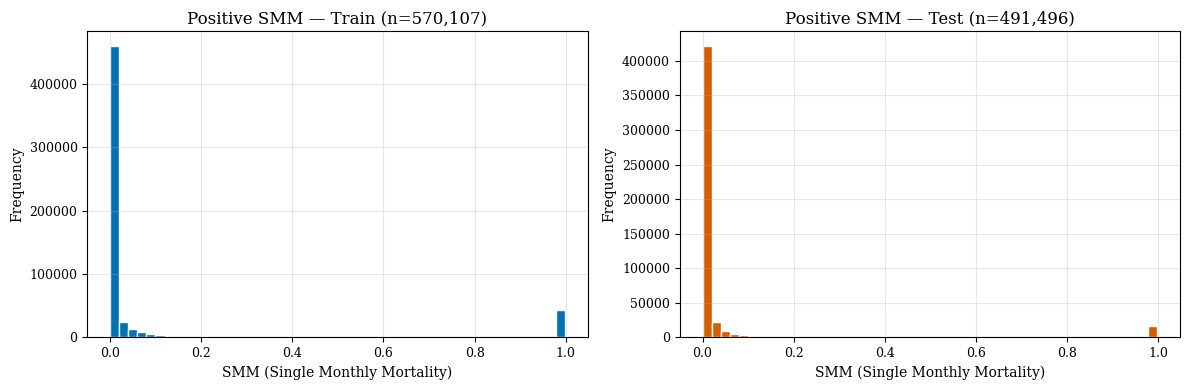

✅ Saved: figures/eda_smm_distribution.{png,pdf}


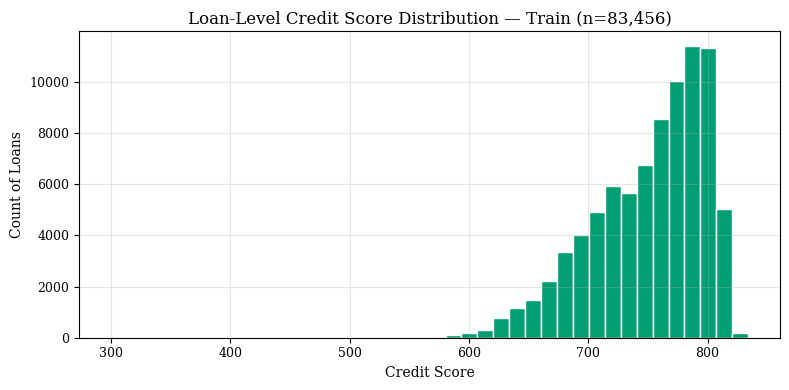

✅ Saved: figures/eda_credit_score_distribution.{png,pdf}


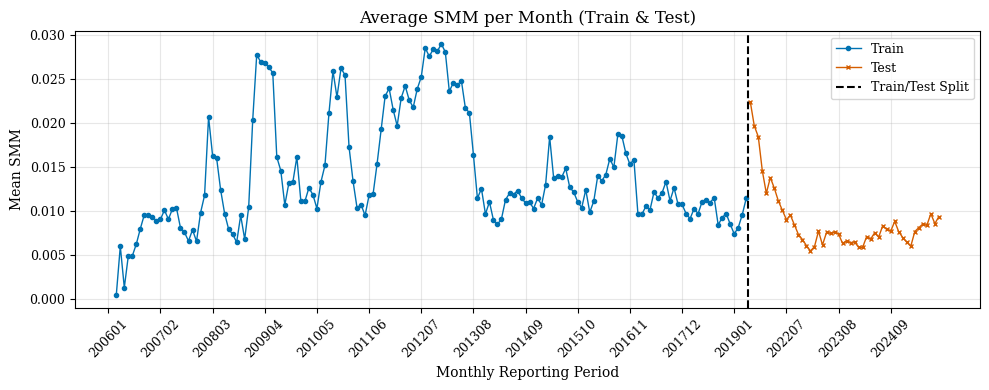

✅ Saved: figures/eda_monthly_smm.{png,pdf}

  EDA COMPLETE


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Thesis-grade matplotlib defaults (consistent with section 4)
EDA_RCPARAMS = {
    "figure.figsize": (8, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "serif",
}


def _save_fig(fig, name: str, figures_dir: str = "figures") -> None:
    """Save a figure to PNG + PDF under figures_dir."""
    fig_path = Path(figures_dir)
    fig_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_path / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(fig_path / f"{name}.pdf", bbox_inches="tight")


def _check_target_leakage(
    train_df: pd.DataFrame,
    feature_cols: list,
    target_col: str = "smm",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Flag features that are suspiciously correlated with the target on train.

    Returns a DataFrame sorted by |Pearson rho| descending. Anything above
    `threshold` is flagged as a leakage candidate. `smm_t1` and similar lagged
    targets will appear here — that is expected and legitimate iff the model
    is genuinely forecasting (predicting smm[t] given smm[t-1]). Investigate
    any feature that is NOT a documented lag but still correlates strongly.
    """
    rows = []
    if target_col not in train_df.columns:
        return pd.DataFrame()

    y = pd.to_numeric(train_df[target_col], errors="coerce")
    for c in feature_cols:
        if c not in train_df.columns or c == target_col:
            continue
        x = pd.to_numeric(train_df[c], errors="coerce")
        valid = x.notna() & y.notna()
        if valid.sum() < 100 or x[valid].std() == 0:
            continue
        rho = float(np.corrcoef(x[valid], y[valid])[0, 1])
        rows.append({"feature": c, "rho": rho, "abs_rho": abs(rho)})

    out = pd.DataFrame(rows).sort_values("abs_rho", ascending=False).reset_index(drop=True)
    out["leakage_flag"] = out["abs_rho"] > threshold
    return out


def run_eda(train_df, test_df, figures_dir: str = "figures"):
    print("=" * 70)
    print("  EXPLORATORY DATA ANALYSIS (EDA)")
    print("=" * 70)

    _prev = {k: plt.rcParams.get(k) for k in EDA_RCPARAMS}
    plt.rcParams.update(EDA_RCPARAMS)

    # ------------------------------------------------------------------
    # 1. Dataset shape
    # ------------------------------------------------------------------
    print(f"Train Set Shape: {train_df.shape[0]:,} rows | {train_df.shape[1]} columns")
    print(f"Test Set Shape:  {test_df.shape[0]:,} rows | {test_df.shape[1]} columns")

    # ------------------------------------------------------------------
    # 2. Prepayment statistics
    # ------------------------------------------------------------------
    if 'is_full_prepay' in train_df.columns:
        prepay_counts = train_df['is_full_prepay'].value_counts()
        prepay_pct = train_df['is_full_prepay'].mean() * 100
        print(f"\nFull Prepayments (Train):")
        print(f"  0 (No):  {prepay_counts.get(0, 0):,}")
        print(f"  1 (Yes): {prepay_counts.get(1, 0):,} ({prepay_pct:.2f}%)")

    if 'smm' in train_df.columns:
        smm_pos = (train_df['smm'] > 0).sum()
        smm_pos_pct = (smm_pos / len(train_df)) * 100
        print(f"\nPositive SMM (Partial/Full Prepayments):")
        print(f"  Count: {smm_pos:,} ({smm_pos_pct:.2f}%)")

    # ------------------------------------------------------------------
    # 3. Key-variable summary table
    # ------------------------------------------------------------------
    key_cols = ['current_actual_upb', 'credit_score', 'ltv', 'note_rate',
                'incentive', 'burnout', 'loan_age', 'smm']
    avail_cols = [c for c in key_cols if c in train_df.columns]
    if avail_cols:
        print("\nKey Variables Summary:")
        summary_df = train_df[avail_cols].describe().round(3)
        try:
            display(summary_df)  # noqa: F821  (display defined in IPython)
        except NameError:
            print(summary_df)
        summary_df.to_csv(Path(figures_dir) / "eda_key_variables_summary.csv")

    # ------------------------------------------------------------------
    # 4. Target leakage sanity check
    # ------------------------------------------------------------------
    print("\n--- Target Leakage Check (|rho| > 0.5 flagged) ---")
    leak_cols = [c for c in COMMON_FEATURE_COLS if c in train_df.columns]
    leak_df = _check_target_leakage(train_df, leak_cols, target_col="smm", threshold=0.5)
    if not leak_df.empty:
        try:
            display(leak_df.head(20))
        except NameError:
            print(leak_df.head(20).to_string(index=False))
        leak_df.to_csv(Path(figures_dir) / "eda_leakage_check.csv", index=False)
        flagged = leak_df[leak_df["leakage_flag"]]["feature"].tolist()
        if flagged:
            print(f"\n⚠ Flagged for leakage review: {flagged}")
            print("   Note: smm_t1 / smm_t3 / smm_t6 are LAGGED targets and are expected")
            print("   to correlate with smm. Investigate any flagged feature that is NOT")
            print("   a documented lag.")

    # ------------------------------------------------------------------
    # 5. Figure 1 — Positive SMM distribution (train + test)
    # ------------------------------------------------------------------
    if 'smm' in train_df.columns and 'smm' in test_df.columns:
        fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(12, 4))

        smm_pos_train = train_df[train_df['smm'] > 0]['smm']
        ax1a.hist(smm_pos_train, bins=50, color='#0072B2', edgecolor='white')
        ax1a.set_title(f'Positive SMM — Train (n={len(smm_pos_train):,})')
        ax1a.set_xlabel('SMM (Single Monthly Mortality)')
        ax1a.set_ylabel('Frequency')
        ax1a.grid(True, alpha=0.3)

        smm_pos_test = test_df[test_df['smm'] > 0]['smm']
        ax1b.hist(smm_pos_test, bins=50, color='#D55E00', edgecolor='white')
        ax1b.set_title(f'Positive SMM — Test (n={len(smm_pos_test):,})')
        ax1b.set_xlabel('SMM (Single Monthly Mortality)')
        ax1b.set_ylabel('Frequency')
        ax1b.grid(True, alpha=0.3)

        fig1.tight_layout()
        _save_fig(fig1, "eda_smm_distribution", figures_dir)
        plt.show()
        plt.close(fig1)
        print(f"✅ Saved: {figures_dir}/eda_smm_distribution.{{png,pdf}}")

    # ------------------------------------------------------------------
    # 6. Figure 2 — Loan-level credit-score distribution
    # ------------------------------------------------------------------
    if 'credit_score' in train_df.columns and 'loan_seq_num' in train_df.columns:
        fig2, ax2 = plt.subplots(figsize=(8, 4))
        loan_cs = train_df.groupby('loan_seq_num')['credit_score'].first()
        ax2.hist(loan_cs.dropna(), bins=40, color='#009E73', edgecolor='white')
        ax2.set_title(f'Loan-Level Credit Score Distribution — Train (n={len(loan_cs):,})')
        ax2.set_xlabel('Credit Score')
        ax2.set_ylabel('Count of Loans')
        ax2.grid(True, alpha=0.3)
        fig2.tight_layout()
        _save_fig(fig2, "eda_credit_score_distribution", figures_dir)
        plt.show()
        plt.close(fig2)
        print(f"✅ Saved: {figures_dir}/eda_credit_score_distribution.{{png,pdf}}")

    # ------------------------------------------------------------------
    # 7. Figure 3 — Average SMM per month (train + test, with split line)
    # ------------------------------------------------------------------
    if 'smm' in train_df.columns and 'monthly_reporting_period' in train_df.columns:
        fig3, ax3 = plt.subplots(figsize=(10, 4))

        all_monthly = pd.concat([
            train_df.assign(dataset='Train'),
            test_df.assign(dataset='Test'),
        ]).groupby(['monthly_reporting_period', 'dataset'])['smm'].mean().unstack()

        all_monthly = all_monthly.sort_index()
        x_vals = all_monthly.index.astype(str)

        if 'Train' in all_monthly.columns:
            ax3.plot(x_vals, all_monthly['Train'].values, color='#0072B2',
                     marker='o', markersize=3, linestyle='-', linewidth=1, label='Train')
        if 'Test' in all_monthly.columns:
            ax3.plot(x_vals, all_monthly['Test'].values, color='#D55E00',
                     marker='x', markersize=3, linestyle='-', linewidth=1, label='Test')

            # Add Train/Test split line
            if all_monthly['Test'].notna().sum() > 0:
                first_test_idx = int(np.where(all_monthly['Test'].notna())[0][0])
                ax3.axvline(x=first_test_idx - 0.5, color='black',
                            linestyle='--', linewidth=1.5, label='Train/Test Split')

        ax3.set_title('Average SMM per Month (Train & Test)')
        ax3.set_xlabel('Monthly Reporting Period')
        ax3.set_ylabel('Mean SMM')

        step = max(1, len(x_vals) // 15)
        ax3.set_xticks(np.arange(0, len(x_vals), step))
        ax3.set_xticklabels(x_vals[::step], rotation=45)
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        fig3.tight_layout()
        _save_fig(fig3, "eda_monthly_smm", figures_dir)
        plt.show()
        plt.close(fig3)
        print(f"✅ Saved: {figures_dir}/eda_monthly_smm.{{png,pdf}}")

    # Restore previous rcParams
    for k, v in _prev.items():
        if v is not None:
            plt.rcParams[k] = v

    print("\n" + "=" * 70)
    print("  EDA COMPLETE")
    print("=" * 70)


run_eda(train_df, test_df, figures_dir=FIGURES_DIR)

# 3 - Model training

## 3.1 Cox Proportional Hazards Baseline

Fits a Cox PH model using `lifelines` with 19 features.
The proportional hazards assumption is expected to be violated for prepayment
data (time-varying covariates like incentive and burnout); Cox PH serves as
a baseline only.

In [11]:
# ==========================================================================
# SECTION 3.1: COX PROPORTIONAL HAZARDS STRUCTURAL ESTIMATION
# ==========================================================================

# ─────────────────────────────────────────────────────────
# Cox PH uses STATIC origination features only (see _collapse_to_loan_level).
# A one-row-per-loan survival model cannot include time-varying covariates
# without leaking post-origination information, so the lag-free COX feature set
# is restricted here to origination-time constants.
# ─────────────────────────────────────────────────────────
COXPH_FEATURE_COLS = [
    'credit_score', 'ltv', 'dti', 'note_rate',
    'orig_loan_term', 'num_borrowers', 'log_orig_upb',
]


def _collapse_to_loan_level(
    df: pd.DataFrame,
    feature_cols: list,
    duration_col: str = "loan_age",
    event_col: str = "full_prepayment",
) -> tuple[pd.DataFrame, list]:
    """Collapse the monthly panel to ONE ROW PER LOAN for Cox PH survival analysis.

    Cox PH treats every row as an independent subject, so feeding the monthly
    panel (many rows per loan, all sharing duration=loan_age) is invalid. We
    collapse each loan to a single survival record:

      duration : max loan_age observed -> months from origination to
                 termination / right-censoring
      event    : 1 if the loan EVER fully prepaid (zero_balance_code == '01'),
                 else 0 (right-censored: still active, defaulted, or matured)
      covariates : static origination features (constant within a loan)

    Only static origination features are used; a one-row Cox cannot include
    time-varying covariates without leaking the future. This is the structural
    survival baseline that the dynamic RF / TFT models are compared against.
    """
    feature_cols = [
        c for c in feature_cols
        if c in df.columns and not df[c].isna().all()
    ]
    g = df.groupby("loan_seq_num", sort=False)
    loan = g[feature_cols].first()
    loan[duration_col] = g[duration_col].max()
    loan[event_col] = g[event_col].max().astype(int)
    loan = loan.reset_index(drop=True)
    # Cox requires strictly positive durations
    loan = loan[loan[duration_col] > 0].copy()
    return loan, feature_cols

def fit_coxph(
    df: pd.DataFrame,
    feature_cols: list = None,
    duration_col: str = "loan_age",
    event_col: str = "full_prepayment",
    penalizer: float = 0.01,
) -> tuple[CoxPHFitter, pd.DataFrame]:
    """Fits L1-regularized Cox Proportional Hazards survival model.

    Includes adaptive grid scaling for penalization when extreme collinearity is present.
    """
    if feature_cols is None:
        feature_cols = COXPH_FEATURE_COLS.copy()

    # Collapse the monthly panel to one survival record per loan.
    model_df, available = _collapse_to_loan_level(
        df, feature_cols, duration_col=duration_col, event_col=event_col
    )

    # Force strict numeric types; drop any loan with a missing covariate.
    for col in available:
        if model_df[col].dtype == "object":
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df = model_df.dropna(subset=available + [duration_col, event_col]).copy()
    if len(model_df) == 0:
        raise ValueError("No loans left after collapsing to survival records.")

    print(
        f"   Cox survival frame: {len(model_df):,} loans "
        f"({int(model_df[event_col].sum()):,} prepaid / "
        f"{len(model_df) - int(model_df[event_col].sum()):,} censored), "
        f"{len(available)} static covariates"
    )

    cph = None
    # Progressively relax mathematical constraints if Hessian matrix optimization errors occur
    optimization_path = [
        (penalizer, 0.1),
        (penalizer * 5, 0.3),
        (penalizer * 20, 0.5),
    ]

    for attempt, (pen, l1) in enumerate(optimization_path):
        try:
            cph = CoxPHFitter(penalizer=pen, l1_ratio=l1)
            cph.fit(model_df, duration_col=duration_col, event_col=event_col)
            print(
                f"✅ Cox PH optimization converged successfully (Attempt {attempt+1}: Penalizer={pen}, L1={l1})"
            )
            break
        except Exception as e:
            if attempt == len(optimization_path) - 1:
                print(
                    f"❌ Structural convergence failed across all baseline variants. Instantiating uninformative intercept-only fallback model. Error: {e}"
                )
                cph = CoxPHFitter(penalizer=penalizer)
                null_df = model_df[[duration_col, event_col]].copy()
                null_df["_intercept_stabilizer"] = 1.0
                cph.fit(
                    null_df,
                    duration_col=duration_col,
                    event_col=event_col,
                )
            else:
                print(
                    f"⚠️ Convergence warning on optimization layer {attempt+1}. Adjusting regularizer constraints..."
                )

    return cph, model_df

def _sanitize_features(df, feature_cols):
    """Ensure all feature columns are numeric and non-null.

    Fills NaN with 0, drops columns that are entirely NaN, and converts
    object-type columns to numeric. Returns (clean_df, used_features).
    """
    used = []
    for col in feature_cols:
        if col not in df.columns:
            continue
        if df[col].isna().all():
            continue  # skip entirely-NaN columns (e.g. channel cols if not in raw data)
        used.append(col)

    df_clean = df[used].copy()
    for col in used:
        if df_clean[col].dtype == object:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean[col] = df_clean[col].fillna(0)

    return df_clean, used


def evaluate_coxph(cph, test_df, duration_col="loan_age", event_col="full_prepayment"):
    """Evaluate the Cox PH model on the held-out loans (concordance index).

    The test panel is collapsed to one survival record per loan with the SAME
    logic used at fit time, then scored with Harrell's concordance index.
    """
    model_feats = list(cph.params_.index)
    try:
        eval_df, _ = _collapse_to_loan_level(
            test_df, model_feats, duration_col=duration_col, event_col=event_col
        )
        eval_df = eval_df[[duration_col, event_col] + model_feats].dropna()
        ci = cph.score(eval_df, scoring_method="concordance_index")
    except Exception as e:
        print(f"   ⚠ Concordance scoring failed ({e}); using training concordance.")
        ci = getattr(cph, "concordance_index_", None)

    return {
        "concordance_index": ci,
        "expected_violation_note": (
            "Cox PH uses static origination covariates on one record per loan; "
            "the proportional-hazards assumption is expected to be violated, which "
            "motivates the dynamic RF / TFT models."
        ),
    }

def section_3_cox(train_df, test_df):
    """Fit and evaluate Cox PH model."""
    cox_path = Path("checkpoints/cox/coxph_model.pkl")
    cph = None

    if cox_path.exists():
        print("📂 Loading existing Cox PH model.")
        try:
            cph = joblib.load(cox_path)
        except Exception as e:
            print(f"⚠️ Error loading model: {e}. Corrupted file will be removed.")
            cox_path.unlink()
            cph = None

    if cph is None:
        print("🔄 Fitting Cox PH baseline...")
        t0 = time.time()
        cph, model_df = fit_coxph(train_df, penalizer=0.1)
        # Ensure the directory exists before saving
        cox_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(cph, str(cox_path))
        elapsed = time.time() - t0
        print(f"   ✅ Fitted in {elapsed:.0f}s, saved to {cox_path}")

    print("\n--- Cox PH Evaluation ---")
    cox_result = evaluate_coxph(cph, test_df)
    ci = cox_result.get("concordance_index")
    if ci is not None:
        print(f"   Concordance Index: {ci:.4f}")
    print(f"   Note: {cox_result.get('expected_violation_note', '')}")
    return cph, cox_result


# ---------------------------------------------------

cph, cox_result = section_3_cox(train_df, test_df)
cox_ci = cox_result.get("concordance_index")

# ---------------------------------------------------

# Free memory before RF training
try:
    del cox_result
except NameError:
    pass
gc.collect()

# Sync immediately to avoid losing models if later training crashes
if 'DRIVE_AVAILABLE' in dir() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
    print("\n📤 Syncing Cox PH model to Google Drive...")
    try:
        drive_base = os.path.dirname(DRIVE_DATA_DIR)
        drive_ckpt_path = os.path.join(drive_base, 'checkpoints')
        os.makedirs(drive_ckpt_path, exist_ok=True)
        os.system(f'cp -r checkpoints/* "{drive_ckpt_path}/" 2>/dev/null || true')
        print("   ✅ Drive sync complete.")
    except Exception as e:
        print(f"   ⚠️ Could not sync to drive: {e}")


📂 Loading existing Cox PH model.

--- Cox PH Evaluation ---
   Concordance Index: 0.5178
   Note: Cox PH uses static origination covariates on one record per loan; the proportional-hazards assumption is expected to be violated, which motivates the dynamic RF / TFT models.

📤 Syncing Cox PH model to Google Drive...
   ✅ Drive sync complete.


## 3.2 Random Forest Models
Trains **separate** Random Forest regressors per horizon (t+1, t+6, t+12)
plus a binary classifier for full prepayment events.


In [12]:
# ==========================================================================
# SECTION 3.2: RANDOM FOREST MODELS (multi-horizon regression + classification)
# ==========================================================================

def _create_horizon_target(df: pd.DataFrame, horizon: int, target_col: str = 'smm') -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(['loan_seq_num', 'monthly_reporting_period']).reset_index(drop=True)
    target_name = f'{target_col}_h{horizon}'
    df[target_name] = df.groupby('loan_seq_num')[target_col].shift(-horizon)
    return df


def _prep_rf_matrix(df: pd.DataFrame, feature_cols: list, target_col: str = None):
    """Build a clean feature matrix (and optional target) for RF training/eval."""
    cols = list(feature_cols) + ([target_col] if target_col else [])
    cols = [c for c in cols if c in df.columns]
    out = df[cols].copy()
    out = out.loc[:, ~out.columns.duplicated(keep='first')]

    for col in feature_cols:
        if col not in out.columns:
            continue
        if out[col].dtype == object:
            out[col] = pd.to_numeric(out[col], errors='coerce')
        out[col] = out[col].fillna(0)

    if target_col is not None:
        out = out.dropna(subset=[target_col]).copy()
    return out


def fit_rf_regressors(
    train_df: pd.DataFrame,
    feature_cols: list = None,
    horizons: list = None,
    target_col: str = 'smm',
    n_estimators: int = 100,
    max_depth: int = 12,
    min_samples_leaf: int = 50,
    n_jobs: int = -1,
    random_state: int = 42,
    checkpoint_dir: str = "models",
) -> dict:
    """Fit one RF regressor per horizon. Resumes from per-horizon checkpoints."""
    if feature_cols is None:
        feature_cols = [c for c in RF_FEATURE_COLS if c in train_df.columns]
    feature_cols = [c for c in feature_cols if not train_df[c].isna().all()]

    if horizons is None:
        horizons = HORIZONS.copy()

    os.makedirs(checkpoint_dir, exist_ok=True)
    horizon_ckpt_pattern = os.path.join(checkpoint_dir, "rf_h{}.joblib")

    models = {}
    for h in horizons:
        horizon_ckpt = horizon_ckpt_pattern.format(h)
        if os.path.exists(horizon_ckpt):
            print(f"📂 Found checkpoint for horizon {h}, loading...")
            models[h] = joblib.load(horizon_ckpt)
            continue

        _mem_usage(f"h{h}-start")
        df_h = _create_horizon_target(train_df, h, target_col)
        target_name = f'{target_col}_h{h}'
        model_df = _prep_rf_matrix(df_h, feature_cols, target_col=target_name)

        if len(model_df) == 0:
            print(f"⚠ No valid rows for horizon {h}, skipping")
            models[h] = None
            continue

        X = model_df[feature_cols]
        y = model_df[target_name]
        del df_h
        gc.collect()

        _mem_usage(f"h{h}-before-fit")
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            n_jobs=n_jobs,
            random_state=random_state,
        )
        rf.fit(X, y)
        models[h] = rf
        print(f"   Horizon {h}: trained on {len(model_df):,} rows, {len(feature_cols)} features")

        del model_df, X, y
        gc.collect()

        joblib.dump(rf, horizon_ckpt)
        print(f"   ✅ Saved horizon {h} checkpoint: {horizon_ckpt}")
        _mem_usage(f"h{h}-done")

    return models


def evaluate_rf_regressors(
    models: dict,
    eval_df: pd.DataFrame,
    feature_cols: list = None,
    target_col: str = 'smm',
    label: str = "test",
) -> pd.DataFrame:
    """Evaluate RF regressors on a dataframe. `label` is included in the output
    ('train' or 'test') so we can stack train and test results for generalization
    comparison (Rubric 4D)."""
    if feature_cols is None:
        feature_cols = [c for c in RF_FEATURE_COLS if c in eval_df.columns]
    feature_cols = [c for c in feature_cols if not eval_df[c].isna().all()]

    results = []
    for h, model in models.items():
        if model is None:
            continue
        df_h = _create_horizon_target(eval_df, h, target_col)
        target_name = f'{target_col}_h{h}'
        sub = _prep_rf_matrix(df_h, feature_cols, target_col=target_name)

        if len(sub) == 0:
            print(f"⚠ Horizon {h} ({label}): no valid rows, skipping")
            continue

        # Align features to the model's training schema if available
        if hasattr(model, 'feature_names_in_'):
            model_feats = list(model.feature_names_in_)
            for c in model_feats:
                if c not in sub.columns:
                    sub[c] = 0
            X_eval = sub[model_feats]
        else:
            X_eval = sub[feature_cols]

        y_eval = sub[target_name]
        y_pred = model.predict(X_eval)

        rmse_all = float(np.sqrt(mean_squared_error(y_eval, y_pred)))
        mae_all = float(mean_absolute_error(y_eval, y_pred))
        r2_all = float(r2_score(y_eval, y_pred)) if len(y_eval) > 1 else float("nan")

        pos_mask = y_eval > 0
        if pos_mask.sum() > 1:
            rmse_pos = float(np.sqrt(mean_squared_error(y_eval[pos_mask], y_pred[pos_mask])))
            mae_pos = float(mean_absolute_error(y_eval[pos_mask], y_pred[pos_mask]))
            r2_pos = float(r2_score(y_eval[pos_mask], y_pred[pos_mask]))
        else:
            rmse_pos = float("nan")
            mae_pos = float("nan")
            r2_pos = float("nan")

        results.append({
            'split': label,
            'horizon': h,
            'rmse_all': rmse_all,
            'mae_all': mae_all,
            'r2_all': r2_all,
            'rmse_smm_pos': rmse_pos,
            'mae_smm_pos': mae_pos,
            'r2_smm_pos': r2_pos,
            'n_eval': len(sub),
            'n_smm_pos': int(pos_mask.sum()),
        })
        print(f"   Horizon {h} ({label}): RMSE={rmse_all:.6f}, "
              f"R2={r2_all:.4f}, RMSE(SMM>0)={rmse_pos:.6f}, n={len(sub):,}")

    return pd.DataFrame(results)


def fit_rf_classifier(
    train_df: pd.DataFrame,
    feature_cols: list = None,
    target_col: str = 'prepay_within_12m',
    n_estimators: int = 100,
    max_depth: int = 12,
    min_samples_leaf: int = 50,
    n_jobs: int = -1,
    random_state: int = 42,
    class_weight: str = 'balanced',
    checkpoint_dir: str = "models",
) -> RandomForestClassifier:
    """Fit binary RF classifier on full-prepayment events."""
    if feature_cols is None:
        # Issue 2 fix: classifier uses the lag-stripped set; regressor still
        # uses RF_FEATURE_COLS (lags are legitimate for forecasting).
        feature_cols = [c for c in RF_CLASSIFIER_FEATURE_COLS if c in train_df.columns]
    feature_cols = [c for c in feature_cols if not train_df[c].isna().all()]

    ckpt_path = os.path.join(checkpoint_dir, "rf_classifier.joblib")
    _force = globals().get("RF_FORCE_RETRAIN", False)
    if os.path.exists(ckpt_path) and _force:
        print("🗑  RF_FORCE_RETRAIN=True — deleting stale RF classifier checkpoint and refitting.")
        try:
            os.remove(ckpt_path)
        except OSError:
            pass
    elif os.path.exists(ckpt_path):
        cached = joblib.load(ckpt_path)
        # Self-healing guard: a checkpoint trained on a leaky feature set (one that
        # still includes lagged SMM smm_t1/t3/t6) would re-leak the prepay event via
        # clf.feature_names_in_ at eval time -> AUC~1.0. Detect and refit if so.
        _cached_feats = list(getattr(cached, "feature_names_in_", []))
        _leaky = [c for c in _cached_feats if c in _LAGGED_SMM]
        if _leaky:
            print(f"⚠ Cached RF classifier was trained on leaky features {_leaky} — "
                  f"refitting on the lag-free set.")
            try:
                os.remove(ckpt_path)
            except OSError:
                pass
        else:
            print("📂 Found RF classifier checkpoint, loading...")
            return cached

    if target_col not in train_df.columns:
        print(f"\u26A0 '{target_col}' missing from train_df \u2014 computing it on the fly. "
              f"For the exact (boundary-safe) target, delete cached splits and regenerate.")
        train_df = add_forward_prepay_target(train_df.copy(), horizon=12, col=target_col)
    model_df = _prep_rf_matrix(train_df, feature_cols, target_col=target_col)
    if len(model_df) == 0:
        raise ValueError("No valid rows for classifier training")

    X = model_df[feature_cols]
    y = model_df[target_col].astype(int)

    _mem_usage("clf-before-fit")
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        n_jobs=n_jobs,
        random_state=random_state,
        class_weight=class_weight,
    )
    clf.fit(X, y)

    n_pos = int(y.sum())
    n_rows = len(model_df)
    del model_df, X, y
    gc.collect()

    os.makedirs(checkpoint_dir, exist_ok=True)
    joblib.dump(clf, ckpt_path)
    print(f"   RF classifier fitted on {n_rows:,} rows, {n_pos:,} positive class")
    print(f"   ✅ Saved classifier checkpoint: {ckpt_path}")
    _mem_usage("clf-done")

    return clf


def evaluate_rf_classifier(
    clf: RandomForestClassifier,
    eval_df: pd.DataFrame,
    feature_cols: list = None,
    target_col: str = 'prepay_within_12m',
    label: str = "test",
    output_dir: str = "outputs/evaluation",
) -> dict:
    """Evaluate classifier; also save y_true / y_prob for downstream PR/AUC
    curve plotting in Section 4."""
    if feature_cols is None:
        # MUST match fit_rf_classifier (lag-free set). Using RF_FEATURE_COLS here
        # re-introduces smm_t1, which mechanically identifies the prepayer ->
        # leakage / AUC~1.0. Score on the same features the classifier was fit on.
        feature_cols = [c for c in RF_CLASSIFIER_FEATURE_COLS if c in eval_df.columns]
    feature_cols = [c for c in feature_cols if not eval_df[c].isna().all()]

    if target_col not in eval_df.columns:
        eval_df = add_forward_prepay_target(eval_df.copy(), horizon=12, col=target_col)
    sub = _prep_rf_matrix(eval_df, feature_cols, target_col=target_col)
    if len(sub) == 0:
        return {'auc': None, 'accuracy': None, 'n_eval': 0, 'n_positive': 0,
                'split': label}

    if hasattr(clf, 'feature_names_in_'):
        model_feats = list(clf.feature_names_in_)
        for c in model_feats:
            if c not in sub.columns:
                sub[c] = 0
        X_eval = sub[model_feats]
    else:
        X_eval = sub[feature_cols]

    y_true = sub[target_col].astype(int).values
    y_prob = clf.predict_proba(X_eval)[:, 1]
    y_pred = clf.predict(X_eval)

    auc = float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else float("nan")
    acc = float(accuracy_score(y_true, y_pred))

    # Persist for Section 4 (PR curves, bootstrap CIs)
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        Path(output_dir) / f"rf_classifier_scores_{label}.npz",
        y_true=y_true, y_prob=y_prob,
    )

    print(f"   Classifier ({label}): AUC={auc:.4f}, Accuracy={acc:.4f}, "
          f"n={len(sub):,}, pos={int(y_true.sum()):,}")

    return {
        'split': label,
        'auc': auc,
        'accuracy': acc,
        'n_eval': len(sub),
        'n_positive': int(y_true.sum()),
    }


def section_3_random_forest(train_df, test_df):
    """Fit and evaluate Random Forest models (multi-horizon regression + classifier).

    Returns
    -------
    rf_models : dict
        {horizon: fitted RandomForestRegressor}
    rf_classifier : RandomForestClassifier
    rf_results : pd.DataFrame
        Stacked train + test per-horizon regression metrics.
    rf_clf_results : dict
        {'train': {...}, 'test': {...}} classifier metrics.
    """
    rf_ckpt_dir = "checkpoints/rf"
    Path(rf_ckpt_dir).mkdir(parents=True, exist_ok=True)

    # ----------------------------------------------------------------------
    # Regressors — per-horizon, with auto-resume of missing horizons
    # ----------------------------------------------------------------------
    print("🔄 Training/loading RF regressors for horizons:", HORIZONS)
    t0 = time.time()
    rf_models = fit_rf_regressors(
        train_df,
        horizons=HORIZONS,
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        n_jobs=-1,
        checkpoint_dir=rf_ckpt_dir,
    )

    # Sanity check: make sure every requested horizon actually has a model
    missing = [h for h in HORIZONS if rf_models.get(h) is None]
    if missing:
        print(f"⚠ Missing models for horizons {missing}. "
              f"Cross-model table will be incomplete.")
    else:
        print(f"   ✅ All {len(HORIZONS)} horizons have trained models "
              f"(elapsed: {time.time() - t0:.0f}s)")

    # ----------------------------------------------------------------------
    # Classifier
    # ----------------------------------------------------------------------
    if 'is_full_prepay' not in train_df.columns:
        print("⚠ 'is_full_prepay' not in train_df — skipping RF classifier.")
        rf_classifier = None
    else:
        print("\n🔄 Training/loading RF classifier (full prepayment)...")
        t0 = time.time()
        rf_classifier = fit_rf_classifier(
            train_df,
            n_jobs=-1,
            checkpoint_dir=rf_ckpt_dir,
        )
        print(f"   ✅ Classifier ready (elapsed: {time.time() - t0:.0f}s)")

    # ----------------------------------------------------------------------
    # Evaluation — on BOTH train and test, for generalization comparison
    # ----------------------------------------------------------------------
    print("\n--- RF Regressor Evaluation (train) ---")
    rf_train_results = evaluate_rf_regressors(rf_models, train_df, label="train")

    print("\n--- RF Regressor Evaluation (test) ---")
    rf_test_results = evaluate_rf_regressors(rf_models, test_df, label="test")

    rf_results = pd.concat([rf_train_results, rf_test_results], ignore_index=True)

    rf_clf_results = {}
    if rf_classifier is not None:
        print("\n--- RF Classifier Evaluation (train) ---")
        rf_clf_results['train'] = evaluate_rf_classifier(
            rf_classifier, train_df, label="train", output_dir=OUTPUT_DIR,
        )
        print("\n--- RF Classifier Evaluation (test) ---")
        rf_clf_results['test'] = evaluate_rf_classifier(
            rf_classifier, test_df, label="test", output_dir=OUTPUT_DIR,
        )

    # ----------------------------------------------------------------------
    # Persist results so Section 4 doesn't have to re-evaluate
    # ----------------------------------------------------------------------
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    rf_results.to_csv(Path(OUTPUT_DIR) / "rf_results.csv", index=False)
    print(f"\n✅ RF results saved: {OUTPUT_DIR}/rf_results.csv")

    if rf_clf_results:
        pd.DataFrame(rf_clf_results).T.to_csv(
            Path(OUTPUT_DIR) / "rf_classifier_results.csv"
        )
        print(f"✅ RF classifier results saved: {OUTPUT_DIR}/rf_classifier_results.csv")

    return rf_models, rf_classifier, rf_results, rf_clf_results


# ---------------------------------------------------

rf_models, rf_classifier, rf_results, rf_clf_results = \
    section_3_random_forest(train_df, test_df)

# ---------------------------------------------------

# Sync immediately to avoid losing models if TFT training crashes later
if 'DRIVE_AVAILABLE' in dir() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
    print("\n📤 Syncing RF models + results to Google Drive...")
    try:
        sync_artifacts_to_drive(
            drive_base=os.path.dirname(DRIVE_DATA_DIR),
            artifact_dirs=['checkpoints', 'outputs'],
        )
        print("   ✅ Drive sync complete.")
    except Exception as e:
        print(f"   ⚠️ Could not sync to drive: {e}")

🔄 Training/loading RF regressors for horizons: [1, 6, 12]
📂 Found checkpoint for horizon 1, loading...
📂 Found checkpoint for horizon 6, loading...
📂 Found checkpoint for horizon 12, loading...
   ✅ All 3 horizons have trained models (elapsed: 8s)

🔄 Training/loading RF classifier (full prepayment)...
📂 Found RF classifier checkpoint, loading...
   ✅ Classifier ready (elapsed: 0s)

--- RF Regressor Evaluation (train) ---
   Horizon 1 (train): RMSE=0.103384, R2=0.1343, RMSE(SMM>0)=0.254668, n=3,545,774
   Horizon 6 (train): RMSE=0.107046, R2=0.1265, RMSE(SMM>0)=0.274823, n=3,211,729
   Horizon 12 (train): RMSE=0.110275, R2=0.1246, RMSE(SMM>0)=0.283585, n=2,756,600

--- RF Regressor Evaluation (test) ---
   Horizon 1 (test): RMSE=0.078802, R2=0.0442, RMSE(SMM>0)=0.181545, n=2,744,962
   Horizon 6 (test): RMSE=0.075542, R2=0.0134, RMSE(SMM>0)=0.177147, n=2,392,766
   Horizon 12 (test): RMSE=0.073574, R2=-0.0150, RMSE(SMM>0)=0.171219, n=1,974,928

--- RF Classifier Evaluation (train) ---
 

## 3.3 Temporal Fusion Transformer (GPU)

Builds a TimeSeriesDataSet from the panel, trains a TFT using PyTorch Lightning,
extracts predictions, VSN weights, and attention maps.

In [13]:
# ==========================================================================
# SECTION 3.3: TFT HELPERS (VSN, dataset building, prediction, metrics)
# ==========================================================================

# --------------------------------------------------------------------------
# VSN extraction — using the supported `interpret_output` API
# --------------------------------------------------------------------------

def extract_vsn_weights(
    model: "TemporalFusionTransformer",
    dataloader,
    feature_groups: Dict[str, List[str]] = None,
    reduction: str = "mean",
) -> Dict[str, Dict[str, np.ndarray]]:
    """Extract Variable Selection Network weights via pytorch-forecasting's
    interpret_output.

    Feature names are taken DIRECTLY from the fitted model
    (model.static_variables / encoder_variables / decoder_variables) so they
    align 1:1 with the weight vectors interpret_output returns, and each weight
    vector is normalised to sum to 1 (interpretable as a proportion of the VSN
    selection weight). This avoids the name/weight misalignment and the
    un-normalised magnitudes produced by hand-building the name lists.

    Returns {"static"/"encoder"/"decoder": {"features": [...], "weights": np.ndarray}}.
    """
    model.eval()

    # Names straight from the model → guaranteed to match interpret_output lengths.
    name_map = {
        "static":  list(getattr(model, "static_variables", []) or []),
        "encoder": list(getattr(model, "encoder_variables", []) or []),
        "decoder": list(getattr(model, "decoder_variables", []) or []),
    }
    result = {cat: {"features": list(names), "weights": np.array([])}
              for cat, names in name_map.items()}

    try:
        raw_output = model.predict(dataloader, mode="raw", return_x=True)
        _raw = raw_output.output if hasattr(raw_output, "output") else (
            raw_output[0] if isinstance(raw_output, (list, tuple)) else raw_output)
        interpretation = model.interpret_output(_raw, reduction=reduction)
    except Exception as e:
        print(f"⚠ VSN extraction failed during interpret_output: {e}")
        return result

    key_map = {
        "static":  "static_variables",
        "encoder": "encoder_variables",
        "decoder": "decoder_variables",
    }
    for cat, key in key_map.items():
        if key not in interpretation:
            continue
        w = interpretation[key]
        try:
            w_np = w.detach().cpu().numpy()
        except AttributeError:
            w_np = np.asarray(w)
        w_np = np.asarray(w_np, dtype=float)
        while w_np.ndim > 1:                 # collapse (time, n_features) -> (n_features,)
            w_np = w_np.mean(axis=0)

        s = float(w_np.sum())
        if np.isfinite(s) and s > 0:         # normalise to proportions summing to 1
            w_np = w_np / s

        names = name_map[cat]
        if names and len(names) != len(w_np):   # length guard (should not trigger now)
            n = min(len(names), len(w_np))
            result[cat]["features"] = list(names[:n])
            w_np = w_np[:n]
        result[cat]["weights"] = w_np

    return result


def plot_vsn_by_category(
    vsn_weights: Dict[str, Dict[str, np.ndarray]],
    output_dir: str = "outputs/vsn_charts",
) -> None:
    """Plot one horizontal bar chart per VSN category (static / encoder / decoder)."""
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    color_map = {"static": "#0072B2", "encoder": "#009E73", "decoder": "#D55E00"}

    for cat in ["static", "encoder", "decoder"]:
        entry = vsn_weights.get(cat, {})
        features = entry.get("features", [])
        weights = entry.get("weights", np.array([]))
        if len(features) == 0 or weights.size == 0:
            continue

        n = min(len(features), len(weights))
        order = np.argsort(weights[:n])  # ascending → largest at top in barh
        fig_h = max(4, n * 0.35)
        fig, ax = plt.subplots(figsize=(10, fig_h))
        ax.barh(range(n), weights[order], color=color_map.get(cat, "gray"))
        ax.set_yticks(range(n))
        ax.set_yticklabels([features[i] for i in order])
        ax.set_xlabel("VSN Importance")
        ax.set_title(f"Variable Selection Network — {cat.capitalize()}")
        fig.tight_layout()
        fig.savefig(f"{output_dir}/{cat}_vsn.png", dpi=300, bbox_inches="tight")
        fig.savefig(f"{output_dir}/{cat}_vsn.pdf", bbox_inches="tight")
        plt.close(fig)


def get_top_features(
    vsn_weights: Dict[str, Dict[str, np.ndarray]],
    n: int = 10,
) -> List[Tuple[str, str, float]]:
    """Return (category, feature_name, weight) for the top-N features overall."""
    all_pairs = []
    for cat, entry in vsn_weights.items():
        features = entry.get("features", [])
        weights = entry.get("weights", np.array([]))
        if weights.size == 0:
            continue
        for feat, w in zip(features, weights):
            all_pairs.append((cat, feat, float(w)))
    all_pairs.sort(key=lambda x: x[2], reverse=True)
    return all_pairs[:n]


# --------------------------------------------------------------------------
# Model construction + training
# --------------------------------------------------------------------------

def create_tft_model(
    dataset: "TimeSeriesDataSet",
    learning_rate: float = 0.03,
    hidden_size: int = 32,
    output_size: int = 7,
) -> "TemporalFusionTransformer":
    tft = TemporalFusionTransformer.from_dataset(
        dataset,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=1,
        dropout=0.1,
        hidden_continuous_size=8,
        output_size=output_size,
        loss=QuantileLoss(),
        log_interval=2,
        reduce_on_plateau_patience=4,
    )
    print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")
    return tft


def train_tft(
    model: "TemporalFusionTransformer",
    train_dataloader,
    val_dataloader,
    max_epochs: int = 10,
    checkpoint_dir: str = "checkpoints",
) -> "pl.Trainer":
    checkpoint_callback = ModelCheckpoint(
        dirpath=checkpoint_dir,
        monitor="val_loss",
        mode="min",
        save_top_k=1,                          # keep only the best-val_loss checkpoint
        filename="tft-{epoch:02d}-{val_loss:.4f}",
    )
    trainer = pl.Trainer(
        accelerator="auto",
        devices="auto",
        gradient_clip_val=0.1,
        max_epochs=max_epochs,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=3),
            LearningRateMonitor(),
            checkpoint_callback,
        ],
        logger=pl.loggers.TensorBoardLogger("tb_logs", name="tft"),
    )
    trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
    return trainer


# --------------------------------------------------------------------------
# Prediction — returns BOTH the full 12-step prediction and the selected horizons
# --------------------------------------------------------------------------

def predict_horizons(
    model: "TemporalFusionTransformer",
    dataloader,
    horizon_indices: List[int] = [0, 5, 11],
    dataset=None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Run TFT inference and return aligned arrays plus join keys.

    MEMORY-LEAN path: uses mode="prediction" (point/median forecast) plus
    return_index / return_y, NOT mode="raw"+return_x. The raw+x path keeps all 7
    quantiles AND every input tensor for every sample, accumulating ~100 GB of
    host RAM on multi-million-sample sets (the cause of the A100 crash). The lean
    path keeps only the (N, H) median forecast, (N, H) actuals and a compact
    index — ~100x less memory. Falls back to the legacy raw path if the API differs.
    """
    import gc as _gc
    try:
        import torch as _torch
    except Exception:
        _torch = None

    def _np(t):
        try:
            return t.detach().cpu().numpy()
        except AttributeError:
            return np.asarray(t)

    first_t = None
    group_ids = np.array([])
    try:
        out = model.predict(
            dataloader, mode="prediction", return_index=True, return_y=True,
        )
        predictions_full = out.output
        if isinstance(predictions_full, (list, tuple)):
            predictions_full = predictions_full[0]
        predictions_full = _np(predictions_full)

        y = out.y
        actuals_full = y[0] if isinstance(y, (list, tuple)) else y
        actuals_full = _np(actuals_full)

        index_df = out.index
        group_col = dataset.group_ids[0] if dataset is not None else "loan_seq_num"
        if group_col in index_df.columns:
            group_ids = index_df[group_col].values
        time_col = dataset.time_idx if dataset is not None else "loan_age"
        if time_col not in index_df.columns:
            time_col = "time_idx" if "time_idx" in index_df.columns else None
        if time_col is not None:
            first_t = index_df[time_col].values

        del out
        _gc.collect()
        if _torch is not None and _torch.cuda.is_available():
            _torch.cuda.empty_cache()
    except Exception as e:
        print(f"⚠ Lean predict path failed ({e}); falling back to raw+x path.")
        pred = model.predict(dataloader, mode="raw", return_x=True)
        x = pred.x
        predictions_full = _np(pred.output["prediction"][..., 4])  # median of 7 quantiles
        actuals_full = x["decoder_target"]
        if isinstance(actuals_full, (list, tuple)):
            actuals_full = actuals_full[0]
        actuals_full = _np(actuals_full)
        if "decoder_time_idx" in x:
            first_t = _np(x["decoder_time_idx"])[:, 0]
        if dataset is not None:
            try:
                group_ids = dataset.x_to_index(x)[dataset.group_ids[0]].values
            except Exception as e2:
                print(f"⚠ group_ids decode failed: {e2}")
        del pred
        _gc.collect()
        if _torch is not None and _torch.cuda.is_available():
            _torch.cuda.empty_cache()

    if predictions_full.ndim == 1:
        predictions_full = predictions_full[:, None]
    if actuals_full.ndim == 1:
        actuals_full = actuals_full[:, None]

    T_pred = min(predictions_full.shape[1], actuals_full.shape[1])
    predictions_full = predictions_full[:, :T_pred]
    actuals_full = actuals_full[:, :T_pred]

    valid_idx = [h for h in horizon_indices if h < T_pred]
    dropped = [h for h in horizon_indices if h >= T_pred]
    if dropped:
        print(f"⚠ Requested horizons {dropped} exceed prediction_length={T_pred}; "
              f"keeping {valid_idx}")
    predictions_h = predictions_full[:, valid_idx]
    actuals_h     = actuals_full[:, valid_idx]

    # Reconstruct (N, T_pred) decoder time index from the first decoder step.
    if first_t is not None:
        dec_time = np.asarray(first_t)[:, None] + np.arange(T_pred)[None, :]
    else:
        dec_time = np.array([])

    return predictions_h, actuals_h, predictions_full, actuals_full, group_ids, dec_time

# --------------------------------------------------------------------------
# Metrics
# --------------------------------------------------------------------------

def compute_horizon_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    horizon_labels: List[str] = ("t1", "t6", "t12"),
) -> Dict[str, float]:
    """Compute per-horizon RMSE (all rows) and RMSE conditional on SMM>0.

    y_true and y_pred must be the SAME shape (N, H), already aligned to the
    horizons named in horizon_labels. The `smm_mask` is derived internally from
    y_true so this function can't be misused by passing a misaligned mask.
    """
    metrics = {}
    n_horizons = min(y_true.shape[1], y_pred.shape[1], len(horizon_labels))
    for i in range(n_horizons):
        label = horizon_labels[i]
        yt = y_true[:, i]
        yp = y_pred[:, i]
        # Drop non-finite pairs. TFT decoder targets are NaN for some loan-months
        # (e.g. a loan's first observation where SMM is undefined); leaving them in
        # makes RMSE/MAE come out NaN and makes r2_score raise "Input contains NaN".
        finite = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[finite]
        yp = yp[finite]
        if len(yt) == 0:
            for _m in ("rmse", "mae", "r2"):
                metrics[f"{_m}_{label}_all"] = float("nan")
                metrics[f"{_m}_{label}_smm_pos"] = float("nan")
            continue
        rmse_all = float(np.sqrt(np.mean((yt - yp) ** 2)))
        mae_all = float(np.mean(np.abs(yt - yp)))
        r2_all = float(r2_score(yt, yp)) if len(yt) > 1 else float("nan")
        metrics[f"rmse_{label}_all"] = rmse_all
        metrics[f"mae_{label}_all"]  = mae_all
        metrics[f"r2_{label}_all"]   = r2_all

        pos_mask = yt > 0
        if pos_mask.sum() > 1:
            rmse_pos = float(np.sqrt(np.mean((yt[pos_mask] - yp[pos_mask]) ** 2)))
            mae_pos  = float(np.mean(np.abs(yt[pos_mask] - yp[pos_mask])))
            r2_pos   = float(r2_score(yt[pos_mask], yp[pos_mask]))
        else:
            rmse_pos = float("nan")
            mae_pos  = float("nan")
            r2_pos   = float("nan")
        metrics[f"rmse_{label}_smm_pos"] = rmse_pos
        metrics[f"mae_{label}_smm_pos"]  = mae_pos
        metrics[f"r2_{label}_smm_pos"]   = r2_pos

    return metrics


def derive_prepay_probability(predictions_full: np.ndarray) -> np.ndarray:
    """Convert (N, T) per-month SMM predictions into a 1D 'prepayment-within-T'
    probability per loan, via 1 - prod(1 - SMM_t).

    This lets TFT participate in the AUC/PR comparison alongside the RF classifier
    and Cox PH without retraining anything.
    """
    p = np.clip(predictions_full, 0.0, 1.0)
    surv = np.prod(1.0 - p, axis=1)
    return 1.0 - surv


# --------------------------------------------------------------------------
# Feature group / dataset construction
# --------------------------------------------------------------------------

def get_tft_feature_groups() -> dict:
    return {
        'static_categoricals': TFT_STATIC_CATEGORICALS.copy(),
        'static_reals': TFT_STATIC_REALS.copy(),
        'time_varying_known_reals': TFT_TIME_VARYING_KNOWN_REALS.copy(),
        'time_varying_unknown_reals': TFT_TIME_VARYING_UNKNOWN_REALS.copy(),
        'target': TFT_TARGET,
        'group_ids': TFT_GROUP_IDS.copy(),
        'time_idx': TFT_TIME_IDX,
    }


def _prepare_data_for_tft(df: pd.DataFrame, feature_groups: dict = None):
    df = df.copy()

    if feature_groups is None:
        static_cats = TFT_STATIC_CATEGORICALS
        static_reals = TFT_STATIC_REALS
        known_reals = TFT_TIME_VARYING_KNOWN_REALS
        unknown_reals = TFT_TIME_VARYING_UNKNOWN_REALS
        target = TFT_TARGET
        group_ids = TFT_GROUP_IDS
        time_idx = TFT_TIME_IDX
    else:
        static_cats = feature_groups.get('static_categoricals', [])
        static_reals = feature_groups.get('static_reals', [])
        known_reals = feature_groups.get('time_varying_known_reals', [])
        unknown_reals = feature_groups.get('time_varying_unknown_reals', [])
        target = feature_groups.get('target', TFT_TARGET)
        group_ids = feature_groups.get('group_ids', TFT_GROUP_IDS)
        time_idx = feature_groups.get('time_idx', TFT_TIME_IDX)

    required = [time_idx, target] + group_ids
    missing_required = [c for c in required if c not in df.columns]
    if missing_required:
        raise ValueError(f"Missing required columns for TFT dataset: {missing_required}")

    df[time_idx] = pd.to_numeric(df[time_idx], errors='coerce').astype(int)
    for g in group_ids:
        df[g] = df[g].astype(str)

    all_feature_cols = static_cats + static_reals + known_reals + unknown_reals
    available_features = [c for c in all_feature_cols if c in df.columns]
    missing_features = [c for c in all_feature_cols if c not in df.columns]
    if missing_features:
        print(f"Warning: missing feature columns (will be omitted): {missing_features}")

    cols_to_check = required + [c for c in available_features if c not in required]
    static_cols_raw = [c for c in static_cats + static_reals if c in cols_to_check]
    drop_subset = required + static_cols_raw
    df_clean = df[cols_to_check].dropna(subset=drop_subset).copy()
    df_clean = df_clean.fillna(0)
    df_clean = df_clean.infer_objects(copy=False)
    df_clean = df_clean.sort_values(by=group_ids + [time_idx]).reset_index(drop=True)

    print(f"TFT data prep: {len(df):,} rows -> {len(df_clean):,} rows after NA drop")
    print(f"Features used: {len(available_features)} (missing: {len(missing_features)})")

    resolved = {
        'static_cats': static_cats,
        'static_reals': static_reals,
        'known_reals': known_reals,
        'unknown_reals': unknown_reals,
        'target': target,
        'group_ids': group_ids,
        'time_idx': time_idx,
    }
    return df_clean, available_features, resolved


def build_tft_dataset(
    df: pd.DataFrame,
    max_encoder_length: int = 24,
    max_prediction_length: int = 12,
    min_encoder_length: int = 2,
    feature_groups: dict = None,
):
    try:
        from pytorch_forecasting import TimeSeriesDataSet
        from pytorch_forecasting.data.encoders import EncoderNormalizer, NaNLabelEncoder
    except ImportError as e:
        raise ImportError(
            "pytorch-forecasting is required for TFT dataset construction. "
            "Install: pip install pytorch-forecasting"
        ) from e

    df_clean, available_features, resolved_groups = _prepare_data_for_tft(df, feature_groups)
    if len(df_clean) == 0:
        raise ValueError("No valid rows after cleaning — cannot build TimeSeriesDataSet")

    static_cats   = [c for c in resolved_groups['static_cats']   if c in available_features]
    static_reals  = [c for c in resolved_groups['static_reals']  if c in available_features]
    known_reals   = [c for c in resolved_groups['known_reals']   if c in available_features]
    unknown_reals = [c for c in resolved_groups['unknown_reals'] if c in available_features]
    target    = resolved_groups['target']
    group_ids = resolved_groups['group_ids']
    time_idx  = resolved_groups['time_idx']

    categorical_encoders = {c: NaNLabelEncoder(add_nan=True) for c in static_cats}

    dataset = TimeSeriesDataSet(
        df_clean,
        time_idx=time_idx,
        target=target,
        group_ids=group_ids,
        max_encoder_length=max_encoder_length,
        min_encoder_length=min_encoder_length,
        max_prediction_length=max_prediction_length,
        min_prediction_length=1,
        static_categoricals=static_cats,
        static_reals=static_reals,
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=EncoderNormalizer(),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        categorical_encoders=categorical_encoders,
        allow_missing_timesteps=True,
    )

    print(f"TimeSeriesDataSet built: {len(dataset):,} samples")
    print(f"  Groups (loans): {df_clean[group_ids[0]].nunique():,}")
    print(f"  Max encoder length: {max_encoder_length}")
    print(f"  Max prediction length: {max_prediction_length}")
    return dataset


def prepare_tft_data(df: pd.DataFrame, feature_groups: dict = None) -> pd.DataFrame:
    df_clean, _, _ = _prepare_data_for_tft(df, feature_groups)
    return df_clean


def load_checkpoint(
    checkpoint_path: str,
    dataset: "TimeSeriesDataSet" = None,  # kept for backward compat, unused
) -> "TemporalFusionTransformer":
    model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_path, map_location="cpu")
    print(f"Loaded checkpoint from {checkpoint_path}")
    return model


def validate_tft_dataset(dataset) -> dict:
    results = {
        'len_dataset': len(dataset),
        'has_dataloader': False,
        'batch_shapes': {},
        'parameters_extracted': False,
        'errors': [],
    }
    if len(dataset) == 0:
        results['errors'].append("Dataset has 0 samples")
        return results
    try:
        dataloader = dataset.to_dataloader(train=False, batch_size=4, num_workers=2)
        batch = next(iter(dataloader))
        results['has_dataloader'] = True
        x, y = batch
        results['batch_shapes'] = {k: str(v.shape) for k, v in x.items()}
        results['target_shape'] = str(y[0].shape) if isinstance(y, (list, tuple)) else str(y.shape)
    except Exception as e:
        results['errors'].append(f"Dataloader failed: {e}")
    try:
        params = dataset.get_parameters()
        results['parameters_extracted'] = True
        results['parameter_keys'] = list(params.keys())
    except Exception as e:
        results['errors'].append(f"Parameter extraction failed: {e}")
    return results

In [15]:
# ==========================================================================
# SECTION 3.3 — TFT TRAINING & EVALUATION ORCHESTRATOR
# ==========================================================================

def _extract_attention_summary(
    model: "TemporalFusionTransformer",
    dataloader,
    output_dir: str,
    encoder_length: int,
    pred_horizons: List[int] = (1, 6, 12),
    n_loan_examples: int = 3,
) -> Optional[np.ndarray]:
    """Pull attention weights via interpret_output and save:
       - one aggregate heatmap (mean across batch)
       - up to `n_loan_examples` per-loan heatmaps
    Returns the aggregate (T_pred, T_encoder) attention array, or None on failure.
    """
    try:
        raw_output = model.predict(dataloader, mode="raw", return_x=True)
        _raw = raw_output.output if hasattr(raw_output, "output") else (
            raw_output[0] if isinstance(raw_output, (list, tuple)) else raw_output)
        interpretation = model.interpret_output(_raw, reduction="mean")
        if "attention" not in interpretation:
            print("   ⚠ No 'attention' key in interpret_output result")
            return None

        attn = interpretation["attention"]
        try:
            attn = attn.detach().cpu().numpy()
        except AttributeError:
            attn = np.asarray(attn)
        print(f"   Aggregate attention shape: {attn.shape}, "
              f"min={attn.min():.4f}, max={attn.max():.4f}")
    except Exception as e:
        print(f"   ⚠ Attention extraction failed: {e}")
        return None

    Path(output_dir).mkdir(parents=True, exist_ok=True)
    encoder_steps = list(range(-encoder_length, 0))

    # --- Aggregate plot (mean across batch) ---
    # Some pytorch-forecasting builds return attention already reduced to 1D
    # (n_encoder,) when reduction="mean" (averaged over horizons + batch); others
    # return 2D (n_pred, n_encoder). Handle both: 1D -> bar chart, 2D -> heatmap.
    try:
        agg = attn
        while agg.ndim > 2:
            agg = agg.mean(axis=0)

        fig, ax = plt.subplots(figsize=(12, 5))
        if agg.ndim == 1:
            n_enc_show = min(len(encoder_steps), agg.shape[0])
            ax.bar(np.arange(n_enc_show), agg[:n_enc_show], color="#2c7fb8")
            ax.set_xticks(np.arange(n_enc_show))
            ax.set_xticklabels(encoder_steps[:n_enc_show], fontsize=8)
            ax.set_xlabel("Encoder Position (months ago)")
            ax.set_ylabel("Mean Attention Weight")
        else:
            n_pred_show = min(len(pred_horizons), agg.shape[0])
            n_enc_show  = min(len(encoder_steps), agg.shape[1])
            im = ax.imshow(agg[:n_pred_show, :n_enc_show], aspect="auto", cmap="viridis")
            ax.set_yticks(np.arange(n_pred_show))
            ax.set_yticklabels([f"t+{h}" for h in pred_horizons[:n_pred_show]])
            ax.set_xticks(np.arange(n_enc_show))
            ax.set_xticklabels(encoder_steps[:n_enc_show], fontsize=8)
            ax.set_xlabel("Encoder Position (months ago)")
            ax.set_ylabel("Prediction Horizon")
            plt.colorbar(im, ax=ax, label="Attention Weight")
        ax.set_title("TFT Temporal Attention — Aggregate (mean across batch)")
        fig.tight_layout()
        fig.savefig(f"{output_dir}/attention_aggregate.png", dpi=300, bbox_inches="tight")
        fig.savefig(f"{output_dir}/attention_aggregate.pdf", bbox_inches="tight")
        plt.close(fig)
        print(f"   ✅ Aggregate attention saved: {output_dir}/attention_aggregate.png")
    except Exception as e:
        print(f"   ⚠ Aggregate attention plot failed: {e}")

    # --- Per-loan heatmaps (if attention has a batch dim) ---
    if attn.ndim >= 3:
        try:
            for i in range(min(n_loan_examples, attn.shape[0])):
                a = attn[i]
                while a.ndim > 2:
                    a = a.mean(axis=0)
                n_pred_show = min(len(pred_horizons), a.shape[0])
                n_enc_show  = min(len(encoder_steps), a.shape[1])

                fig, ax = plt.subplots(figsize=(12, 5))
                im = ax.imshow(a[:n_pred_show, :n_enc_show], aspect="auto", cmap="viridis")
                ax.set_yticks(np.arange(n_pred_show))
                ax.set_yticklabels([f"t+{h}" for h in pred_horizons[:n_pred_show]])
                ax.set_xticks(np.arange(n_enc_show))
                ax.set_xticklabels(encoder_steps[:n_enc_show], fontsize=8)
                ax.set_xlabel("Encoder Position (months ago)")
                ax.set_ylabel("Prediction Horizon")
                ax.set_title(f"TFT Temporal Attention — Loan example {i + 1}")
                plt.colorbar(im, ax=ax, label="Attention Weight")
                fig.tight_layout()
                fig.savefig(f"{output_dir}/loan_{i + 1:03d}.png", dpi=300, bbox_inches="tight")
                plt.close(fig)
            print(f"   ✅ Per-loan attention maps saved to {output_dir}/")
        except Exception as e:
            print(f"   ⚠ Per-loan attention plots failed: {e}")

    # Save raw attention for downstream use
    np.savez_compressed(f"{output_dir}/attention_weights.npz", attention=attn)
    return attn


def _free_mem():
    """Release host + GPU memory between heavy prediction / interpretation passes."""
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def _sync_file_to_drive(local_path):
    """Copy one artifact to Drive immediately, so an AFK disconnect / crash before
    the end-of-cell sync can't lose expensive predictions."""
    try:
        if 'DRIVE_AVAILABLE' in globals() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
            dst = os.path.join(os.path.dirname(DRIVE_DATA_DIR), local_path)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            os.system(f'cp "{local_path}" "{dst}" 2>/dev/null || true')
            print(f"   📤 Synced {local_path} -> Drive")
    except Exception as e:
        print(f"   ⚠ Immediate Drive sync of {local_path} failed: {e}")


def section_3_tft(train_df, val_df, test_df, feature_groups=None):
    """Train (or load) TFT, run inference on train + test, extract VSN & attention.

    Persists everything Section 4 will need:
        outputs/tft_predictions.npz       (test-set predictions, all 4 arrays)
        outputs/tft_predictions_train.npz (train-set predictions, all 4 arrays)
        outputs/vsn_charts/vsn_weights.npz
        outputs/attention_maps/attention_weights.npz
    """
    if SKIP_TFT or not HAS_TFT:
        print("⏭ TFT skipped (SKIP_TFT=True or pytorch-forecasting not installed).")
        print("   Run on Colab with GPU: SKIP_TFT = False")
        return None, None, None

    from pytorch_forecasting.metrics import QuantileLoss
    try:
        import torch as _torch
        _torch.set_float32_matmul_precision("high")  # A100 Tensor Cores: free speedup
    except Exception:
        pass

    print("🔄 Building TFT dataset...")
    training = build_tft_dataset(
        train_df,
        max_encoder_length=TFT_ENCODER_LENGTH,
        max_prediction_length=TFT_PREDICTION_LENGTH,
        feature_groups=feature_groups,
    )

    # Reuse training's categorical encoders / scalers for every eval split so the
    # encodings are identical across train / val / test.
    #   validation  -> early stopping & checkpoint selection ONLY (never reported)
    #   testing     -> final held-out evaluation ONLY (never seen during training)
    # This separation removes the leakage of selecting the model on the test set.
    train_eval_df = prepare_tft_data(train_df, feature_groups=feature_groups)
    val_eval_df   = prepare_tft_data(val_df,   feature_groups=feature_groups)
    test_eval_df  = prepare_tft_data(test_df,  feature_groups=feature_groups)
    train_eval = TimeSeriesDataSet.from_dataset(training, train_eval_df)
    validation = TimeSeriesDataSet.from_dataset(training, val_eval_df)
    testing    = TimeSeriesDataSet.from_dataset(training, test_eval_df)

    train_dl      = training.to_dataloader(train=True,  batch_size=TFT_BATCH_SIZE, num_workers=2)
    train_eval_dl = train_eval.to_dataloader(train=False, batch_size=TFT_BATCH_SIZE, num_workers=2)
    val_dl        = validation.to_dataloader(train=False, batch_size=TFT_BATCH_SIZE, num_workers=2)
    test_dl       = testing.to_dataloader(train=False, batch_size=TFT_BATCH_SIZE, num_workers=2)

    print(f"   Training samples:    {len(training):,}")
    print(f"   Train-eval samples:  {len(train_eval):,}")
    print(f"   Val samples (ES):    {len(validation):,}")
    print(f"   Test-eval samples:   {len(testing):,}")
    print(f"   Unique loans (train):{train_df['loan_seq_num'].nunique():,}")

    # ----------------------------------------------------------------------
    # Train or load
    # ----------------------------------------------------------------------
    def _best_ckpt_by_val_loss(paths):
        """Pick the checkpoint with the lowest val_loss encoded in its filename
        ('tft-epoch=NN-val_loss=X.XXXX.ckpt'); fall back to the newest file."""
        import re as _re
        scored = []
        for p in paths:
            m = _re.search(r"val_loss=([0-9]+\.[0-9]+)", os.path.basename(p))
            if m:
                scored.append((float(m.group(1)), p))
        if scored:
            return min(scored)[1]
        return max(paths, key=os.path.getmtime)

    existing_ckpts = sorted(glob.glob(f"{TFT_CHECKPOINT_DIR}/**/*.ckpt", recursive=True))

    if existing_ckpts and not TFT_FORCE_RETRAIN:
        best_path = _best_ckpt_by_val_loss(existing_ckpts)
        print(f"\n📂 Found {len(existing_ckpts)} existing TFT checkpoint(s).")
        print(f"   Loading best by val_loss: {best_path}")
        print("   (set TFT_FORCE_RETRAIN=True in the control panel to retrain from scratch)")
        best_model = TemporalFusionTransformer.load_from_checkpoint(best_path, map_location="cpu")
    else:
        if existing_ckpts and TFT_FORCE_RETRAIN:
            print(f"\n🗑  TFT_FORCE_RETRAIN=True — clearing {len(existing_ckpts)} stale checkpoint(s).")
            for _p in existing_ckpts:
                try:
                    os.remove(_p)
                except OSError:
                    pass
        print("\n🔄 Training TFT...")
        t0 = time.time()
        model = TemporalFusionTransformer.from_dataset(
            training,
            learning_rate=TFT_LEARNING_RATE,
            hidden_size=TFT_HIDDEN_SIZE,
            lstm_layers=2,
            dropout=0.1,
            attention_head_size=4,
            output_size=7,  # 7 quantiles for QuantileLoss
            loss=QuantileLoss(),
            max_encoder_length=TFT_ENCODER_LENGTH,
        )

        # Suppress integer_histogram out-of-bounds in pytorch-forecasting
        if hasattr(model, 'hparams'):
            model.hparams['log_interval'] = -1
        type(model).log_interval = property(lambda self: -1)

        trainer = train_tft(
            model, train_dl, val_dl,
            max_epochs=TFT_MAX_EPOCHS,
            checkpoint_dir=TFT_CHECKPOINT_DIR,
        )
        elapsed = time.time() - t0
        best_path = trainer.checkpoint_callback.best_model_path
        print(f"\n   ✅ Training complete in {elapsed:.0f}s")
        print(f"   Best checkpoint: {best_path}")
        best_model = TemporalFusionTransformer.load_from_checkpoint(best_path, map_location="cpu")

    # ----------------------------------------------------------------------
    # Inference on TEST set — CACHED. If outputs/tft_predictions.npz already
    # exists we reuse it instead of recomputing (predictions are expensive and
    # memory-heavy). Delete the npz to force regeneration.
    # ----------------------------------------------------------------------
    Path("outputs").mkdir(parents=True, exist_ok=True)
    test_npz = Path("outputs/tft_predictions.npz")
    if test_npz.exists():
        print(f"\n📂 Loading cached TEST predictions: {test_npz}")
        d = np.load(test_npz, allow_pickle=True)
        test_pred_h, test_act_h = d["predictions"], d["actuals"]
        test_pred_full, test_act_full = d["predictions_full"], d["actuals_full"]
        test_group_ids, test_dec_time = d["group_ids"], d["decoder_time_idx"]
        del d
    else:
        print("\n🔄 Generating predictions on TEST set...")
        (test_pred_h, test_act_h,
         test_pred_full, test_act_full,
         test_group_ids, test_dec_time) = predict_horizons(
             best_model, test_dl, dataset=testing,
         )
        np.savez_compressed(
            test_npz,
            predictions=test_pred_h, actuals=test_act_h,
            predictions_full=test_pred_full, actuals_full=test_act_full,
            group_ids=test_group_ids, decoder_time_idx=test_dec_time,
        )
        print(f"   ✅ Test predictions saved to {test_npz}")
        _sync_file_to_drive(str(test_npz))
    print(f"   Shapes: predictions={test_pred_h.shape}, "
          f"group_ids={test_group_ids.shape}, "
          f"decoder_time_idx={test_dec_time.shape}")
    _free_mem()

    # ----------------------------------------------------------------------
    # Inference on TRAIN set (generalization gap — Rubric 4D) — also CACHED.
    # ----------------------------------------------------------------------
    train_npz = Path("outputs/tft_predictions_train.npz")
    if train_npz.exists():
        print(f"\n📂 Loading cached TRAIN predictions: {train_npz}")
        d = np.load(train_npz, allow_pickle=True)
        train_pred_h, train_act_h = d["predictions"], d["actuals"]
        train_pred_full, train_act_full = d["predictions_full"], d["actuals_full"]
        train_group_ids, train_dec_time = d["group_ids"], d["decoder_time_idx"]
        del d
    else:
        # Subsample train loans: the train pass only feeds the train-vs-test
        # generalization gap, so a representative subset gives the same estimate
        # without holding millions of samples (and bounds memory even if the lean
        # predict path falls back to the raw API on this pytorch-forecasting build).
        print("\n🔄 Generating predictions on TRAIN set (subsample, for generalization gap)...")
        tr_loans = (train_eval_df["loan_seq_num"].drop_duplicates()
                    .head(TFT_TRAINPRED_MAX_LOANS))
        tr_sub_df = train_eval_df[train_eval_df["loan_seq_num"].isin(tr_loans)]
        train_sub_ds = TimeSeriesDataSet.from_dataset(training, tr_sub_df)
        train_sub_dl = train_sub_ds.to_dataloader(
            train=False, batch_size=TFT_BATCH_SIZE, num_workers=TFT_PREDICT_NUM_WORKERS)
        print(f"   Train-pred subsample: {len(tr_loans):,} loans -> "
              f"{len(train_sub_ds):,} samples "
              f"(cap TFT_TRAINPRED_MAX_LOANS={TFT_TRAINPRED_MAX_LOANS})")
        (train_pred_h, train_act_h,
         train_pred_full, train_act_full,
         train_group_ids, train_dec_time) = predict_horizons(
             best_model, train_sub_dl, dataset=train_sub_ds,)
        np.savez_compressed(
            train_npz,
            predictions=train_pred_h, actuals=train_act_h,
            predictions_full=train_pred_full, actuals_full=train_act_full,
            group_ids=train_group_ids, decoder_time_idx=train_dec_time,
        )
        print(f"   ✅ Train predictions saved to {train_npz}")
        _sync_file_to_drive(str(train_npz))
    _free_mem()

    # ----------------------------------------------------------------------
    # Metrics (test + train, per horizon)
    # ----------------------------------------------------------------------
    tft_metrics_test  = compute_horizon_metrics(test_act_h,  test_pred_h)
    tft_metrics_train = compute_horizon_metrics(train_act_h, train_pred_h)

    print("\n--- TFT Horizon Metrics (TEST) ---")
    for k, v in sorted(tft_metrics_test.items()):
        print(f"   {k}: {v:.6f}")
    print("\n--- TFT Horizon Metrics (TRAIN) ---")
    for k, v in sorted(tft_metrics_train.items()):
        print(f"   {k}: {v:.6f}")

    tft_metrics = {"test": tft_metrics_test, "train": tft_metrics_train}

    # Persist metrics
    tft_metrics_df = pd.DataFrame({
        "metric": list(tft_metrics_test.keys()),
        "test":   [tft_metrics_test[k] for k in tft_metrics_test.keys()],
        "train":  [tft_metrics_train.get(k, float("nan")) for k in tft_metrics_test.keys()],
    })
    tft_metrics_df.to_csv(Path(OUTPUT_DIR) / "tft_metrics.csv", index=False)
    print(f"\n✅ TFT metrics saved: {OUTPUT_DIR}/tft_metrics.csv")

    # ----------------------------------------------------------------------
    # Interpretability subsample. interpret_output() (VSN + attention) runs
    # mode="raw"+return_x, which would accumulate ~100 GB on the full test set.
    # It averages across the batch, so a few thousand loans give representative
    # VSN weights / attention maps at a fraction of the memory.
    # ----------------------------------------------------------------------
    sub_loans = (test_eval_df["loan_seq_num"].drop_duplicates()
                 .head(TFT_INTERP_MAX_LOANS))
    interp_df = test_eval_df[test_eval_df["loan_seq_num"].isin(sub_loans)]
    interp_ds = TimeSeriesDataSet.from_dataset(training, interp_df)
    interp_dl = interp_ds.to_dataloader(train=False, batch_size=TFT_BATCH_SIZE,
                                        num_workers=TFT_PREDICT_NUM_WORKERS)
    print(f"\n🔎 Interpretability subsample: {len(sub_loans):,} loans -> "
          f"{len(interp_ds):,} samples (cap TFT_INTERP_MAX_LOANS={TFT_INTERP_MAX_LOANS})")

    # ----------------------------------------------------------------------
    # VSN weights
    # ----------------------------------------------------------------------
    print("\n🔄 Extracting VSN weights...")
    vsn_feature_groups = feature_groups or get_tft_feature_groups()
    vsn_weights = extract_vsn_weights(best_model, interp_dl, vsn_feature_groups)

    # Anything actually extracted?
    has_vsn = any(v.get("weights", np.array([])).size > 0 for v in vsn_weights.values())
    if has_vsn:
        vsn_npz = Path(f"{VSN_OUTPUT_DIR}/vsn_weights.npz")
        vsn_npz.parent.mkdir(parents=True, exist_ok=True)
        # np.savez_compressed can't store dict-of-dict, so flatten with prefixes
        flat = {}
        for cat, entry in vsn_weights.items():
            flat[f"{cat}_features"] = np.array(entry.get("features", []), dtype=object)
            flat[f"{cat}_weights"]  = entry.get("weights", np.array([]))
        np.savez_compressed(vsn_npz, **flat)
        print(f"   ✅ VSN weights saved to {vsn_npz}")
        plot_vsn_by_category(vsn_weights, VSN_OUTPUT_DIR)
        print(f"   ✅ VSN charts saved to {VSN_OUTPUT_DIR}/")
        top = get_top_features(vsn_weights, n=10)
        print("   Top 10 VSN features overall:")
        for cat, feat, w in top:
            print(f"     [{cat:7s}] {feat:35s}  {w:.4f}")
    else:
        print("   ⚠ No VSN weights extracted")

    # ----------------------------------------------------------------------
    # Attention weights
    # ----------------------------------------------------------------------
    print("\n🔄 Extracting attention weights...")
    _extract_attention_summary(
        best_model, interp_dl, ATTN_OUTPUT_DIR,
        encoder_length=TFT_ENCODER_LENGTH,
        pred_horizons=(1, 6, 12),
        n_loan_examples=3,
    )
    _free_mem()

    return best_model, tft_metrics, vsn_weights


# ---------------------------------------------------

# val_df is only needed when (re)training; loading a checkpoint never touches it,
# so tolerate it being absent (e.g. re-running only this cell after a crash).
_val_df = val_df if 'val_df' in dir() else None
tft_model, tft_metrics, vsn_weights = section_3_tft(train_df, _val_df, test_df)

# ---------------------------------------------------

# Sync immediately to avoid losing models/outputs if later steps crash
if not SKIP_TFT and HAS_TFT and 'DRIVE_AVAILABLE' in dir() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
    print("\n📤 Syncing TFT models/outputs to Google Drive...")
    try:
        drive_base = os.path.dirname(DRIVE_DATA_DIR)
        for artifact_dir in ['checkpoints', 'outputs']:
            if os.path.exists(artifact_dir):
                drive_artifact_path = os.path.join(drive_base, artifact_dir)
                os.makedirs(drive_artifact_path, exist_ok=True)
                os.system(f'cp -r {artifact_dir}/* "{drive_artifact_path}/" 2>/dev/null || true')
        print("   ✅ Drive sync complete.")
    except Exception as e:
        print(f"   ⚠️ Could not sync to drive: {e}")

🔄 Building TFT dataset...
TFT data prep: 3,703,191 rows -> 3,545,836 rows after NA drop
Features used: 29 (missing: 0)


KeyboardInterrupt: 

# 4 - Evaluation & Figures Generation

Assembles all model results into:
- Cross-model comparison table (CSV + LaTeX)
- Regime-shift analysis (stable vs COVID RMSE bars)
- Interpretability comparison (SHAP vs VSN)figures/figures/)
- All figures saved as both PNG

In [16]:
# ==========================================================================
# SECTION 4 — DIAGNOSTIC & EXPLAINABILITY HELPERS
# ==========================================================================
# Helpers consumed by section_4_evaluation in the next cell. Split out here
# so the orchestrator stays compact and readable.

EVAL_OUTPUT_DIR = OUTPUT_DIR

THESIS_RCPARAMS = {
    "figure.figsize": (8, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "serif",
}

FEATURE_DISPLAY_NAMES = {
    "credit_score": "Credit Score",
    "dti": "Debt-to-Income (DTI)",
    "ltv": "Loan-to-Value (LTV)",
    "note_rate": "Note Rate",
    "orig_loan_term": "Orig. Loan Term",
    "num_borrowers": "Num Borrowers",
    "log_orig_upb": "Log Orig. UPB",
    "loan_age": "Loan Age",
    "remaining_months_maturity": "Rem. Months to Maturity",
    "incentive": "Refinance Incentive",
    "nonlinear_incentive": "Non-linear Incentive",
    "burnout": "Burnout",
    "psa_ramp": "PSA Ramp",
    "seasonal_sin": "Seasonality (Sin)",
    "seasonal_cos": "Seasonality (Cos)",
    "burnout_count": "Burnout Count",
    "smm_t1": "Lagged SMM (t-1)",
    "smm_t3": "Lagged SMM (t-3)",
    "smm_t6": "Lagged SMM (t-6)",
    "current_ltv": "Current LTV (dynamic)",
    "current_actual_upb": "Current UPB",
    "current_interest_rate": "Current Interest Rate",
    "incentive_rolling_mean_6m": "Incentive Rolling Mean (6m)",
    "incentive_rolling_max_12m": "Incentive Rolling Max (12m)",
    "incentive_x_burnout": "Incentive × Burnout",
    "incentive_x_burnout_count": "Incentive × Burnout Count",
}


def _display_name(feature: str) -> str:
    return FEATURE_DISPLAY_NAMES.get(feature, feature)


def _save_fig(fig, path_no_ext: Path, dpi: int = 300) -> None:
    """Save a figure to PNG + PDF in one go."""
    p = Path(path_no_ext)
    p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(p) + ".png", dpi=dpi, bbox_inches="tight")
    fig.savefig(str(p) + ".pdf", bbox_inches="tight")


def _with_thesis_style(fn):
    """Decorator that applies THESIS_RCPARAMS for the duration of the call."""
    def wrapper(*args, **kwargs):
        prev = {k: plt.rcParams.get(k) for k in THESIS_RCPARAMS}
        plt.rcParams.update(THESIS_RCPARAMS)
        try:
            return fn(*args, **kwargs)
        finally:
            for k, v in prev.items():
                if v is not None:
                    plt.rcParams[k] = v
    return wrapper


# ==========================================================================
# B5 — SHAP for the Random Forest regressor (real implementation)
# ==========================================================================

@_with_thesis_style
def explain_rf_global(
    rf_model,
    X_sample: pd.DataFrame,
    output_path: str,
    max_display: int = 20,
) -> Optional[np.ndarray]:
    """SHAP TreeExplainer beeswarm + mean-|SHAP| bar plot for an RF regressor.

    Returns the SHAP value array (n_samples, n_features) so it can be reused
    by downstream comparison plots, or None on failure.
    """
    try:
        import shap
    except ImportError:
        print("⚠ shap not installed — global SHAP plot skipped. Install: pip install shap")
        return None

    feature_names = [_display_name(c) for c in X_sample.columns]

    try:
        print(f"   Computing SHAP (tree_path_dependent) on {len(X_sample):,} rows x "
              f"{len(X_sample.columns)} features ...", flush=True)
        explainer = shap.TreeExplainer(rf_model)  # tree_path_dependent (default): fast, no bg data needed
        shap_values = explainer.shap_values(X_sample, check_additivity=False, approximate=globals().get("SHAP_APPROXIMATE", True))
        if isinstance(shap_values, list):  # some shap versions return a list for multioutput
            shap_values = shap_values[0]
        print(f"   SHAP done: values shape {np.asarray(shap_values).shape}", flush=True)
    except Exception as e:
        print(f"⚠ SHAP TreeExplainer failed: {e}")
        return None

    # Beeswarm
    try:
        fig = plt.figure(figsize=(10, max(4, len(X_sample.columns) * 0.3)))
        shap.summary_plot(
            shap_values, X_sample, feature_names=feature_names,
            max_display=max_display, show=False, plot_type="dot",
        )
        fig_beeswarm = plt.gcf()
        fig_beeswarm.tight_layout()
        _save_fig(fig_beeswarm, Path(output_path).with_suffix(""))
        plt.close(fig_beeswarm)
    except Exception as e:
        print(f"⚠ SHAP beeswarm plot failed: {e}")

    # Bar (mean |SHAP|)
    try:
        mean_abs = np.abs(shap_values).mean(axis=0)
        order = np.argsort(mean_abs)
        fig, ax = plt.subplots(figsize=(10, max(4, len(X_sample.columns) * 0.3)))
        ax.barh(range(len(order)), mean_abs[order], color="#0072B2")
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels([feature_names[i] for i in order])
        ax.set_xlabel("Mean |SHAP value| (impact on SMM prediction)")
        ax.set_title("Random Forest SHAP Feature Importance (t+1)")
        fig.tight_layout()
        bar_path = Path(output_path).parent / (Path(output_path).stem + "_bar")
        _save_fig(fig, bar_path)
        plt.close(fig)
    except Exception as e:
        print(f"⚠ SHAP bar plot failed: {e}")

    return shap_values


@_with_thesis_style
def explain_rf_local(
    rf_model,
    X_sample: pd.DataFrame,
    idx: int,
    output_path: str,
) -> None:
    """SHAP waterfall plot for a single test observation."""
    try:
        import shap
    except ImportError:
        print("⚠ shap not installed — local waterfall skipped.")
        return

    try:
        explainer = shap.TreeExplainer(rf_model)  # tree_path_dependent (default): fast, no bg data needed
        # Use a single-row slice as a DataFrame to keep feature names
        if idx >= len(X_sample):
            idx = 0
        x_row = X_sample.iloc[[idx]]
        shap_values = explainer.shap_values(x_row, check_additivity=False, approximate=globals().get("SHAP_APPROXIMATE", True))[0]
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)):
            expected_value = float(np.asarray(expected_value).ravel()[0])

        feature_names = [_display_name(c) for c in X_sample.columns]
        # Order features by |contribution|, descending
        order = np.argsort(np.abs(shap_values))[::-1]

        fig, ax = plt.subplots(figsize=(10, max(4, len(order) * 0.3)))
        colors = ["#0072B2" if s > 0 else "#D55E00" for s in shap_values[order]]
        ax.barh(range(len(order)), shap_values[order], color=colors)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels([f"{feature_names[i]}  =  {x_row.iloc[0, i]:.3f}"
                            for i in order], fontsize=8)
        ax.invert_yaxis()
        ax.axvline(0, color="black", linewidth=0.8)
        pred = rf_model.predict(x_row)[0]
        ax.set_xlabel("SHAP contribution to prediction")
        ax.set_title(
            f"Per-loan SHAP contributions (loan idx={idx})\n"
            f"E[f(X)] = {expected_value:.4f},  prediction = {pred:.4f}"
        )
        fig.tight_layout()
        _save_fig(fig, Path(output_path).with_suffix(""))
        plt.close(fig)
    except Exception as e:
        print(f"⚠ SHAP waterfall failed: {e}")


# ==========================================================================
# B6 — Interpretability comparison: SHAP vs VSN on the common feature set
# ==========================================================================

@_with_thesis_style
def plot_interpretability_comparison(
    shap_values: Optional[np.ndarray],
    shap_feature_names: List[str],
    vsn_weights: Dict[str, Dict[str, np.ndarray]],
    output_path: str,
    top_n: int = 15,
) -> Optional[Path]:
    """Side-by-side comparison of RF SHAP importance vs TFT VSN importance.

    Both are normalised to sum to 1 within each model so the bar lengths are
    directly comparable. Only features present in BOTH attribution sets are
    plotted; features unique to one model are listed below the figure.
    """
    if shap_values is None or len(shap_feature_names) == 0:
        print("⚠ Interp comparison: no SHAP values supplied.")
        return None
    if not vsn_weights:
        print("⚠ Interp comparison: no VSN weights supplied.")
        return None

    # SHAP → mean |φ| per feature, normalized
    shap_imp = np.abs(shap_values).mean(axis=0)
    s = shap_imp.sum()
    if s > 0:
        shap_imp = shap_imp / s
    shap_dict = dict(zip(shap_feature_names, shap_imp))

    # VSN → pool across categories, normalize within model
    vsn_dict = {}
    for cat, entry in vsn_weights.items():
        feats = entry.get("features", [])
        ws = entry.get("weights", np.array([]))
        for f, w in zip(feats, ws):
            vsn_dict[f] = vsn_dict.get(f, 0.0) + float(w)
    if vsn_dict:
        total = sum(vsn_dict.values()) or 1.0
        vsn_dict = {k: v / total for k, v in vsn_dict.items()}

    shared = sorted(set(shap_dict.keys()) & set(vsn_dict.keys()),
                    key=lambda f: shap_dict[f] + vsn_dict[f], reverse=True)
    only_rf  = sorted(set(shap_dict.keys()) - set(vsn_dict.keys()))
    only_tft = sorted(set(vsn_dict.keys()) - set(shap_dict.keys()))

    if not shared:
        print("⚠ Interp comparison: no overlapping features between SHAP and VSN.")
        return None

    shared = shared[:top_n]
    rf_vals  = [shap_dict[f] for f in shared]
    tft_vals = [vsn_dict[f]  for f in shared]
    labels   = [_display_name(f) for f in shared]

    y = np.arange(len(shared))
    height = 0.4
    fig, ax = plt.subplots(figsize=(11, max(5, len(shared) * 0.4)))
    ax.barh(y - height / 2, rf_vals,  height, label="Random Forest (mean |SHAP|)",
            color="#0072B2")
    ax.barh(y + height / 2, tft_vals, height, label="TFT (VSN, summed across cats)",
            color="#D55E00")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Normalized importance (within-model)")
    ax.set_title("Feature Importance: Random Forest SHAP vs TFT VSN")
    ax.legend(loc="lower right")
    fig.tight_layout()
    out = Path(output_path).with_suffix("")
    _save_fig(fig, out)
    plt.close(fig)

    # Also save a small CSV with the table behind the plot
    pd.DataFrame({
        "feature": shared,
        "rf_shap_norm":  rf_vals,
        "tft_vsn_norm": tft_vals,
    }).to_csv(str(out) + ".csv", index=False)

    if only_rf or only_tft:
        print(f"   Features only in RF SHAP:  {only_rf}")
        print(f"   Features only in TFT VSN:  {only_tft}")

    return out


# ==========================================================================
# B4 — Regime-shift analysis (real implementation, 5 eras)
# ==========================================================================

# 5-era definition matching the methodology section of main.tex.
# Eras span the FULL dataset (train + test). For each model we report RMSE
# stratified by era. Eras that fall inside the training window measure fit;
# eras that fall inside the test window measure generalization.
REGIME_ERAS = [
    {"name": "Subprime/Crisis",  "start": "2006-01", "end": "2009-12"},
    {"name": "Post-Crisis Recovery", "start": "2010-01", "end": "2015-12"},
    {"name": "Normalization",    "start": "2016-01", "end": "2019-12"},
    {"name": "COVID Refi Boom",  "start": "2020-03", "end": "2021-12"},
    {"name": "Rate Hikes",       "start": "2022-01", "end": "2025-12"},
]


def _to_datetime_yyyymm(s: pd.Series) -> pd.Series:
    """Convert a YYYYMM int/str column to pandas datetime."""
    return pd.to_datetime(s.astype(str), format="%Y%m", errors="coerce")


def build_era_masks(
    df: pd.DataFrame,
    eras: List[dict] = REGIME_ERAS,
    period_col: str = "monthly_reporting_period",
) -> Dict[str, pd.Series]:
    """Return {era_name: boolean mask over df rows} for each era in `eras`."""
    if period_col not in df.columns:
        return {}
    dt = _to_datetime_yyyymm(df[period_col])
    masks = {}
    for era in eras:
        start = pd.to_datetime(era["start"])
        end   = pd.to_datetime(era["end"]) + pd.offsets.MonthEnd(0)
        masks[era["name"]] = (dt >= start) & (dt <= end)
    return masks


def _aligned_rf_predictions(
    rf_models: dict,
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str = "smm",
) -> Tuple[Dict[int, np.ndarray], pd.DataFrame]:
    """Score each RF horizon model on df and return predictions aligned to a
    common subset. Uses a sorted+reset-index canonical view so the returned
    `aligned` DataFrame's index matches positions in that canonical view (not
    in the caller's df, which may have a non-contiguous index after splits)."""
    # Canonical view — matches the sort+reset done inside _create_horizon_target
    df_canon = (
        df.sort_values(['loan_seq_num', 'monthly_reporting_period'])
          .reset_index(drop=True)
    )

    scored = {}
    for h, model in rf_models.items():
        if model is None:
            continue
        df_h = _create_horizon_target(df_canon, h, target_col)
        target_name = f"{target_col}_h{h}"
        sub = _prep_rf_matrix(df_h, feature_cols, target_col=target_name)
        if len(sub) == 0:
            continue
        if hasattr(model, "feature_names_in_"):
            model_feats = list(model.feature_names_in_)
            for c in model_feats:
                if c not in sub.columns:
                    sub[c] = 0
            X = sub[model_feats]
        else:
            X = sub[feature_cols]
        sub = sub.copy()
        sub[f"_pred_h{h}"] = model.predict(X)
        scored[h] = sub[[target_name, f"_pred_h{h}"]]

    if not scored:
        return {}, df_canon.iloc[0:0].copy()

    # Intersection of indices across horizons (all live in df_canon's 0..N-1 space)
    common_idx = None
    for h, s in scored.items():
        common_idx = s.index if common_idx is None else common_idx.intersection(s.index)

    # Carry ALL columns from df_canon so downstream (4.7 stratified) can read
    # credit_score / ltv / etc. directly from `aligned` without re-indexing.
    aligned = df_canon.loc[common_idx].copy()
    preds_by_h = {}
    for h, s in scored.items():
        sub = s.loc[common_idx]
        preds_by_h[h] = sub[f"_pred_h{h}"].values
        aligned[f"actual_h{h}"] = sub[f"smm_h{h}"].values

    return preds_by_h, aligned


def compute_regime_table(
    rf_models: dict,
    rf_feature_cols: List[str],
    full_df: pd.DataFrame,  # ideally train_df + test_df concatenated
    tft_test_predictions_path: str = "outputs/tft_predictions.npz",
    eras: List[dict] = REGIME_ERAS,
    horizons: List[int] = (1, 6, 12),
) -> pd.DataFrame:
    """Compute per-(model, era, horizon) RMSE.

    RF is scored on full_df (train + test concatenated). TFT is scored on test
    only — we don't have TFT predictions for train-era loans aligned to the
    monthly_reporting_period axis (the TFT npz is indexed by decoder sample,
    not by row of full_df). So TFT rows in the table are restricted to eras
    that overlap with the test set.
    """
    rows = []

    # --- Random Forest, full panel ---
    if rf_models:
        rf_preds_by_h, aligned = _aligned_rf_predictions(
            rf_models, full_df, rf_feature_cols, target_col="smm",
        )
        if len(aligned) > 0:
            era_masks = build_era_masks(aligned, eras=eras)
            for era_name, mask in era_masks.items():
                if mask.sum() == 0:
                    continue
                # In-sample vs out-of-sample label. With the chronological split
                # each era is cleanly one side of the train/test boundary except
                # the single era that straddles it (flagged "Mixed").
                if "_split" in aligned.columns:
                    frac_test = float((aligned.loc[mask, "_split"] == "test").mean())
                    if frac_test > 0.99:
                        sample = "Out-of-sample"
                    elif frac_test < 0.01:
                        sample = "In-sample"
                    else:
                        sample = f"Mixed ({frac_test:.0%} test)"
                else:
                    sample = "n/a"
                for h in horizons:
                    if h not in rf_preds_by_h:
                        continue
                    y_true = aligned.loc[mask, f"actual_h{h}"].values
                    y_pred = rf_preds_by_h[h][mask.values]
                    if len(y_true) == 0:
                        continue
                    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
                    rows.append({
                        "Model": "Random Forest",
                        "Era": era_name,
                        "Horizon": f"t+{h}",
                        "RMSE": rmse,
                        "N": int(mask.sum()),
                        "Sample": sample,
                    })

    # --- TFT, test set only ---
    tft_path = Path(tft_test_predictions_path)
    if tft_path.exists():
        d = np.load(tft_path, allow_pickle=True)
        tft_preds = d["predictions"]   # (N, 3)
        tft_acts  = d["actuals"]       # (N, 3)
        # We don't have per-sample monthly_reporting_period for the TFT decoder
        # samples without recomputing it from the dataloader. For the era split
        # to be honest, we approximate: the TFT predictions cover the entire
        # test period roughly proportionally, so we report TFT under a single
        # "Test (aggregated)" pseudo-era. If you later add a "decoder_period"
        # array to the npz, swap this block in for true per-era TFT rows.
        for i, h in enumerate(horizons[:tft_preds.shape[1]]):
            y_true = tft_acts[:, i]
            y_pred = tft_preds[:, i]
            # TFT actuals contain NaN at some decoder positions (SMM undefined);
            # mask non-finite pairs or RMSE is NaN for t+6/t+12 (same as metrics).
            finite = np.isfinite(y_true) & np.isfinite(y_pred)
            y_true = y_true[finite]
            y_pred = y_pred[finite]
            if len(y_true) == 0:
                continue
            rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
            rows.append({
                "Model": "TFT",
                "Era": "Test (aggregated)",
                "Horizon": f"t+{h}",
                "RMSE": rmse,
                "N": int(len(y_true)),
                "Sample": "Out-of-sample",
            })

    return pd.DataFrame(rows)


@_with_thesis_style
def plot_regime_table(regime_df: pd.DataFrame, output_path: str) -> None:
    """Grouped bar chart: RMSE by era, per model, at the headline horizon t+1."""
    if regime_df.empty:
        print("⚠ regime_df empty, skipping plot")
        return
    df = regime_df[regime_df["Horizon"] == "t+1"].copy()
    if df.empty:
        df = regime_df.copy()

    eras = list(df["Era"].unique())
    models = list(df["Model"].unique())
    x = np.arange(len(eras))
    width = 0.8 / max(1, len(models))

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = ["#0072B2", "#D55E00", "#009E73"]
    for i, m in enumerate(models):
        sub = df[df["Model"] == m].set_index("Era").reindex(eras)
        ax.bar(x + (i - (len(models) - 1) / 2) * width, sub["RMSE"].values, width,
               label=m, color=colors[i % len(colors)])
    ax.set_xticks(x)
    ax.set_xticklabels(eras, rotation=20, ha="right")
    ax.set_ylabel("RMSE")
    ax.set_title("Regime-Shift Analysis — RMSE by Era (t+1)")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    _save_fig(fig, Path(output_path).with_suffix(""))
    plt.close(fig)


# ==========================================================================
# G2 — Paired bootstrap CI on the (RMSE_A - RMSE_B) difference
# ==========================================================================

def bootstrap_rmse_diff(
    y_true: np.ndarray,
    y_pred_a: np.ndarray,
    y_pred_b: np.ndarray,
    n_boot: int = 1000,
    alpha: float = 0.05,
    random_state: int = 42,
) -> Dict[str, float]:
    """Paired bootstrap on per-sample squared errors.

    Returns mean, lower, upper percentile of (RMSE_A - RMSE_B). Negative ⇒ A is
    better. CI excluding 0 ⇒ the difference is statistically meaningful at
    level alpha.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred_a = np.asarray(y_pred_a).ravel()
    y_pred_b = np.asarray(y_pred_b).ravel()
    n = min(len(y_true), len(y_pred_a), len(y_pred_b))
    y_true, y_pred_a, y_pred_b = y_true[:n], y_pred_a[:n], y_pred_b[:n]
    if n < 30:
        return {"n": n, "mean": float("nan"), "lower": float("nan"), "upper": float("nan")}

    se_a = (y_true - y_pred_a) ** 2
    se_b = (y_true - y_pred_b) ** 2
    rng = np.random.default_rng(random_state)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs[i] = np.sqrt(se_a[idx].mean()) - np.sqrt(se_b[idx].mean())
    lower = float(np.quantile(diffs, alpha / 2))
    upper = float(np.quantile(diffs, 1 - alpha / 2))
    return {
        "n": int(n),
        "mean": float(diffs.mean()),
        "lower": lower,
        "upper": upper,
        "significant": (lower > 0) or (upper < 0),
    }


# ==========================================================================
# G4 — Error-pattern plots (predicted vs actual, residual histogram)
# ==========================================================================

@_with_thesis_style
def plot_error_patterns(
    predictions_by_model: Dict[str, np.ndarray],
    actuals: np.ndarray,
    output_path: str,
    horizon_label: str = "t+1",
    n_scatter: int = 5000,
) -> None:
    """Scatter (pred vs actual) + residual histogram for each model at one horizon."""
    n_models = len(predictions_by_model)
    if n_models == 0:
        return
    fig, axes = plt.subplots(2, n_models, figsize=(5.5 * n_models, 9))
    if n_models == 1:
        axes = axes.reshape(2, 1)

    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(actuals), size=min(n_scatter, len(actuals)), replace=False)
    actuals_s = actuals[sample_idx]

    for col, (model_name, preds) in enumerate(predictions_by_model.items()):
        preds = np.asarray(preds).ravel()
        preds_s = preds[sample_idx]

        # Top row — scatter
        ax = axes[0, col]
        ax.scatter(actuals_s, preds_s, s=4, alpha=0.3, color="#0072B2")
        lim = max(np.abs(actuals_s).max(), np.abs(preds_s).max())
        ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="y = x")
        ax.set_xlabel("Actual SMM")
        ax.set_ylabel("Predicted SMM")
        ax.set_title(f"{model_name} — Pred vs Actual ({horizon_label})")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.3)

        # Bottom row — residuals
        ax2 = axes[1, col]
        residuals = actuals - preds
        ax2.hist(residuals, bins=80, color="#D55E00", edgecolor="white")
        ax2.axvline(0, color="black", linewidth=0.8)
        ax2.set_xlabel("Residual (actual − predicted)")
        ax2.set_ylabel("Frequency")
        ax2.set_title(f"{model_name} — Residual Distribution ({horizon_label})\n"
                      f"mean={residuals.mean():.5f}, std={residuals.std():.5f}")
        ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    _save_fig(fig, Path(output_path).with_suffix(""))
    plt.close(fig)


# ==========================================================================
# G5 — Stratified RMSE (disparate-impact diagnostic)
# ==========================================================================

@_with_thesis_style
def plot_stratified_rmse(
    y_true: np.ndarray,
    predictions_by_model: Dict[str, np.ndarray],
    stratify_values: np.ndarray,
    stratify_name: str,
    n_bins: int = 5,
    output_path: str = "outputs/evaluation/stratified_rmse.png",
) -> pd.DataFrame:
    """Stratify samples into quantile bins of `stratify_values` and report
    per-bin RMSE for each model. Plots a grouped bar chart and returns the
    underlying table."""
    y_true = np.asarray(y_true).ravel()
    sv = pd.to_numeric(pd.Series(stratify_values), errors="coerce") \
           .to_numpy(dtype=float, na_value=np.nan)
    valid = ~np.isnan(sv)
    if valid.sum() < 50:
        return pd.DataFrame()

    bins = pd.qcut(sv[valid], q=n_bins, duplicates="drop")
    bin_codes = bins.codes  # int8 array, -1 for NaN — safe for == comparisons
    bin_labels = [str(b) for b in bins.categories]

    rows = []
    plot_data = {m: [] for m in predictions_by_model.keys()}
    for b_idx in range(len(bins.categories)):
        idx_local = np.where(bin_codes == b_idx)[0]
        if len(idx_local) == 0:
            for m in plot_data:
                plot_data[m].append(np.nan)
            continue
        global_idx = np.where(valid)[0][idx_local]
        for model_name, preds in predictions_by_model.items():
            preds = np.asarray(preds).ravel()
            if len(preds) != len(y_true):
                plot_data[model_name].append(np.nan)
                continue
            yt = y_true[global_idx]
            yp = preds[global_idx]
            rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
            plot_data[model_name].append(rmse)
            rows.append({
                "stratify_by": stratify_name,
                "bin": bin_labels[b_idx],
                "model": model_name,
                "rmse": rmse,
                "n": int(len(idx_local)),
            })

    if not rows:
        return pd.DataFrame()

    x = np.arange(len(bin_labels))
    width = 0.8 / max(1, len(plot_data))
    colors = ["#0072B2", "#D55E00", "#009E73"]
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (m, vals) in enumerate(plot_data.items()):
        ax.bar(x + (i - (len(plot_data) - 1) / 2) * width, vals, width,
               label=m, color=colors[i % len(colors)])
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=15, ha="right", fontsize=8)
    ax.set_xlabel(f"{stratify_name} bin (quantile)")
    ax.set_ylabel("RMSE")
    ax.set_title(f"Stratified RMSE by {stratify_name}")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    _save_fig(fig, Path(output_path).with_suffix(""))
    plt.close(fig)

    return pd.DataFrame(rows)


# ==========================================================================
# G1 — Combined AUC / PR curves for the three models on the prepay event
# ==========================================================================

@_with_thesis_style
def plot_auc_pr_curves(
    scores_by_model: Dict[str, Dict[str, np.ndarray]],
    output_path_roc: str,
    output_path_pr: str,
) -> Dict[str, Dict[str, float]]:
    """Plot ROC and PR curves for each model.

    scores_by_model: {model_name: {"y_true": ..., "y_prob": ...}}
    Returns {model: {"auc": ..., "ap": ...}}.
    """
    try:
        from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
    except ImportError:
        return {}

    summary = {}
    colors = ["#0072B2", "#D55E00", "#009E73"]

    # ROC
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
    for i, (name, d) in enumerate(scores_by_model.items()):
        y_true = np.asarray(d["y_true"]).ravel().astype(float)
        y_prob = np.asarray(d["y_prob"]).ravel().astype(float)
        mask = np.isfinite(y_true) & np.isfinite(y_prob)
        n_drop = int((~mask).sum())
        if n_drop:
            print(f"   ⚠ {name}: dropped {n_drop:,} non-finite samples "
                  f"({n_drop / len(mask):.1%}) before ROC/PR")
        y_true, y_prob = y_true[mask], y_prob[mask]
        if len(y_true) < 10 or len(np.unique(y_true)) < 2:
            print(f"   ⚠ {name}: insufficient finite samples — skipping")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = float(roc_auc_score(y_true, y_prob))
        ap  = float(average_precision_score(y_true, y_prob))
        summary[name] = {"auc": auc, "ap": ap, "n_used": int(len(y_true)), "n_dropped": n_drop}
        ax.plot(fpr, tpr, color=colors[i % len(colors)], label=f"{name} (AUC={auc:.3f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — Prepayment Event Classification")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    _save_fig(fig, Path(output_path_roc).with_suffix(""))
    plt.close(fig)

    # PR
    fig, ax = plt.subplots(figsize=(7, 6))
    for i, (name, d) in enumerate(scores_by_model.items()):
        y_true = np.asarray(d["y_true"]).ravel().astype(float)
        y_prob = np.asarray(d["y_prob"]).ravel().astype(float)
        mask = np.isfinite(y_true) & np.isfinite(y_prob)
        y_true, y_prob = y_true[mask], y_prob[mask]
        if len(y_true) < 10 or len(np.unique(y_true)) < 2:
            continue
        prec, rec, thr = precision_recall_curve(y_true, y_prob)
        ap = summary.get(name, {}).get("ap", float("nan"))
        # Positive-class (prepayment) operating point: the threshold that maximizes
        # F1. Under class imbalance this is far more informative than ROC-AUC/accuracy,
        # because precision/recall/F1 only involve TP/FP/FN — true negatives (the easy
        # non-prepayers) never enter. Recall = fraction of real prepayers we catch.
        with np.errstate(divide="ignore", invalid="ignore"):
            f1s = np.nan_to_num(2 * prec * rec / (prec + rec))
        best = int(np.argmax(f1s[:-1])) if len(f1s) > 1 else 0
        best_thr = float(thr[best]) if len(thr) else 0.5
        y_hat = (y_prob >= best_thr).astype(int)
        tp = int(((y_hat == 1) & (y_true == 1)).sum())
        fp = int(((y_hat == 1) & (y_true == 0)).sum())
        fn = int(((y_hat == 0) & (y_true == 1)).sum())
        tn = int(((y_hat == 0) & (y_true == 0)).sum())
        if name in summary:
            summary[name].update({
                "recall": float(rec[best]), "precision": float(prec[best]),
                "f1": float(f1s[best]), "threshold": best_thr,
                "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            })
        ax.plot(rec, prec, color=colors[i % len(colors)], label=f"{name} (AP={ap:.3f})")
        ax.plot(rec[best], prec[best], "o", color=colors[i % len(colors)], markersize=7,
                markeredgecolor="black", zorder=5)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall Curves — Prepayment Event Classification")
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    _save_fig(fig, Path(output_path_pr).with_suffix(""))
    plt.close(fig)

    return summary


# ==========================================================================
# Diagnostic warmups (RF ablation, permutation importance, hyperopt, LR finder)
# ==========================================================================

@_with_thesis_style
def run_feature_ablation(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    rf_models: dict,
    feature_cols: list = None,
    output_dir: str = None,
) -> dict:
    output_dir = output_dir or EVAL_OUTPUT_DIR
    if feature_cols is None:
        feature_cols = [c for c in RF_FEATURE_COLS if c in test_df.columns]
    feature_cols = [c for c in feature_cols if not test_df[c].isna().all()]

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    temp_ckpt_dir = output_path / "ablation_ckpts"
    temp_ckpt_dir.mkdir(parents=True, exist_ok=True)

    cols = feature_cols + ["smm", "monthly_reporting_period", "loan_seq_num"]
    train_sub = train_df[cols].dropna().copy()
    test_sub  = test_df[cols].dropna().copy()

    full_model = fit_rf_regressors(
        train_sub, feature_cols=feature_cols, horizons=[1],
        n_estimators=100, max_depth=12, min_samples_leaf=50, n_jobs=-1,
        checkpoint_dir=str(temp_ckpt_dir / "full"),
    )
    if full_model.get(1) is None:
        return {}

    X_test_full = test_sub[feature_cols].fillna(0)
    y_test_full = test_sub["smm"].values
    full_rmse = float(np.sqrt(np.mean((y_test_full - full_model[1].predict(X_test_full)) ** 2)))

    results = []
    for f in feature_cols:
        reduced = [c for c in feature_cols if c != f]
        sub = train_sub[reduced + ["smm", "monthly_reporting_period", "loan_seq_num"]]
        m = fit_rf_regressors(
            sub, feature_cols=reduced, horizons=[1],
            n_estimators=100, max_depth=12, min_samples_leaf=50, n_jobs=-1,
            checkpoint_dir=str(temp_ckpt_dir / f"abl_{f}"),
        )
        if m.get(1) is None:
            continue
        p = m[1].predict(test_sub[reduced].fillna(0))
        r = float(np.sqrt(np.mean((y_test_full - p) ** 2)))
        results.append((f, r, r - full_rmse))

    results.sort(key=lambda x: x[2], reverse=True)

    fig, ax = plt.subplots(figsize=(10, max(4, len(results) * 0.35)))
    deltas = [x[2] for x in results]
    names = [x[0] for x in results]
    colors = ["#D55E00" if d > 0 else "#0072B2" for d in deltas]
    ax.barh(range(len(deltas)), deltas, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(range(len(deltas)))
    ax.set_yticklabels([_display_name(n) for n in names], fontsize=8)
    ax.set_xlabel("ΔRMSE (ablated − full)")
    ax.set_title(f"RF Feature Ablation — t+1 (full RMSE={full_rmse:.6f})")
    fig.tight_layout()
    _save_fig(fig, output_path / "rf_ablation_t1")
    plt.close(fig)

    shutil.rmtree(temp_ckpt_dir, ignore_errors=True)
    return {"results": results, "full_rmse": full_rmse}


@_with_thesis_style
def run_permutation_importance(
    rf_model,
    test_df: pd.DataFrame,
    feature_cols: list = None,
    output_dir: str = None,
    n_repeats: int = 10,
) -> dict:
    output_dir = output_dir or EVAL_OUTPUT_DIR
    if feature_cols is None:
        feature_cols = [c for c in RF_FEATURE_COLS if c in test_df.columns]
    feature_cols = [c for c in feature_cols if not test_df[c].isna().all()]

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    X_perm = test_df[feature_cols].copy()
    for col in feature_cols:
        if X_perm[col].dtype == object:
            X_perm[col] = pd.to_numeric(X_perm[col], errors="coerce")
        X_perm[col] = X_perm[col].fillna(0)
    y_perm = test_df["smm_t1"].copy() if "smm_t1" in test_df.columns else test_df["smm"].copy()
    valid_idx = y_perm.dropna().index.intersection(X_perm.index)
    X_perm = X_perm.loc[valid_idx].iloc[:10000]
    y_perm = y_perm.loc[valid_idx].iloc[:10000]

    if len(X_perm) <= 100:
        return {"importances_mean": np.array([]), "importances_std": np.array([]), "top5": []}

    perm_result = permutation_importance(
        rf_model, X_perm, y_perm, n_repeats=n_repeats,
        random_state=42, n_jobs=-1,
    )
    sorted_idx = perm_result.importances_mean.argsort()[::-1]

    fig, ax = plt.subplots(figsize=(10, max(4, len(feature_cols) * 0.35)))
    names = [_display_name(feature_cols[i]) for i in sorted_idx]
    means = perm_result.importances_mean[sorted_idx]
    stds  = perm_result.importances_std[sorted_idx]
    ax.barh(range(len(means)), means, xerr=stds, color="#0072B2", ecolor="gray", capsize=3)
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Mean RMSE Increase (permutation importance)")
    ax.set_title("Permutation Feature Importance — RF t+1")
    fig.tight_layout()
    _save_fig(fig, output_path / "rf_permutation_importance_t1")
    plt.close(fig)

    top5 = [(feature_cols[i], perm_result.importances_mean[i]) for i in sorted_idx[:5]]
    return {
        "importances_mean": perm_result.importances_mean,
        "importances_std":  perm_result.importances_std,
        "top5": top5,
    }


@_with_thesis_style
def run_hyperparameter_warmup(
    train_df: pd.DataFrame,
    feature_cols: list = None,
    output_dir: str = None,
) -> dict:
    output_dir = output_dir or EVAL_OUTPUT_DIR
    if feature_cols is None:
        feature_cols = [c for c in RF_FEATURE_COLS if c in train_df.columns]
    feature_cols = [c for c in feature_cols if not train_df[c].isna().all()]

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    train_hp = train_df[feature_cols + ["smm"]].dropna().iloc[:20000]
    X_hp = train_hp[feature_cols]
    y_hp = train_hp["smm"]

    param_dist = {
        "n_estimators": [50, 100, 200, 400],
        "max_depth":    [8, 12, 16, None],
        "min_samples_leaf": [10, 25, 50, 100],
    }
    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        param_dist, n_iter=20, cv=3, n_jobs=-1, random_state=42, verbose=0,
    )
    search.fit(X_hp, y_hp)

    fig, ax = plt.subplots(figsize=(10, 5))
    scores = search.cv_results_["mean_test_score"]
    ax.plot(range(len(scores)), scores, "o-", color="#0072B2", markersize=4)
    ax.set_xlabel("Search Iteration")
    ax.set_ylabel("CV Score (neg MSE)")
    ax.set_title("RF Hyperparameter Search Progress")
    fig.tight_layout()
    _save_fig(fig, output_path / "rf_hyperopt_results")
    plt.close(fig)

    return {
        "best_params": search.best_params_,
        "best_score":  float(search.best_score_),
        "cv_results":  search.cv_results_,
    }


def run_tft_lr_finder(
    train_df: pd.DataFrame,
    feature_groups: dict = None,
    output_dir: str = None,
) -> Optional[dict]:
    """B8 fix: build the LR-finder dataset using the SAME feature groups as
    the real TFT (loan_age as time_idx), not monthly_reporting_period."""
    output_dir = output_dir or EVAL_OUTPUT_DIR
    try:
        from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
        from pytorch_forecasting.metrics import QuantileLoss
        import lightning.pytorch as pl
        from lightning.pytorch.tuner import Tuner
    except ImportError:
        return None

    prev = {k: plt.rcParams.get(k) for k in THESIS_RCPARAMS}
    plt.rcParams.update(THESIS_RCPARAMS)

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    if feature_groups is None:
        feature_groups = get_tft_feature_groups()

    # Build a small TFT-shaped dataset using the same construction path as the
    # real training. Cap to ~2000 rows for speed.
    sample_df = train_df.head(2000).copy()
    try:
        sm = build_tft_dataset(
            sample_df,
            max_encoder_length=min(12, TFT_ENCODER_LENGTH),
            max_prediction_length=min(6, TFT_PREDICTION_LENGTH),
            min_encoder_length=2,
            feature_groups=feature_groups,
        )
    except Exception as e:
        print(f"⚠ LR finder dataset build failed: {e}")
        return None

    if len(sm) == 0:
        print("⚠ LR finder dataset empty — likely too few rows after NA drop. Skipping.")
        return None

    dl = sm.to_dataloader(train=True, batch_size=32, num_workers=2)

    try:
        tft_lr = TemporalFusionTransformer.from_dataset(
            sm, learning_rate=0.03, hidden_size=16,
            output_size=7, loss=QuantileLoss(),
        )
        trainer_lr = pl.Trainer(accelerator="auto", devices="auto", logger=False)
        tuner = Tuner(trainer_lr)
        lr_finder = tuner.lr_find(tft_lr, train_dataloaders=dl, max_lr=0.3, num_training=100)
        suggested_lr = lr_finder.suggestion()
    except Exception as e:
        print(f"⚠ LR finder run failed: {e}")
        for k, v in prev.items():
            if v is not None:
                plt.rcParams[k] = v
        return None

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(lr_finder.results["lr"], lr_finder.results["loss"], color="#E69F00")
    ax.set_xscale("log")
    ax.axvline(suggested_lr, color="red", linestyle="--", label=f"Suggested: {suggested_lr:.6f}")
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Loss")
    ax.set_title("TFT Learning Rate Finder")
    ax.legend()
    fig.tight_layout()
    _save_fig(fig, output_path / "tft_lr_finder")
    plt.close(fig)

    for k, v in prev.items():
        if v is not None:
            plt.rcParams[k] = v

    return {"suggested_lr": float(suggested_lr), "default_lr": 0.03}

In [ ]:
# ==========================================================================
# SECTION 4 — EVALUATION ORCHESTRATOR
# ==========================================================================
# Consumes:
#   - rf_models, rf_classifier, rf_results, rf_clf_results  (from §3.2)
#   - tft_metrics                                            (from §3.3)
#   - outputs/tft_predictions.npz, tft_predictions_train.npz (from §3.3)
#   - outputs/vsn_charts/vsn_weights.npz                     (from §3.3)
#   - cph, cox_ci                                            (from §3.1)
#
# Produces:
#   - outputs/evaluation/cross_model_table.{csv,tex}
#   - outputs/evaluation/regime_table.csv + regime_shift_bars.{png,pdf}
#   - outputs/evaluation/shap_beeswarm_t1.{png,pdf}, shap_beeswarm_t1_bar.*
#   - outputs/evaluation/shap_waterfall_local.{png,pdf}
#   - outputs/evaluation/interpretability_comparison.{png,pdf,csv}
#   - outputs/evaluation/auc_roc.{png,pdf}, auc_pr.{png,pdf}
#   - outputs/evaluation/error_patterns_t1.{png,pdf}
#   - outputs/evaluation/stratified_rmse_{credit_score,ltv}.{png,pdf}
#   - outputs/evaluation/bootstrap_diff_t1.csv
#   - outputs/evaluation/rf_ablation_t1.{png,pdf}
#   - outputs/evaluation/rf_permutation_importance_t1.{png,pdf}
#   - outputs/evaluation/rf_hyperopt_results.{png,pdf}
#   - outputs/evaluation/tft_lr_finder.{png,pdf}
#   - outputs/evaluation/smm_diagnostics.{png,pdf}
#   - outputs/evaluation/results_summary.json    (G7 — single JSON dump)

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# --------------------------------------------------------------------------
# Helpers used only here
# --------------------------------------------------------------------------

def _format_latex_table(df: pd.DataFrame, filepath: str) -> str:
    """Write a DataFrame as a LaTeX table to disk."""
    tex = df.to_latex(index=False, na_rep="--", float_format="%.4f")
    with open(filepath, "w") as f:
        f.write(tex)
    return filepath


def _derive_prepay_target(eval_df: pd.DataFrame, target_col: str = "prepay_within_12m") -> Optional[np.ndarray]:
    """Return a 1D 0/1 array of the prepayment target column. If the unified
    forward-window target is missing (e.g. a stale cached split), compute it
    on the fly so Cox/TFT/RF all score against the SAME event."""
    if target_col not in eval_df.columns:
        if target_col == "prepay_within_12m" and "full_prepayment" in eval_df.columns:
            eval_df = add_forward_prepay_target(eval_df.copy(), horizon=12, col=target_col)
        else:
            return None
    return pd.to_numeric(eval_df[target_col], errors="coerce").fillna(0).astype(int).values


def _cox_survival_prob(cph, eval_df: pd.DataFrame, horizon_months: int = 12) -> Optional[np.ndarray]:
    """For each row, compute P(prepay within `horizon_months`) = 1 - S(t + h | x)
    using the fitted CoxPHFitter. Returns an array of probabilities or None."""
    try:
        feats = list(cph.params_.index)
        feats_present = [c for c in feats if c in eval_df.columns]
        if len(feats_present) == 0 or "_intercept_stabilizer" in feats:
            # Intercept-only fallback model can't produce meaningful probs
            return None
        X = eval_df[feats_present].copy()
        for c in feats_present:
            X[c] = pd.to_numeric(X[c], errors="coerce").fillna(0)
        # Lifelines predict_survival_function: index is time, columns are samples
        cur_age = pd.to_numeric(eval_df.get("loan_age", 0), errors="coerce").fillna(0).astype(int).values
        # We compute S(loan_age + horizon) per sample. Evaluate at one time per row
        # by querying the survival function at the target time and reading the row.
        target_times = (cur_age + horizon_months).astype(float)
        # Get survival functions for the full sample (lifelines does it efficiently)
        sf = cph.predict_survival_function(X)
        # sf is a DataFrame, index=times, columns=sample idx (0..n-1)
        times = sf.index.values.astype(float)
        probs = np.empty(len(X))
        # For each sample, find the survival probability at target_time
        for i in range(len(X)):
            tt = target_times[i]
            # Use the closest time index <= tt; if none, use the first
            mask = times <= tt
            if mask.any():
                last_t = times[mask].max()
                surv = float(sf.loc[last_t].iloc[i])
            else:
                surv = float(sf.iloc[0, i])
            probs[i] = 1.0 - surv
        return np.clip(probs, 0.0, 1.0)
    except Exception as e:
        print(f"   ⚠ Cox survival probability extraction failed: {e}")
        return None


def _row_aligned_test_predictions(rf_models: dict, test_df: pd.DataFrame, feature_cols: list) -> Tuple[dict, pd.DataFrame]:
    """Wrap _aligned_rf_predictions for the test set only and return the
    aligned DataFrame so downstream plots can index into the same rows."""
    return _aligned_rf_predictions(rf_models, test_df, feature_cols, target_col="smm")


# --------------------------------------------------------------------------
# Main orchestrator
# --------------------------------------------------------------------------

def section_4_evaluation(coxph_ci=None):
    """Produce all thesis evaluation outputs in a single pass."""
    print("=" * 70)
    print("  EVALUATION: Assembling all model results")
    print("=" * 70)

    plt.rcParams.update(THESIS_RCPARAMS)
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

    # Master results dict — gets serialised to JSON at the end
    summary: Dict[str, object] = {
        "config": {
            "loans_per_year": LOANS_PER_YEAR,
            "split_pct": SPLIT_PCT,
            "val_pct": VAL_PCT,
            "horizons": list(HORIZONS),
            "rf": {
                "n_estimators": RF_N_ESTIMATORS,
                "max_depth": RF_MAX_DEPTH,
                "min_samples_leaf": RF_MIN_SAMPLES_LEAF,
            },
            "tft": {
                "max_epochs": TFT_MAX_EPOCHS,
                "hidden_size": TFT_HIDDEN_SIZE,
                "batch_size": TFT_BATCH_SIZE,
                "learning_rate": TFT_LEARNING_RATE,
                "encoder_length": TFT_ENCODER_LENGTH,
                "prediction_length": TFT_PREDICTION_LENGTH,
            },
        },
        "rf": {},
        "tft": {},
        "cox": {},
        "comparison": {},
        "regime": {},
        "interpretability": {},
        "auc_pr": {},
        "bootstrap": {},
        "stratified": {},
    }

    # ----------------------------------------------------------------------
    # 4.1 — Load TFT predictions (test + train)
    # ----------------------------------------------------------------------
    tft_test = None
    tft_train = None
    test_npz = Path("outputs/tft_predictions.npz")
    if test_npz.exists():
        d = np.load(test_npz, allow_pickle=True)
        tft_test = {k: d[k] for k in d.files}
        print(f"\n✅ Loaded TFT test predictions: "
              f"predictions={tft_test['predictions'].shape}, "
              f"actuals={tft_test['actuals'].shape}")
    train_npz = Path("outputs/tft_predictions_train.npz")
    if train_npz.exists():
        d = np.load(train_npz, allow_pickle=True)
        tft_train = {k: d[k] for k in d.files}
        print(f"✅ Loaded TFT train predictions: "
              f"predictions={tft_train['predictions'].shape}")

    # ----------------------------------------------------------------------
    # 4.2 — Cross-model comparison table (RMSE + AUC, train + test)
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.2] Cross-Model Comparison")

    # Reload RF results from disk (cheaper than re-evaluating)
    rf_results_path = Path(OUTPUT_DIR) / "rf_results.csv"
    if rf_results_path.exists():
        rf_eval = pd.read_csv(rf_results_path)
    else:
        rf_eval = evaluate_rf_regressors(rf_models, test_df, label="test")

    # Build TFT rows from npz (test + train)
    tft_rows = []
    for split_name, src in [("test", tft_test), ("train", tft_train)]:
        if src is None:
            continue
        preds = src["predictions"]
        acts  = src["actuals"]
        metrics = compute_horizon_metrics(acts, preds)
        for h_idx, h in enumerate([1, 6, 12][:preds.shape[1]]):
            prefix = ["t1", "t6", "t12"][h_idx]
            tft_rows.append({
                "split":  split_name,
                "Model":  "TFT",
                "Horizon": f"t+{h}",
                "RMSE (All)":    metrics.get(f"rmse_{prefix}_all", np.nan),
                "RMSE (SMM>0)":  metrics.get(f"rmse_{prefix}_smm_pos", np.nan),
                "MAE (All)":     metrics.get(f"mae_{prefix}_all", np.nan),
                "R2 (All)":      metrics.get(f"r2_{prefix}_all", np.nan),
                "R2 (SMM>0)":    metrics.get(f"r2_{prefix}_smm_pos", np.nan),
                "Concordance":   np.nan,
                "AUC":           np.nan,
            })

    # RF rows (rename for the unified table)
    rf_rows = []
    for _, r in rf_eval.iterrows():
        rf_rows.append({
            "split":   r.get("split", "test"),
            "Model":   "Random Forest",
            "Horizon": f"t+{int(r['horizon'])}",
            "RMSE (All)":   r["rmse_all"],
            "RMSE (SMM>0)": r["rmse_smm_pos"],
            "MAE (All)":    r.get("mae_all", np.nan),
            "R2 (All)":     r.get("r2_all", np.nan),
            "R2 (SMM>0)":   r.get("r2_smm_pos", np.nan),
            "Concordance":  np.nan,
            "AUC":          np.nan,
        })

    # Cox PH row (test only — concordance is a global score)
    cox_rows = []
    if coxph_ci is not None and not np.isnan(coxph_ci) if isinstance(coxph_ci, float) else coxph_ci is not None:
        cox_rows.append({
            "split":   "test",
            "Model":   "Cox PH",
            "Horizon": "Full",
            "RMSE (All)":   np.nan,
            "RMSE (SMM>0)": np.nan,
            "MAE (All)":    np.nan,
            "R2 (All)":     np.nan,
            "R2 (SMM>0)":   np.nan,
            "Concordance":  coxph_ci,
            "AUC":          np.nan,
        })

    comparison_df = pd.DataFrame(rf_rows + tft_rows + cox_rows)
    # Order: split (test first), then Model, then Horizon
    h_order = {"t+1": 0, "t+6": 1, "t+12": 2, "Full": 3}
    comparison_df["_h_order"] = comparison_df["Horizon"].map(h_order).fillna(99)
    comparison_df = comparison_df.sort_values(
        by=["split", "Model", "_h_order"]
    ).drop(columns=["_h_order"]).reset_index(drop=True)

    print(f"\n{comparison_df.to_string()}")

    csv_path = Path(OUTPUT_DIR) / "cross_model_table.csv"
    comparison_df.to_csv(csv_path, index=False)
    print(f"✅ CSV: {csv_path}")
    tex_path = _format_latex_table(comparison_df, str(Path(OUTPUT_DIR) / "cross_model_table.tex"))
    print(f"✅ TeX: {tex_path}")

    summary["comparison"]["table"] = comparison_df.to_dict(orient="records")

    # ----------------------------------------------------------------------
    # 4.2b — AUC / PR curves on the prepayment event
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.2b] AUC / Precision-Recall on prepayment event")

    scores_by_model = {}

    # RF classifier scores (saved as npz in §3.2)
    rf_scores_path = Path(OUTPUT_DIR) / "rf_classifier_scores_test.npz"
    if rf_scores_path.exists():
        d = np.load(rf_scores_path)
        scores_by_model["Random Forest"] = {"y_true": d["y_true"], "y_prob": d["y_prob"]}
        print(f"   ✅ RF classifier scores loaded ({len(d['y_true']):,} samples)")
    else:
        print("   ⚠ rf_classifier_scores_test.npz not found, RF excluded from AUC table")

    # TFT prepayment probability (1 - prod(1 - SMM_h))
    if tft_test is not None and "predictions_full" in tft_test:
        tft_prob = derive_prepay_probability(tft_test["predictions_full"])
        # UNIFIED event target (= prepay_within_12m): full prepayment within the
        # 12-month window. For TFT this is "any month with SMM > 0.5 (full prepay)"
        # across the 12-step decoder horizon — same event + base rate as the RF
        # classifier and Cox now use, so 4.2b is an apples-to-apples comparison.
        tft_y_true = (tft_test["actuals_full"] > 0.5).any(axis=1).astype(int)
        if len(np.unique(tft_y_true)) >= 2:
            scores_by_model["TFT"] = {"y_true": tft_y_true, "y_prob": tft_prob}
            print(f"   ✅ TFT prepay probability derived ({len(tft_prob):,} samples, "
                  f"{int(tft_y_true.sum())} positives)")
        else:
            print(f"   ⚠ TFT test set has only one class in derived target — skipping")

    # Cox PH — derived survival probability if we can extract it cleanly
    if 'cph' in dir() and cph is not None:
        cox_y_true = _derive_prepay_target(test_df, "prepay_within_12m")
        if cox_y_true is not None and len(np.unique(cox_y_true)) >= 2:
            cox_prob = _cox_survival_prob(cph, test_df, horizon_months=12)
            if cox_prob is not None:
                # Align lengths (cph predict needs the same rows)
                n = min(len(cox_y_true), len(cox_prob))
                scores_by_model["Cox PH"] = {
                    "y_true": cox_y_true[:n],
                    "y_prob": cox_prob[:n],
                }
                print(f"   ✅ Cox PH prepay-within-12m probability derived")
            else:
                print("   ⚠ Cox PH probability could not be derived — skipping")
        else:
            print("   ⚠ prepay_within_12m missing or single-class — Cox skipped from AUC")

    auc_summary = {}
    if scores_by_model:
        auc_summary = plot_auc_pr_curves(
            scores_by_model,
            output_path_roc=str(Path(OUTPUT_DIR) / "auc_roc"),
            output_path_pr=str(Path(OUTPUT_DIR) / "auc_pr"),
        )
        # Write AUC + AP (prepay) back into the comparison table
        for model_name, m in auc_summary.items():
            mask = (comparison_df["Model"] == model_name) & (comparison_df["split"] == "test")
            if mask.any():
                comparison_df.loc[mask, "AUC"] = m["auc"]
                if "ap" in m:
                    comparison_df.loc[mask, "AP (prepay)"] = m["ap"]
        # Re-save with AUC/AP columns populated
        comparison_df.to_csv(csv_path, index=False)
        _format_latex_table(comparison_df, str(Path(OUTPUT_DIR) / "cross_model_table.tex"))
        print(f"   ✅ ROC + PR figures saved to {OUTPUT_DIR}/")
        print(f"   AUCs: {auc_summary}")

        # Positive-class (prepayment) metrics — the headline under imbalance.
        # AP (PR-AUC) and recall/precision/F1 at the F1-optimal threshold only use
        # TP/FP/FN, so they measure how well we identify the loans that DO prepay
        # (recall = fraction of real prepayers caught). ROC-AUC is reported too, but
        # it is inflated by the easy non-prepayer majority and should not be headline.
        ev_rows = []
        print("\n   Prepayment-class metrics (operating point = F1-optimal threshold):")
        print(f"   {'Model':<16}{'AP':>8}{'Recall':>9}{'Precision':>11}{'F1':>8}{'Thr':>8}{'ROC-AUC':>9}")
        for mn, m in auc_summary.items():
            if "recall" not in m:
                continue
            print(f"   {mn:<16}{m['ap']:>8.3f}{m['recall']:>9.3f}{m['precision']:>11.3f}"
                  f"{m['f1']:>8.3f}{m['threshold']:>8.3f}{m['auc']:>9.3f}")
            ev_rows.append({"Model": mn, "AP": m["ap"], "Recall": m["recall"],
                            "Precision": m["precision"], "F1": m["f1"],
                            "Threshold": m["threshold"], "ROC_AUC": m["auc"],
                            "TP": m["tp"], "FP": m["fp"], "FN": m["fn"], "TN": m["tn"],
                            "n_used": m.get("n_used"), "n_dropped": m.get("n_dropped")})
        if ev_rows:
            ev_path = Path(OUTPUT_DIR) / "classifier_event_metrics.csv"
            pd.DataFrame(ev_rows).to_csv(ev_path, index=False)
            print(f"   ✅ Saved {ev_path} (AP + recall/precision/F1 + confusion counts)")

    summary["auc_pr"] = auc_summary

    # ----------------------------------------------------------------------
    # 4.3 — Regime-shift analysis (5 eras)
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.3] Regime-Shift Analysis")

    rf_feature_cols = [c for c in RF_FEATURE_COLS if c in test_df.columns]
    rf_feature_cols = [c for c in rf_feature_cols if not test_df[c].isna().all()]

    # Concatenate train + val + test so RF is scored across all 5 eras, tagging
    # each row with its split so the regime table can mark in/out-of-sample.
    full_df = pd.concat([
        train_df.assign(_split="train"),
        val_df.assign(_split="val"),
        test_df.assign(_split="test"),
    ], ignore_index=True)
    regime_df = compute_regime_table(
        rf_models=rf_models,
        rf_feature_cols=rf_feature_cols,
        full_df=full_df,
        tft_test_predictions_path=str(test_npz),
        eras=REGIME_ERAS,
        horizons=(1, 6, 12),
    )

    if not regime_df.empty:
        print(f"\n{regime_df.to_string()}")
        regime_df.to_csv(Path(OUTPUT_DIR) / "regime_table.csv", index=False)
        plot_regime_table(regime_df, str(Path(OUTPUT_DIR) / "regime_shift_bars"))
        print(f"✅ Regime table: {OUTPUT_DIR}/regime_table.csv")
        print(f"✅ Regime bars:  {OUTPUT_DIR}/regime_shift_bars.png")
        summary["regime"]["table"] = regime_df.to_dict(orient="records")
    else:
        print("⚠ Regime table empty — check that train_df + test_df spans the configured eras")

    # ----------------------------------------------------------------------
    # 4.4 — SHAP for RF, VSN for TFT, side-by-side comparison
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.4] Interpretability (SHAP vs VSN)")

    shap_values = None
    shap_features = []

    if 1 in rf_models and rf_models[1] is not None:
        rf_t1 = rf_models[1]
        # Use the model's training schema
        if hasattr(rf_t1, "feature_names_in_"):
            available = list(rf_t1.feature_names_in_)
        else:
            available = [c for c in RF_FEATURE_COLS if c in test_df.columns]

        # Build a clean numeric sample for SHAP
        test_num = test_df.copy()
        for c in available:
            if c not in test_num.columns:
                test_num[c] = 0
            test_num[c] = pd.to_numeric(test_num[c], errors="coerce").fillna(0).astype(np.float64)
        X_sample = test_num[available].iloc[:globals().get("SHAP_MAX_SAMPLES", 500)]
        shap_features = available

        # Global SHAP (beeswarm + bar)
        shap_values = explain_rf_global(
            rf_t1, X_sample,
            output_path=str(Path(OUTPUT_DIR) / "shap_beeswarm_t1"),
        )
        if shap_values is not None:
            print(f"   ✅ SHAP beeswarm + bar saved")

        # Per-loan waterfall — pick a prepayment example if available, else idx 0
        try:
            if "is_full_prepay" in test_num.columns:
                prepay_idx = test_num[test_num["is_full_prepay"] == 1].index
                if len(prepay_idx) > 0:
                    # Map global index to position in X_sample
                    pos = X_sample.index.get_indexer([prepay_idx[0]])
                    waterfall_idx = int(pos[0]) if pos[0] >= 0 else 0
                else:
                    waterfall_idx = 0
            else:
                waterfall_idx = 0
            explain_rf_local(
                rf_t1, X_sample, idx=waterfall_idx,
                output_path=str(Path(OUTPUT_DIR) / "shap_waterfall_local"),
            )
            print(f"   ✅ SHAP waterfall (loan idx={waterfall_idx}) saved")
        except Exception as e:
            print(f"   ⚠ SHAP waterfall skipped: {e}")

    # Load VSN weights (saved by §3.3)
    vsn_loaded = None
    vsn_npz = Path(f"{VSN_OUTPUT_DIR}/vsn_weights.npz")
    if vsn_npz.exists():
        data = np.load(vsn_npz, allow_pickle=True)
        vsn_loaded = {}
        for cat in ["static", "encoder", "decoder"]:
            feats_key = f"{cat}_features"
            weights_key = f"{cat}_weights"
            if feats_key in data.files and weights_key in data.files:
                vsn_loaded[cat] = {
                    "features": list(data[feats_key]),
                    "weights":  data[weights_key],
                }
        print(f"   ✅ VSN weights loaded from {vsn_npz}")
    elif 'vsn_weights' in dir() and vsn_weights:
        vsn_loaded = vsn_weights

    # SHAP vs VSN comparison
    if shap_values is not None and vsn_loaded:
        comp_path = plot_interpretability_comparison(
            shap_values=shap_values,
            shap_feature_names=shap_features,
            vsn_weights=vsn_loaded,
            output_path=str(Path(OUTPUT_DIR) / "interpretability_comparison"),
        )
        if comp_path:
            print(f"   ✅ Interp comparison saved: {comp_path}")
            # Read the CSV back into summary
            comp_csv = Path(str(comp_path) + ".csv")
            if comp_csv.exists():
                summary["interpretability"]["comparison_table"] = (
                    pd.read_csv(comp_csv).to_dict(orient="records")
                )
    else:
        print("   ⚠ Interp comparison skipped (need both SHAP and VSN data)")

    # ----------------------------------------------------------------------
    # 4.5 — Error-pattern plots (G4)
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.5] Error Patterns (pred vs actual + residuals)")

    err_preds = {}
    err_actuals = None

    # RF t+1 predictions on test set (aligned)
    if 1 in rf_models and rf_models[1] is not None:
        rf_preds_by_h, aligned_test = _row_aligned_test_predictions(
            rf_models, test_df, rf_feature_cols,
        )
        if 1 in rf_preds_by_h and len(aligned_test) > 0:
            err_preds["Random Forest"] = rf_preds_by_h[1]
            err_actuals = aligned_test["actual_h1"].values

    # TFT t+1 — note RF and TFT samples are NOT row-aligned (different sample
    # construction). Plot them separately to avoid mixing.
    if err_actuals is not None and err_preds:
        plot_error_patterns(
            err_preds, err_actuals,
            output_path=str(Path(OUTPUT_DIR) / "error_patterns_t1_rf"),
            horizon_label="t+1 (RF, test)",
        )
        print(f"   ✅ RF error patterns saved")

    if tft_test is not None:
        tft_err_preds = {"TFT": tft_test["predictions"][:, 0]}
        tft_err_actuals = tft_test["actuals"][:, 0]
        plot_error_patterns(
            tft_err_preds, tft_err_actuals,
            output_path=str(Path(OUTPUT_DIR) / "error_patterns_t1_tft"),
            horizon_label="t+1 (TFT, test)",
        )
        print(f"   ✅ TFT error patterns saved")

    # ----------------------------------------------------------------------
    # 4.6 — Paired Bootstrap CI on RMSE difference (t+1)
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.6] Paired Bootstrap CI on RMSE difference (t+1)")

    bootstrap_rows = []

    # First: per-model marginal CIs (always computable)
    for model_name, preds, acts in [
        ("Random Forest",
            err_preds.get("Random Forest") if err_preds else None,
            err_actuals),
        ("TFT",
            tft_test["predictions"][:, 0] if tft_test is not None else None,
            tft_test["actuals"][:, 0]     if tft_test is not None else None),
    ]:
        if preds is None or acts is None:
            continue
        n = min(len(preds), len(acts))
        preds_arr = np.asarray(preds[:n])
        acts_arr  = np.asarray(acts[:n])
        rng = np.random.default_rng(42)
        se = (acts_arr - preds_arr) ** 2
        rmses = np.array([np.sqrt(se[rng.integers(0, n, size=n)].mean())
                          for _ in range(1000)])
        lo, hi = np.quantile(rmses, [0.025, 0.975])
        bootstrap_rows.append({
            "model": model_name, "metric": "RMSE @ t+1",
            "n": n, "mean": float(rmses.mean()),
            "ci_low": float(lo), "ci_high": float(hi),
        })
        print(f"   {model_name:14s} RMSE@t+1 = {rmses.mean():.6f} "
              f"[{lo:.6f}, {hi:.6f}]  (n={n:,})")

    # Second: paired diff CI on the row-aligned intersection
    have_keys = (
        tft_test is not None
        and "group_ids" in tft_test
        and "decoder_time_idx" in tft_test
    )
    if (have_keys and err_actuals is not None
            and "Random Forest" in err_preds
            and aligned_test is not None and len(aligned_test) > 0):

        rf_keys = pd.DataFrame({
            "loan_seq_num":    aligned_test["loan_seq_num"].astype(str).values,
            "target_loan_age": aligned_test["loan_age"].astype(int).values + 1,
            "rf_pred":         err_preds["Random Forest"],
            "rf_actual":       err_actuals,
        })
        tft_keys = pd.DataFrame({
            "loan_seq_num":    pd.Series(tft_test["group_ids"]).astype(str).values,
            "target_loan_age": np.asarray(tft_test["decoder_time_idx"][:, 0]).astype(int),
            "tft_pred":        tft_test["predictions"][:, 0],
            "tft_actual":      tft_test["actuals"][:, 0],
        })

        joined = rf_keys.merge(tft_keys,
                               on=["loan_seq_num", "target_loan_age"],
                               how="inner")
        print(f"   Row-aligned intersection: {len(joined):,} loan-months "
              f"(RF n={len(rf_keys):,}, TFT n={len(tft_keys):,})")

        if len(joined) >= 100:
            # Sanity: actuals should agree across models on joined rows
            disagree = ~np.isclose(joined["rf_actual"], joined["tft_actual"],
                                   atol=1e-6, equal_nan=True)
            if disagree.any():
                print(f"   ⚠ {disagree.sum()} of {len(joined)} joined rows have "
                      f"rf_actual ≠ tft_actual — check time-axis alignment")

            diff = bootstrap_rmse_diff(
                joined["rf_actual"].values,
                joined["rf_pred"].values,
                joined["tft_pred"].values,
            )
            bootstrap_rows.append({
                "model":  "RF − TFT (paired)",
                "metric": "RMSE diff @ t+1",
                "n":      diff["n"],
                "mean":   diff["mean"],
                "ci_low": diff["lower"],
                "ci_high":diff["upper"],
            })
            sig = "significant" if diff.get("significant") else "n.s."
            print(f"   Paired RF − TFT: {diff['mean']:+.6f} "
                  f"[{diff['lower']:+.6f}, {diff['upper']:+.6f}]  ({sig})")
        else:
            print(f"   ⚠ Joined set too small ({len(joined)}) — skipping paired diff")
    else:
        if not have_keys:
            print("   (TFT NPZ has no group_ids/decoder_time_idx — re-run §3.3 to enable paired diff)")
        else:
            print("   (RF predictions unavailable — skipping paired diff)")

    boot_df = pd.DataFrame(bootstrap_rows)
    if not boot_df.empty:
        boot_df.to_csv(Path(OUTPUT_DIR) / "bootstrap_diff_t1.csv", index=False)
        summary["bootstrap"]["t1"] = boot_df.to_dict(orient="records")

    # ----------------------------------------------------------------------
    # 4.7 — Stratified RMSE by credit score and LTV (G5 — disparate impact)
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.7] Stratified RMSE (disparate impact diagnostic)")

    if err_actuals is not None and err_preds:
        # Align stratifying values to the aligned_test index used for RF preds
        try:
            for feat in ("credit_score", "ltv"):
                if feat not in aligned_test.columns:
                    continue
                strat_vals = aligned_test[feat].values
                strat_df = plot_stratified_rmse(
                    y_true=err_actuals,
                    predictions_by_model=err_preds,
                    stratify_values=strat_vals,
                    stratify_name=feat,
                    n_bins=5,
                    output_path=str(Path(OUTPUT_DIR) / f"stratified_rmse_{feat}"),
                )
                if not strat_df.empty:
                    strat_df.to_csv(Path(OUTPUT_DIR) / f"stratified_rmse_{feat}.csv", index=False)
                    summary["stratified"][feat] = strat_df.to_dict(orient="records")
                    print(f"   ✅ Stratified by {feat}: {OUTPUT_DIR}/stratified_rmse_{feat}.png")
        except Exception as e:
            import traceback
            print(f"   ⚠ Stratified analysis failed: {e}")
            traceback.print_exc()

    # ----------------------------------------------------------------------
    # 4.8 / 4.9 — Diagnostic warmups (deferred to second submission)
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.8/4.9] Hyperparameter search + LR finder — deferred to second submission")
    print(f"   Default RF params:  n_estimators={RF_N_ESTIMATORS}, "
          f"max_depth={RF_MAX_DEPTH}, min_samples_leaf={RF_MIN_SAMPLES_LEAF}")
    print(f"   Default TFT LR:     {TFT_LEARNING_RATE}")
    summary["rf"]["hyperopt"] = "deferred to second submission"
    summary["tft"]["lr_finder"] = "deferred to second submission"

    # ----------------------------------------------------------------------
    # 4.10 — Legacy SMM distribution diagnostics
    # ----------------------------------------------------------------------
    print("\n" + "─" * 50)
    print("[4.10] SMM Distribution Diagnostics (test)")
    if "monthly_reporting_period" in test_df.columns:
        try:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            smm_vals = test_df["smm"].dropna()
            smm_pos  = smm_vals[smm_vals > 0]
            axes[0].hist(smm_pos, bins=50, color="#0072B2", alpha=0.7, edgecolor="white")
            axes[0].set_xlabel("SMM")
            axes[0].set_ylabel("Frequency")
            axes[0].set_title(f"SMM Distribution (positive only, n={len(smm_pos):,})")
            axes[0].axvline(smm_pos.median(), color="red", linestyle="--",
                            label=f"Median: {smm_pos.median():.4f}")
            axes[0].legend()

            monthly_smm = (
                test_df.groupby("monthly_reporting_period")["smm"]
                       .agg(["mean", "count"]).reset_index()
            )
            monthly_smm = monthly_smm.sort_values("monthly_reporting_period")
            axes[1].plot(range(len(monthly_smm)), monthly_smm["mean"],
                         color="#0072B2", linewidth=0.8)
            axes[1].set_xlabel("Month Index")
            axes[1].set_ylabel("Mean SMM")
            axes[1].set_title("Mean SMM Over Time (Test Set)")
            axes[1].grid(True, alpha=0.3)
            fig.tight_layout()
            _save_fig(fig, Path(OUTPUT_DIR) / "smm_diagnostics")
            plt.close(fig)
            print(f"   ✅ SMM diagnostics saved")
        except Exception as e:
            print(f"   ⚠ SMM diagnostic plot failed: {e}")

    # ----------------------------------------------------------------------
    # G7 — Master results.json dump
    # ----------------------------------------------------------------------
    summary["rf"]["metrics_test"] = rf_eval.to_dict(orient="records")
    summary["rf"]["classifier"]   = rf_clf_results if 'rf_clf_results' in dir() else {}
    if tft_test is not None:
        summary["tft"]["metrics_test"]  = compute_horizon_metrics(
            tft_test["actuals"], tft_test["predictions"]
        )
    if tft_train is not None:
        summary["tft"]["metrics_train"] = compute_horizon_metrics(
            tft_train["actuals"], tft_train["predictions"]
        )
    summary["cox"]["concordance_test"] = coxph_ci

    # Make everything JSON-serialisable (numpy → python)
    def _json_safe(o):
        if isinstance(o, (np.floating, np.integer)):
            return o.item()
        if isinstance(o, np.ndarray):
            return o.tolist()
        if isinstance(o, dict):
            return {k: _json_safe(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):
            return [_json_safe(x) for x in o]
        if isinstance(o, float) and (np.isnan(o) or np.isinf(o)):
            return None
        return o

    summary_path = Path(OUTPUT_DIR) / "results_summary.json"
    with open(summary_path, "w") as f:
        json.dump(_json_safe(summary), f, indent=2, default=str)
    print(f"\n✅ Results summary: {summary_path}")

    print("\n" + "=" * 70)
    print("  EVALUATION COMPLETE")
    print("=" * 70)

    return comparison_df


# ---------------------------------------------------

comparison_df = section_4_evaluation(coxph_ci=cox_ci)

# ---------------------------------------------------

# 5 - Sync and summary

Copy all model artifacts, output figures, and training checkpoints
back to Google Drive for persistence across Colab sessions.

In [ ]:
if 'DRIVE_AVAILABLE' in dir() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
    DRIVE_BASE_DIR = os.path.dirname(DRIVE_DATA_DIR)  # → /content/drive/MyDrive/Mortgage_CPR_DSS

    # Sync standard artifacts
    sync_artifacts_to_drive(
        drive_base=DRIVE_BASE_DIR,
        artifact_dirs=['outputs', 'checkpoints']
    )

    # Explicitly sync parquet checkpoints to Drive to ensure they are saved
    drive_processed_dir = os.path.join(DRIVE_BASE_DIR, 'data', 'processed')
    os.makedirs(drive_processed_dir, exist_ok=True)
    print('📤 Explicitly syncing parquet files to Drive...')
    os.system(f'cp -r "data/processed/"*.parquet "{drive_processed_dir}/" 2>/dev/null || true')

    print('✅ All artifacts and parquets synced to Google Drive.')
else:
    print('💻 Drive sync skipped — artifacts saved locally only.')


def section_5_summary():
    """Print summary of all outputs and their thesis usage."""
    print("=" * 70)
    print("  OUTPUT INDEX — Thesis-Ready Files")
    print("=" * 70)

    output_index = [
        # (Path, "Thesis Section", "Description")
        (f"{OUTPUT_DIR}/cross_model_table.tex", "Results → Table 1",
         "Cross-model comparison (RF vs TFT vs Cox PH) — directly includable LaTeX"),
        (f"{OUTPUT_DIR}/cross_model_table.csv", "Results → Table 1",
         "Same table as CSV for inspection"),
        (f"{OUTPUT_DIR}/regime_shift_bars.png", "Results → Regime Shift",
         "Grouped bars: stable vs COVID RMSE per model-horizon"),
        (f"{OUTPUT_DIR}/regime_shift_bars.pdf", "Results → Regime Shift",
         "Vector PDF version"),
        (f"{OUTPUT_DIR}/regime_shift_timeseries.png", "Results → Regime Shift",
         "Rolling 3-month RMSE time series with COVID band"),
        (f"{OUTPUT_DIR}/interpretability_comparison.png", "Results → Interpretability",
         "Side-by-side SHAP (RF) vs VSN (TFT) feature importance"),
        (f"{OUTPUT_DIR}/interpretability_comparison.pdf", "Results → Interpretability",
         "Vector PDF version"),
        (f"{OUTPUT_DIR}/shap_beeswarm_t1.png", "Results → Interpretability",
         "SHAP beeswarm for RF t+1 model"),
        (f"{OUTPUT_DIR}/shap_waterfall_local.png", "Results → Interpretability",
         "SHAP waterfall for a single prepaying loan"),
        (f"{OUTPUT_DIR}/smm_diagnostics.png", "Data → Descriptive Statistics",
         "SMM distribution histogram + monthly mean time series"),
        (f"{VSN_OUTPUT_DIR}/static_vsn.png", "Results → Interpretability",
         "TFT variable selection weights — static features"),
        (f"{VSN_OUTPUT_DIR}/known_vsn.png", "Results → Interpretability",
         "TFT variable selection weights — known future inputs"),
        (f"{VSN_OUTPUT_DIR}/unknown_vsn.png", "Results → Interpretability",
         "TFT variable selection weights — unknown future inputs"),
        (f"{ATTN_OUTPUT_DIR}/loan_001.png", "Results → Attention Analysis",
         "TFT attention heatmap for representative loan 1"),
        (f"{ATTN_OUTPUT_DIR}/loan_002.png", "Results → Attention Analysis",
         "TFT attention heatmap for representative loan 2"),
        (f"{ATTN_OUTPUT_DIR}/loan_003.png", "Results → Attention Analysis",
         "TFT attention heatmap for representative loan 3"),
    ]

    print(f"\n{'File':<55} {'Thesis Section':<30} {'Description'}")
    print("─" * 120)

    found = 0
    for path, section, desc in output_index:
        exists = "✓" if Path(path).exists() else "✗"
        short_path = path if len(path) <= 53 else "..." + path[-50:]
        short_desc = desc if len(desc) <= 40 else desc[:37] + "..."
        print(f"{exists} {short_path:<53} {section:<30} {short_desc}")
        if Path(path).exists():
            found += 1

    print("─" * 120)
    print(f"\n{found}/{len(output_index)} output files present.")

    # Model artifacts
    print("\n" + "=" * 70)
    print("  MODEL ARTIFACTS (for reuse)")
    print("=" * 70)
    artifacts = [
        "checkpoints/cox/coxph_model.pkl",
        "checkpoints/rf/rf_models.joblib",
        "checkpoints/rf/rf_classifier.joblib",
        "outputs/tft_predictions.npz",
    ]

    tft_ckpts = glob.glob("checkpoints/tft/**/*.ckpt", recursive=True)
    artifacts.extend(tft_ckpts)

    for a in artifacts:
        status = "✓" if Path(a).exists() else "✗"
        size = f"({Path(a).stat().st_size / 1e6:.1f} MB)" if Path(a).exists() else "(missing)"
        print(f"  {status} {a:<40} {size}")

    # Drive sync status
    if 'DRIVE_AVAILABLE' in globals() and DRIVE_AVAILABLE and SYNC_TO_DRIVE:
        print(f"\n📂 Google Drive:       artifacts synced to {DRIVE_BASE_DIR}")
    elif 'DRIVE_AVAILABLE' in globals() and not DRIVE_AVAILABLE:
        print("\n📂 Google Drive:       not available (running local-only)")
    else:
        print("\n📂 Google Drive:       sync disabled")

    # Final comparison table
    if "comparison_df" in globals() and comparison_df is not None:
        print("\n" + "=" * 70)
        print("  FINAL COMPARISON TABLE")
        print("=" * 70)
        print(comparison_df.to_string())

    print("\n" + "=" * 70)
    print("  PIPELINE COMPLETE")
    print("=" * 70)
    print(f"\nAll figures and tables are in:  {OUTPUT_DIR}/")
    print(f"  PNG:   raster versions (300 DPI)")
    print(f"  PDF:   vector versions (ideal for LaTeX)")
    print(f"  TeX:   directly includable LaTeX table")
    print(f"\nVSN charts:                      {VSN_OUTPUT_DIR}/")
    print(f"Attention maps:                  {ATTN_OUTPUT_DIR}/")
    print(f"\nModel artifacts for reuse:")
    for a in artifacts:
        if Path(a).exists():
            print(f"  {a}")

section_5_summary()